## Setup

In [ ]:
"""Written by AlchemYst-Crucible, the analysis architecture of AlkhemYst-Ai.

Not written by hand. Every step below corresponds to a component on the
pipeline canvas, and the settings it runs with are the ones set there, so the
canvas and this program cannot disagree about what was done.

The parts that are the same in every program, the metric and figure helpers
and the loader, come from tested code rather than being composed each time.
"""
import json
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

# Seaborn, set once, for every figure this run produces.
#
# WHY A THEME RATHER THAN REWRITING EVERY PLOT
#
# There are around a hundred plotting calls across the generated code. Porting
# each to a seaborn function would be a hundred chances to change what a chart
# MEANS while trying to change how it looks, and the ones that break would
# break silently: a chart is still a chart when its axes are wrong.
#
# set_theme restyles all of them at once, because seaborn configures
# matplotlib's rcParams rather than replacing it. Existing plt calls keep
# working and come out looking like seaborn. The individual plots worth
# expressing in seaborn's own API, where it genuinely says something matplotlib
# cannot, are converted deliberately and one at a time.
#
# WHY THESE SETTINGS
#
#   whitegrid   a reader of a scientific figure follows a value to an axis,
#               and the gridline is what carries the eye. Darkgrid competes
#               with the data for contrast once a figure is printed.
#   colorblind  around one man in twelve cannot separate the default palette's
#               red and green. A figure that goes into a paper has to survive
#               that, and choosing it here means nobody has to remember.
#   notebook    sized for a figure read at a normal size rather than projected.
try:
    import seaborn as sns
    sns.set_theme(style="whitegrid", palette="colorblind", context="notebook")
except Exception:
    # Never fatal. A missing seaborn should cost the styling, not the run:
    # the charts are the output the researcher came for.
    sns = None

ARTIFACTS = Path("artifacts")
ARTIFACTS.mkdir(exist_ok=True)
METRICS = {}

# Preprocessing done to the dataframe before any model trains, recorded with
# the FITTED parameters so a deployed model can replay the exact same
# preparation on inference data (see the model bundle saved with each model).
PREP_STEPS = []
INPUT_SCHEMA = {}

def save_fig(name):
    plt.tight_layout()
    plt.savefig(ARTIFACTS / f"{name}.png", dpi=130)
    plt.close()

# ── Plot redundancy ──────────────────────────────────────────────────────────
#
# Every plot drawn here is one a reader has to look at. A generator that draws
# whatever it can, rather than whatever adds something, produces sections where
# most plots are variations of one another: a distribution for a column that
# holds one value, the same distribution twice for two columns that are copies,
# a histogram of a row identifier. The cost is not compute. It is that a report
# where most plots say nothing teaches the reader to skim, and the one plot
# that did carry a finding gets skimmed with the rest.
#
# So a plot has to earn its place: it is drawn when it shows something no plot
# already drawn shows. Judged on the variable and the question, not the chart
# type, since two different chart types can make the same point.
#
# Every refusal is recorded rather than silent. A missing plot with no
# explanation is indistinguishable from a bug, and the reasons are worth
# reading in their own right: "these two columns are identical" is a finding.
PLOTTED = {}          # signature -> the name of the plot that claimed it
PLOTS_SKIPPED = []    # {"plot": ..., "reason": ...}

def _skip_plot(name, reason):
    PLOTS_SKIPPED.append({"plot": name, "reason": reason})
    METRICS["plots_skipped"] = len(PLOTS_SKIPPED)
    return False

def claim_plot(name, signature):
    """Claim a plot signature. False means an earlier plot already showed it."""
    prior = PLOTTED.get(signature)
    if prior is not None:
        return _skip_plot(name, f"already shown by {prior}")
    PLOTTED[signature] = name
    return True

def distribution_is_worth_plotting(name, series, plotted_cols=None):
    """Is a distribution plot of this column worth drawing?

    Refuses four cases, each of which produces a picture with no information
    in it, and one that duplicates a picture already drawn.
    """
    s = series.dropna()
    if len(s) == 0:
        return _skip_plot(name, "column is entirely missing")
    nun = int(s.nunique())
    if nun <= 1:
        return _skip_plot(name, f"column holds a single value ({s.iloc[0]!r})")
    # An identifier: integer, one distinct value per row. Two independent tells
    # give it away, and either is enough. The values are packed into a dense
    # range (a plain row number), OR the column is *named* like an identifier
    # (recode_id, accession, uuid). A histogram of either is a flat bar chart of
    # the row count.
    #
    # The dtype condition is load-bearing. "One distinct value per row" alone is
    # true of ANY continuous measurement, since two random floats are never
    # equal, and the first version of this rule suppressed every real
    # measurement in the dataset while keeping nothing. Caught by testing it
    # against a frame with a known-good column in it.
    #
    # Density alone was not enough either: a coded id like recode_id (361 values
    # scattered over 1111-2489, density 0.26) is sparse yet unmistakably an
    # identifier. The name is the second tell, checked only when the column is
    # already all-unique integers, so a named measurement with repeats never
    # trips it.
    if nun == len(s) and len(s) > 20:
        try:
            is_int = bool(np.issubdtype(s.dtype, np.integer)) or bool((s == s.round()).all())
            span = float(s.max()) - float(s.min()) + 1.0
            dense = span > 0 and (len(s) / span) >= 0.9
        except Exception:
            is_int, dense = False, False
        nm = str(name).strip().lower()
        named_id = (nm in ("id", "index", "rowid", "row_id")
                    or nm.endswith(("_id", "_no", "_num"))
                    or any(tok in nm for tok in ("recode", "accession", "uuid", "guid")))
        if is_int and (dense or named_id):
            why = ("a dense run of unique integers" if dense
                   else "unique integers in a column named like an identifier")
            return _skip_plot(name, f"{why}, reads as an identifier rather than a measurement")
    # A near-copy of a column already plotted. Correlation rather than
    # equality, because a unit change or a rescale is still the same picture.
    if plotted_cols is not None:
        for other_name, other in plotted_cols.items():
            try:
                c = s.corr(other.dropna())
            except Exception:
                continue
            if c is not None and c == c and abs(float(c)) >= 0.995:
                return _skip_plot(name, f"same distribution as {other_name} (correlation {float(c):.3f})")
    return True

def emit_preview(nid, frame):
    # a small header of the data as it stands after this step, so the
    # UI can show the transformed table just like the source dataset
    prev = {
        "rows": int(len(frame)),
        "columns": int(frame.shape[1]),
        "sample_columns": [str(c) for c in frame.columns[:500]],
        "sample_truncated": bool(frame.shape[1] > 500),
        "sample": [
            {str(c): (None if pd.isna(v) else str(v)) for c, v in row.items()}
            for row in frame.iloc[:5, :500].to_dict(orient="records")
        ],
    }
    with open(ARTIFACTS / f"{nid}__preview.json", "w") as f:
        json.dump(prev, f, default=str)

# Build any sklearn estimator from a model node's label. The boosting
# libraries the user actually asked for (XGBoost/LightGBM/CatBoost) are used
# when installed in the run venv (requirements_for adds them for these
# labels); sklearn's HistGradientBoosting is only the fallback, so the
# reported algorithm matches the node. This is what makes each model node run
# the algorithm the user actually picked (Logistic Regression, SVM, KNN, ...)
# instead of a one-size-fits-all forest.

# Parameters set on a model node, applied to the estimator it chose.
#
# THE CANVAS IS NOT DECORATION.
#
# make_estimator was given the node's LABEL and nothing else. n_estimators,
# max_depth, learning_rate and subsample were typed into the panel, saved with
# the pipeline, shown again on reload, and discarded at the one moment they
# meant anything. Every model node on the platform ran on this function's own
# defaults, and the panel that displayed the user's value was reporting a
# setting that had never been used. Found by changing max_depth from 6 to 2 on
# a 600-row trial and getting metrics identical to the last decimal.
#
# Applied by asking the estimator what it accepts rather than by keeping a
# table per library: a parameter lands wherever the chosen estimator has a
# home for it, and where it has none the run SAYS SO rather than dropping it
# quietly. A setting that cannot take effect is worth more as a reported
# refusal than as a silent no-op, which is the whole lesson of the paragraph
# above.
_PARAM_ALIASES = {
    "n_estimators":      ("n_estimators", "iterations"),
    "max_depth":         ("max_depth", "depth"),
    "learning_rate":     ("learning_rate", "eta"),
    "subsample":         ("subsample", "bagging_fraction"),
    "random_seed":       ("random_state", "seed"),
    "random_state":      ("random_state", "seed"),
}
# Set on the node for the pipeline's benefit, not the estimator's.
_NOT_HYPERPARAMS = {"target", "targets", "features", "label", "group_col",
                    "test_size", "val_size", "stratify", "strategy"}

def apply_hyperparams(est, cfg, nid=None):
    if not cfg:
        return est
    try:
        accepted = est.get_params()
    except Exception:
        return est
    applied, ignored = {}, []
    for key, value in cfg.items():
        if key in _NOT_HYPERPARAMS or value is None or value == "":
            continue
        for cand in _PARAM_ALIASES.get(key, (key,)):
            if cand in accepted:
                try:
                    est.set_params(**{cand: value})
                    applied[cand] = value
                except Exception:
                    ignored.append(key)
                break
        else:
            ignored.append(key)
    if nid:
        if applied:
            METRICS[nid + "::hyperparameters"] = ", ".join(
                "%s=%s" % (k, v) for k, v in sorted(applied.items()))
        if ignored:
            # Named rather than swallowed: "this estimator has no subsample"
            # is a fact the person who set it needs, and the run is the only
            # place it can be told.
            METRICS[nid + "::hyperparameters_not_supported"] = ", ".join(
                sorted(set(ignored)))
    return est

def make_estimator(name, is_clf, cfg=None, nid=None):
    return apply_hyperparams(_base_estimator(name, is_clf), cfg, nid)

def _base_estimator(name, is_clf):
    n = str(name).lower()
    if "xgboost" in n or "xgb" in n:
        try:
            from xgboost import XGBClassifier, XGBRegressor
            return (XGBClassifier(n_estimators=300, random_state=42, eval_metric="logloss")
                    if is_clf else XGBRegressor(n_estimators=300, random_state=42))
        except ImportError:
            print("xgboost not installed in this environment -- using sklearn HistGradientBoosting instead")
    if "lightgbm" in n or "lgbm" in n:
        try:
            from lightgbm import LGBMClassifier, LGBMRegressor
            return (LGBMClassifier(n_estimators=300, random_state=42, verbosity=-1)
                    if is_clf else LGBMRegressor(n_estimators=300, random_state=42, verbosity=-1))
        except ImportError:
            print("lightgbm not installed in this environment -- using sklearn HistGradientBoosting instead")
    if "catboost" in n:
        try:
            from catboost import CatBoostClassifier, CatBoostRegressor
            return (CatBoostClassifier(iterations=300, random_state=42, verbose=False)
                    if is_clf else CatBoostRegressor(iterations=300, random_state=42, verbose=False))
        except ImportError:
            print("catboost not installed in this environment -- using sklearn HistGradientBoosting instead")
    if is_clf:
        from sklearn.linear_model import LogisticRegression
        from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
            HistGradientBoostingClassifier)
        from sklearn.tree import DecisionTreeClassifier
        from sklearn.neighbors import KNeighborsClassifier
        from sklearn.naive_bayes import GaussianNB
        from sklearn.svm import SVC
        from sklearn.neural_network import MLPClassifier
        if "logistic" in n: return LogisticRegression(max_iter=1000)
        if "extra" in n: return ExtraTreesClassifier(n_estimators=200, random_state=42)
        if "forest" in n and "isolation" not in n: return RandomForestClassifier(n_estimators=200, random_state=42)
        if "naive" in n or "bayes" in n: return GaussianNB()
        if "neighbor" in n or "knn" in n: return KNeighborsClassifier()
        if "svm" in n or "svc" in n or "support vector" in n: return SVC(probability=True, random_state=42)
        if "mlp" in n or "neural" in n or "perceptron" in n: return MLPClassifier(max_iter=400, random_state=42)
        if any(k in n for k in ("xgboost", "lightgbm", "catboost", "gradient", "boost")): return HistGradientBoostingClassifier(random_state=42)
        if "tree" in n: return DecisionTreeClassifier(random_state=42)
        return RandomForestClassifier(n_estimators=200, random_state=42)
    else:
        from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
        from sklearn.ensemble import (RandomForestRegressor, ExtraTreesRegressor,
            HistGradientBoostingRegressor)
        from sklearn.tree import DecisionTreeRegressor
        from sklearn.neighbors import KNeighborsRegressor
        from sklearn.svm import SVR
        from sklearn.neural_network import MLPRegressor
        if "ridge" in n: return Ridge()
        if "lasso" in n: return Lasso()
        if "elastic" in n: return ElasticNet()
        if "extra" in n: return ExtraTreesRegressor(n_estimators=200, random_state=42)
        if "forest" in n: return RandomForestRegressor(n_estimators=200, random_state=42)
        if "neighbor" in n or "knn" in n: return KNeighborsRegressor()
        if "svr" in n or "svm" in n or "support vector" in n: return SVR()
        if "mlp" in n or "neural" in n: return MLPRegressor(max_iter=400, random_state=42)
        if any(k in n for k in ("xgboost", "lightgbm", "catboost", "gradient", "boost")): return HistGradientBoostingRegressor(random_state=42)
        if "tree" in n: return DecisionTreeRegressor(random_state=42)
        if "linear" in n: return LinearRegression()
        return RandomForestRegressor(n_estimators=200, random_state=42)


IMAGE_SUFFIXES = (".png", ".jpg", ".jpeg", ".bmp", ".gif", ".webp", ".tif", ".tiff")


def find_images(root):
    """Every image in an extracted archive, in a stable order."""
    import os as _os
    out = []
    for dp, _dn, fn in _os.walk(root):
        if "__MACOSX" in dp:
            continue
        for f in fn:
            if f.startswith(".") or not f.lower().endswith(IMAGE_SUFFIXES):
                continue
            out.append(_os.path.join(dp, f))
    out.sort()
    return out


def describe_image_archive(root, imgs=None):
    """One row per image: class folder, dimensions, channels, size."""
    import os as _os
    imgs = find_images(root) if imgs is None else imgs

    # Pillow, then scikit-image, then neither. Dimensions are the most useful
    # columns, but an archive that can still be counted and grouped by class is
    # far better than a run that stops because one library is missing.
    reader, PILImage, skio = None, None, None
    try:
        from PIL import Image as PILImage
        reader = "pil"
    except Exception:
        try:
            from skimage import io as skio
            reader = "skimage"
        except Exception:
            print("neither Pillow nor scikit-image is available; "
                  "describing the collection without pixel dimensions", flush=True)

    rows = []
    for f in imgs:
        rel = _os.path.normpath(_os.path.relpath(f, root))
        parts = rel.split(_os.sep)
        row = {
            "file": _os.path.basename(f),
            # The directory holding the image, when the archive is arranged
            # that way. Relative to the extraction root, so it is the
            # researcher's folder name and not a temp path.
            "folder": parts[-2] if len(parts) > 1 else "",
            "size_bytes": int(_os.path.getsize(f)),
        }
        if reader == "pil":
            try:
                with PILImage.open(f) as im:
                    row["width"], row["height"] = int(im.width), int(im.height)
                    row["mode"] = str(im.mode)
                    row["channels"] = len(im.getbands())
            except Exception:
                pass
        elif reader == "skimage":
            try:
                a = skio.imread(f)
                row["height"], row["width"] = int(a.shape[0]), int(a.shape[1])
                row["channels"] = int(a.shape[2]) if a.ndim > 2 else 1
            except Exception:
                pass
        rows.append(row)

    frame = pd.DataFrame(rows)
    if "width" in frame.columns and "height" in frame.columns:
        frame["aspect_ratio"] = (frame["width"] / frame["height"]).round(4)
        frame["pixels"] = frame["width"] * frame["height"]
    return frame, imgs, reader


def draw_collection_figures(frame, imgs, root, prefix="", reader="pil"):
    """A contact sheet and the two panels the generic pass will not draw.

    Both go through claim_plot, so when a canvas carries two EDA nodes the
    second does not redraw the first's figures. Every node still writes its own
    preview and metrics, because those are per-node data rather than a repeated
    picture; it is the identical figure appearing twice in a report that
    teaches a reader to skim.
    """
    import os as _os
    tag = (str(prefix) + "__") if prefix else ""

    try:
        import matplotlib.image as _mpimg
        k = min(12, len(imgs))
        # The archive is the same for every node on the canvas, so the
        # signature is the archive rather than anything about this node.
        if k and reader and claim_plot(tag + "collection_contact_sheet",
                                       ("collection_contact_sheet", len(imgs))):
            cols = min(6, k)
            rowsn = (k + cols - 1) // cols
            fig, axes = plt.subplots(rowsn, cols, figsize=(2.0 * cols, 2.2 * rowsn))
            flat = axes.ravel() if hasattr(axes, "ravel") else [axes]
            # Spread across the archive rather than the first twelve, which in
            # a class-sorted folder would all be one class.
            step = max(1, len(imgs) // k)
            for j in range(len(flat)):
                flat[j].set_xticks([]); flat[j].set_yticks([])
                if j >= k:
                    flat[j].axis("off"); continue
                fp = imgs[j * step]
                try:
                    flat[j].imshow(_mpimg.imread(fp))
                except Exception:
                    flat[j].axis("off"); continue
                lbl = _os.path.normpath(_os.path.relpath(fp, root)).split(_os.sep)
                flat[j].set_title(("%s/" % lbl[-2] if len(lbl) > 1 else "") + lbl[-1][:16],
                                  fontsize=7)
            plt.suptitle("Image collection: %d images" % len(imgs), fontsize=10)
            save_fig(tag + "collection_contact_sheet")
    except Exception as e:
        print("contact sheet skipped:", e, flush=True)

    try:
        panels = []
        if "folder" in frame.columns and frame["folder"].nunique() > 1:
            panels.append("classes")
        if "width" in frame.columns and frame[["width", "height"]].drop_duplicates().shape[0] > 1:
            panels.append("sizes")
        elif "width" in frame.columns and len(frame):
            print("every image is %dx%d" % (int(frame["width"].iloc[0]), int(frame["height"].iloc[0])),
                  flush=True)
        if panels and claim_plot(tag + "collection_overview",
                                 ("collection_overview", tuple(panels), len(imgs))):
            fig, ax = plt.subplots(1, len(panels), figsize=(5.4 * len(panels), 4.0))
            ax = [ax] if len(panels) == 1 else list(ax)
            for a, which in zip(ax, panels):
                if which == "classes":
                    vc = frame["folder"].value_counts()
                    a.bar(range(len(vc)), vc.values)
                    a.set_xticks(range(len(vc)))
                    a.set_xticklabels([str(x)[:14] for x in vc.index], rotation=30, ha="right", fontsize=8)
                    a.set_ylabel("images")
                    # An imbalance is what a class count exists to reveal, so
                    # it is stated rather than left to be read off the bars.
                    a.set_title("Images per class (%d to %d)" % (int(vc.min()), int(vc.max())))
                else:
                    a.scatter(frame["width"], frame["height"], s=26, alpha=0.6)
                    a.set_xlabel("width (px)"); a.set_ylabel("height (px)")
                    a.set_title("Image dimensions (%d distinct)"
                                % frame[["width", "height"]].drop_duplicates().shape[0])
            save_fig(tag + "collection_overview")
    except Exception as e:
        print("collection overview skipped:", e, flush=True)

## Dataset

In [ ]:
print("[[step]] n1788220628092 start 1/7 ▶ Drawing: Dataset", flush=True)

# ── Dataset (main dataset) ──
_p = 'data/Child_development_data280623.csv'
# True once the archive turns out to hold images rather than a table, in which
# case `df` is already the frame describing them and there is nothing to read.
_IS_IMAGE_COLLECTION = False
# A .zip is a collection: the synthetic generators always zip what they
# produce, even a single table, and an uploaded archive arrives the same way.
# The executor downloads the object as it is stored and does not unpack it, so
# the loader has to.
#
# This used to fall through to the else branch below, which assumed anything
# not .csv and not .json was parquet, and handed a zip to read_parquet. The
# error a researcher saw was "Parquet magic bytes not found in footer", about
# a file they never asked to be parquet.
if _p.endswith(".zip"):
    import zipfile as _zf_mod, tempfile as _tf_mod, os as _os_mod
    _xdir = _tf_mod.mkdtemp()
    with _zf_mod.ZipFile(_p) as _zf:
        _zf.extractall(_xdir)
    _tables = []
    for _dp, _dn, _fn in _os_mod.walk(_xdir):
        if "__MACOSX" in _dp:
            continue
        for _f in _fn:
            if _f.startswith(".") or not _f.lower().endswith((".csv", ".parquet", ".pq", ".json", ".tsv")):
                continue
            _full = _os_mod.path.join(_dp, _f)
            _tables.append((_os_mod.path.getsize(_full), _full))
    if not _tables:
        # An image collection, not a broken table. Described as a frame so
        # Visualize, Profiler, Correlation and the statistical tests can all
        # read it; see IMAGE_COLLECTION_HELPERS for why that is a table and
        # not a new kind of node.
        _imgs = find_images(_xdir)
        if not _imgs:
            raise SystemExit(
                "the archive holds no table and no images (looked for .csv, .parquet, .json, "
                ".tsv, and the common image formats)")
        df, _imgs, _reader = describe_image_archive(_xdir, _imgs)
        METRICS["image_count"] = int(len(df))
        METRICS["image_classes"] = int(df["folder"].nunique()) if "folder" in df.columns else 0
        print("image collection: %d images described as %d columns%s"
              % (len(df), df.shape[1],
                 (", %d class folders" % df["folder"].nunique()) if df["folder"].nunique() > 1 else ""))
        draw_collection_figures(df, _imgs, _xdir, reader=_reader)

        _IS_IMAGE_COLLECTION = True
        _p = None
    else:
        # Which of several tables is THE dataset.
        #
        # Size alone used to decide, and it picks wrong in exactly the case
        # where the choice matters. A sequence collection ships the raw
        # sequences beside the feature matrix computed from them: the
        # sequences are far the larger file and carry no numeric column at
        # all, so the run loaded three columns of text and every step after
        # it failed in pandas' or sklearn's words rather than in ours.
        #
        # What a pipeline can analyse is numeric columns, so that is what
        # ranks the candidates. Size stays as the tie-breaker, which keeps the
        # old rule where it was right: a small truth file written beside a big
        # matrix loses on both counts, and a collection whose tables are
        # equally analysable is still read largest-first.
        #
        # Only the head of each file is parsed. Dtypes are settled by the
        # first rows, and reading whole tables here would make the choice cost
        # more than the load it precedes.
        def _numeric_width(_path):
            _lo = _path.lower()
            if _lo.endswith((".parquet", ".pq")):
                # Parquet carries its column types in the footer, so this
                # answer costs no data at all. Worth the extra branch: parquet
                # is the format people reach for BECAUSE the table is large,
                # and reading every candidate in full to decide which one to
                # read would be the slowest step in the run.
                try:
                    import pyarrow as _pa_mod, pyarrow.parquet as _pq_mod
                    return int(sum(
                        bool(_pa_mod.types.is_integer(_f.type)
                             or _pa_mod.types.is_floating(_f.type)
                             or _pa_mod.types.is_decimal(_f.type))
                        for _f in _pq_mod.read_schema(_path)))
                except Exception:
                    pass  # no pyarrow, or an older one: fall through and read
            try:
                if _lo.endswith((".parquet", ".pq")):
                    _head = pd.read_parquet(_path).head(200)
                elif _lo.endswith(".json"):
                    _head = pd.read_json(_path).head(200)
                else:
                    _head = pd.read_csv(_path, sep="	" if _lo.endswith(".tsv") else ",", nrows=200)
            except Exception:
                # Unreadable ranks below every table that parsed, rather than
                # failing the run: another table in the archive may be the one
                # the pipeline wanted, and the reader below reports the real
                # error if the chosen file is the broken one.
                return -1
            return int(sum(bool(pd.api.types.is_numeric_dtype(_head[_c])) for _c in _head.columns))
        # Ranked on the archive-relative path last, not the temporary one the
        # extraction produced, so this run and the profile that filled the
        # canvas pickers break an exact tie on the same name.
        _ranked = sorted(((_numeric_width(_f), _s, _os_mod.path.relpath(_f, _xdir), _f)
                          for _s, _f in _tables), reverse=True)
        _p = _ranked[0][3]
        if len(_ranked) > 1:
            print("archive holds %d tables; using %s (%d numeric columns)"
                  % (len(_ranked), _ranked[0][2], max(0, _ranked[0][0])))

def _read_table(_path):
    """Read a delimited table, working out the separator instead of assuming it.

    The separator used to be chosen from the file EXTENSION alone: tab for
    .tsv, comma for everything else. That is wrong for a large share of real
    research exports, and it fails silently. A tab or semicolon separated file
    named .csv does not raise when read with a comma; every line becomes one
    long string and the frame comes back with exactly one text column.

    A 450k-probe methylation matrix arrived that way: 440,110 rows and one
    column. Clean and Encode ran on it, Encode dropped that column as an
    identifier because it was unique per row, and the model step then failed
    on an empty frame with an IndexError that named pandas internals and
    nothing about the real cause, five minutes into the run.

    So the delimiter is sniffed from a sample, and a one-column result whose
    header still holds another candidate is treated as the wrong answer rather
    than accepted.
    """
    import csv as _csv_mod
    _seps = [",", "	", ";", "|"]
    _guess = None
    try:
        with open(_path, "r", encoding="utf-8", errors="replace") as _fh:
            _sample = _fh.read(64 * 1024)
        if _sample.strip():
            _guess = _csv_mod.Sniffer().sniff(_sample, delimiters=",;	|").delimiter
    except Exception:
        _guess = None
    if _guess is None:
        _guess = "	" if _path.endswith(".tsv") else ","

    # Whitespace last. R's write.table separates with a single space and
    # quotes its strings, which is how much published research data ships,
    # including the Infinium 450K methylation set. It is never guessed, only
    # fallen back to, because a column of sentences is space separated too.
    _order = [_guess] + [x for x in _seps if x != _guess] + [r"\s+"]
    _last = None
    for _sep in _order:
        try:
            # The C parser throughout, whitespace included. It handles
            # sep="\s+" as a special case AND strips the quotes R writes
            # around its strings; the Python parser does neither, and reading
            # this format with it gives column names like '"ID"', quotes
            # included, so every step configured for ID silently matches
            # nothing.
            _out = pd.read_csv(_path, sep=_sep)
        except Exception as _e:
            _last = _e
            continue
        # One column is only believable when nothing else could have split it.
        _name = str(_out.columns[0])
        _undersplit = (_out.shape[1] == 1
                       and (any(_c in _name for _c in _seps) or len(_name.split()) >= 3))
        if _undersplit:
            _last = _last or ValueError("parsed as a single column")
            continue
        if _sep != ("	" if _path.endswith(".tsv") else ","):
            print("separator detected as %r (the file extension implied otherwise)"
                  % _sep, flush=True)
        return _out
    if _last:
        raise _last
    return pd.read_csv(_path)


if _IS_IMAGE_COLLECTION:
    # `df` already holds one row per image; there is no file left to read.
    pass
elif _p.endswith((".csv", ".tsv")):
    df = _read_table(_p)
elif _p.endswith(".json"):
    # API Fetch responses that stayed raw JSON: flatten to a frame
    import json as _json
    with open(_p) as _f:
        _payload = _json.load(_f)
    if isinstance(_payload, dict):
        for _k in ("data", "results", "items", "records", "rows"):
            if isinstance(_payload.get(_k), list):
                _payload = _payload[_k]
                break
    df = pd.json_normalize(_payload)
elif _p.endswith((".parquet", ".pq")):
    df = pd.read_parquet(_p)
else:
    # Named rather than assumed. The previous version treated every unknown
    # extension as parquet, so an unreadable file produced an error about
    # parquet magic bytes instead of saying what it actually was.
    raise SystemExit(
        "cannot read %s: expected .csv, .tsv, .json, .parquet or a .zip containing one"
        % _p)
METRICS["input_rows"] = int(len(df))
METRICS["input_columns"] = int(df.shape[1])
# the raw dataset format, kept for the deployed model's card: what columns
# (and types) the training data had BEFORE any preparation
INPUT_SCHEMA.update({
    "columns": [str(c) for c in df.columns],
    "dtypes": {str(c): str(df[c].dtype) for c in df.columns},
    "rows": int(len(df)),
})
# tell the canvas what columns this data source actually has, so the node
# parameter pickers (target/features/test columns) fill in even when the
# source is an API Fetch with no dataset profile
print("[[cols]] " + json.dumps([{"name": str(c), "numeric": bool(pd.api.types.is_numeric_dtype(df[c]))} for c in df.columns]), flush=True)

print("[[step]] n1788220628092 done 1/7 ✓ Dataset", flush=True)

## Stats Summary

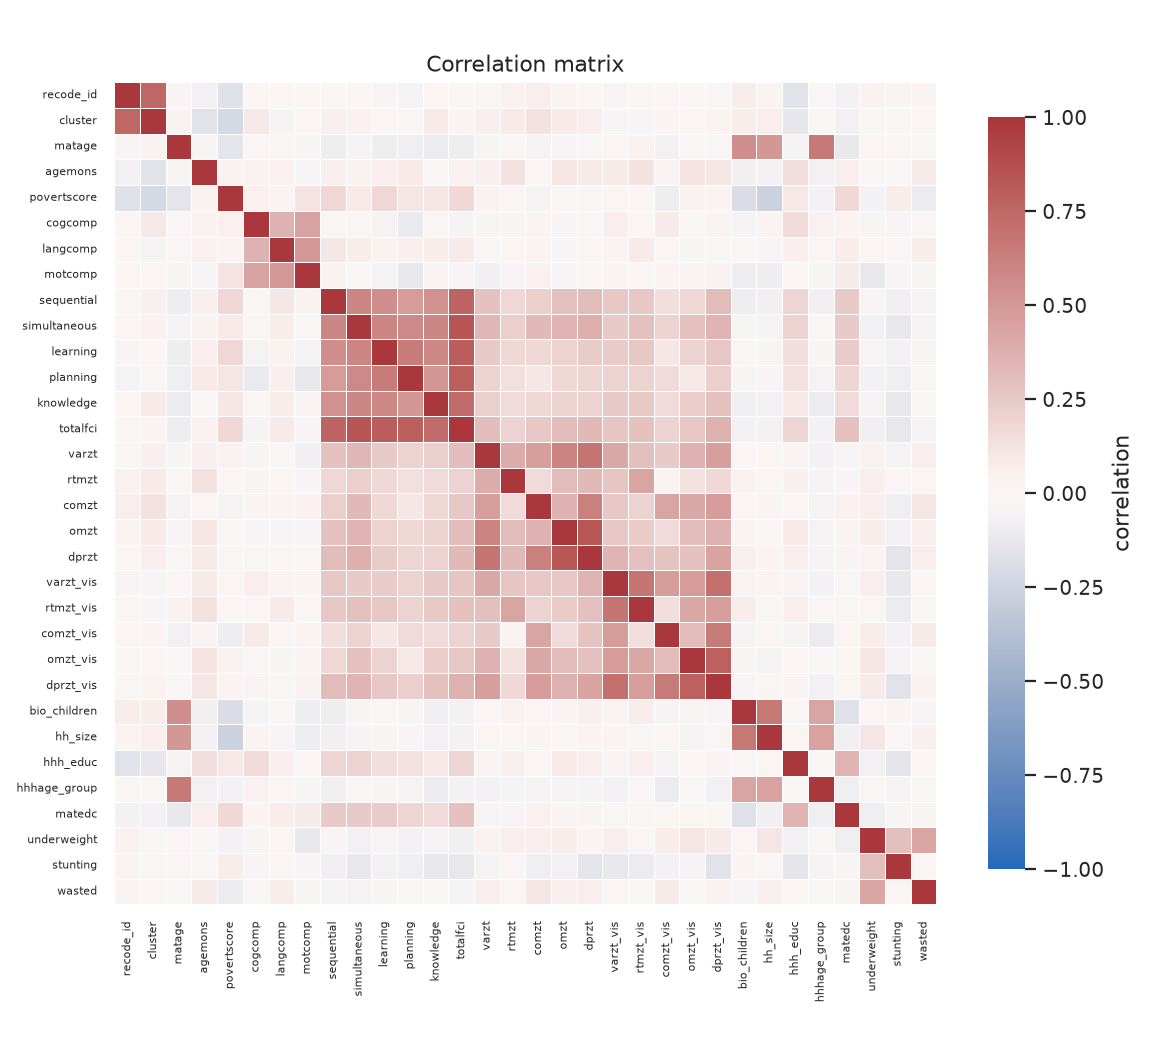

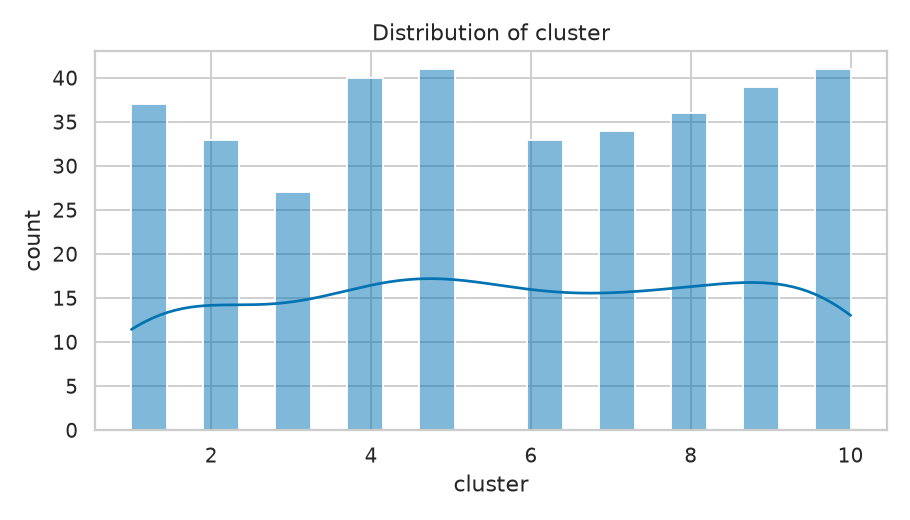

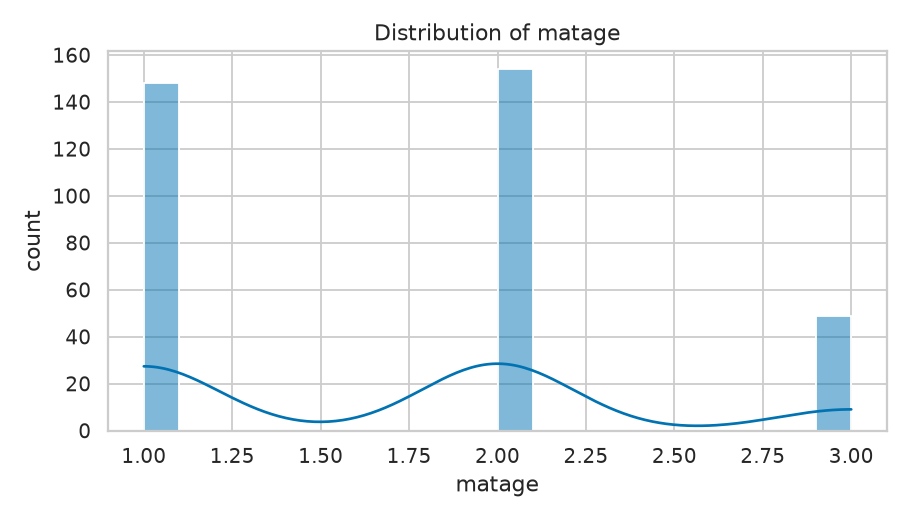

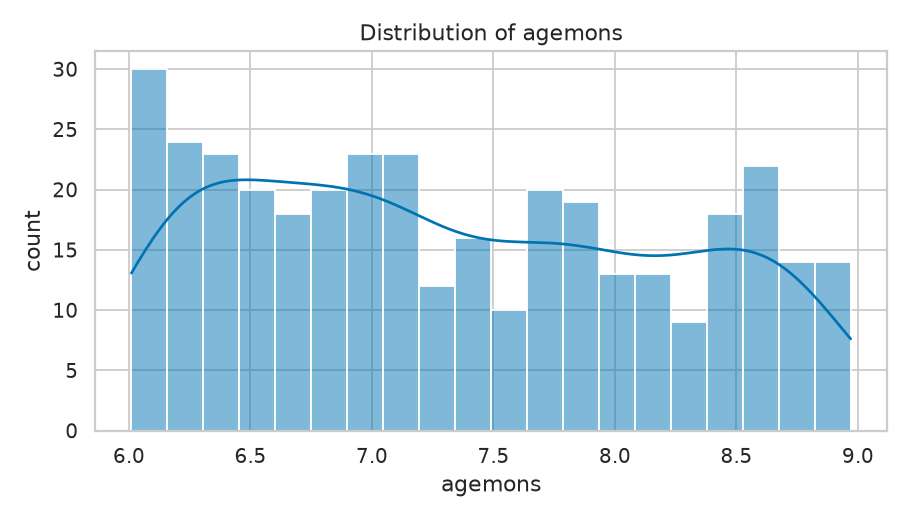

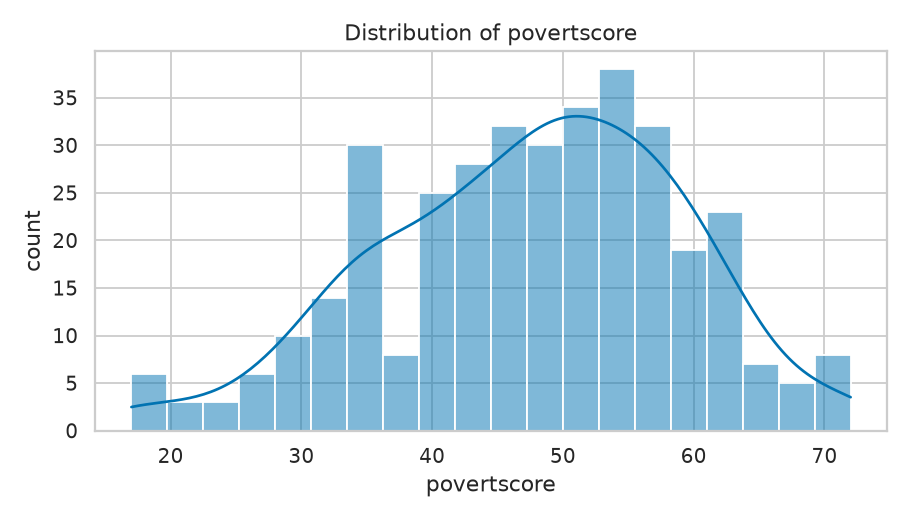

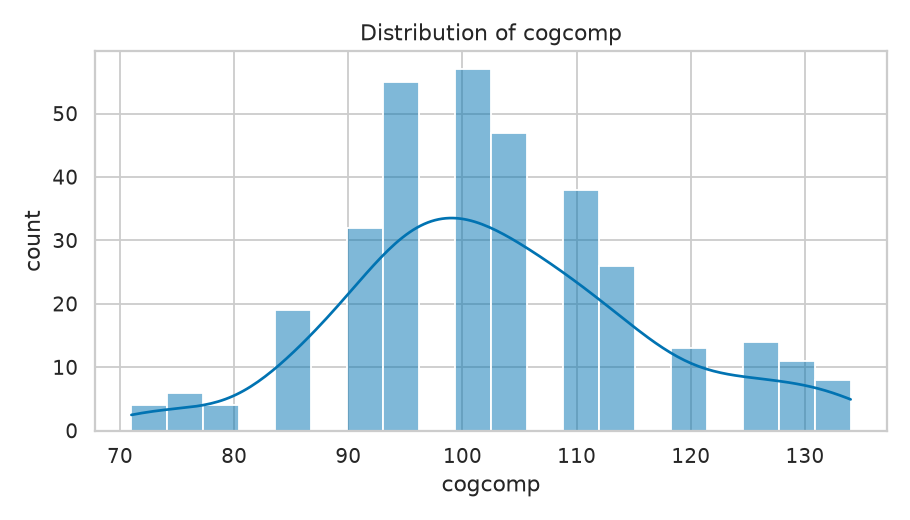

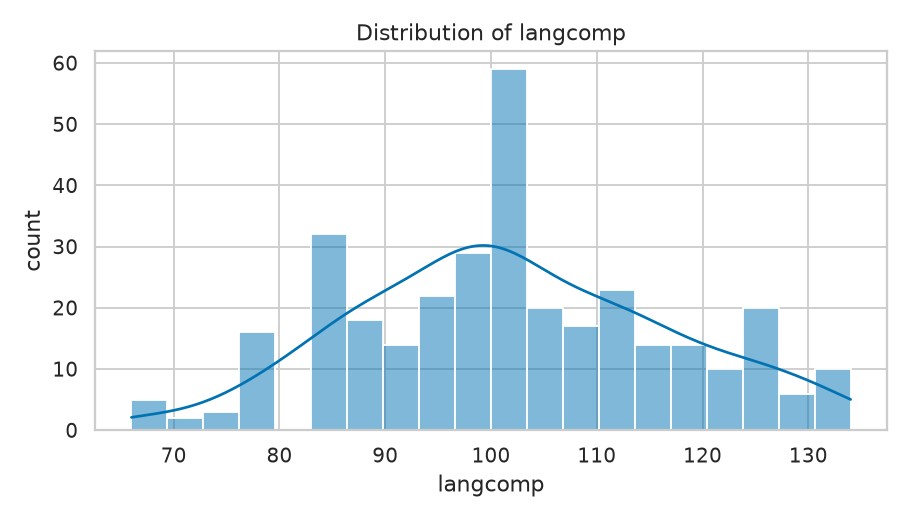

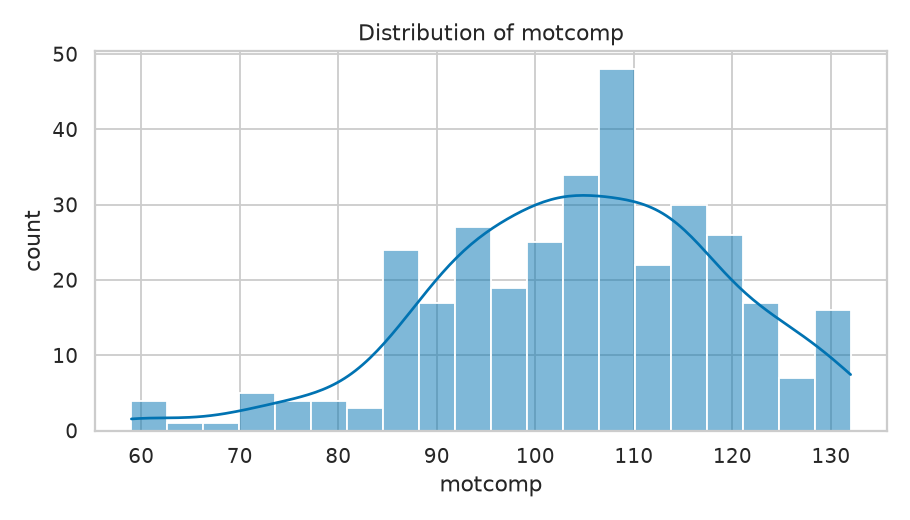

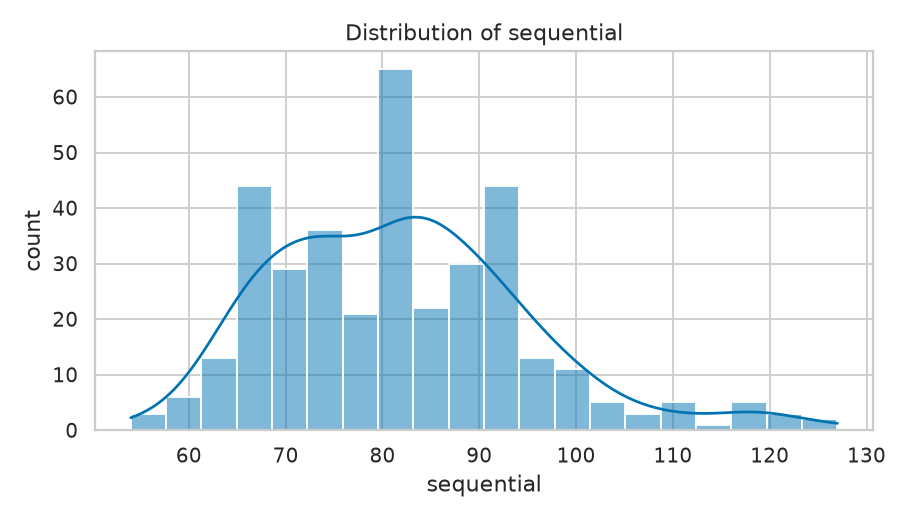

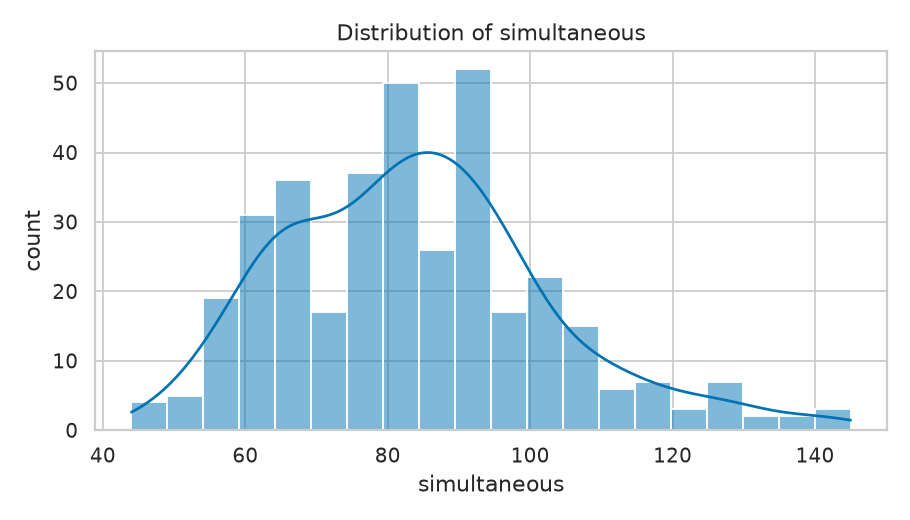

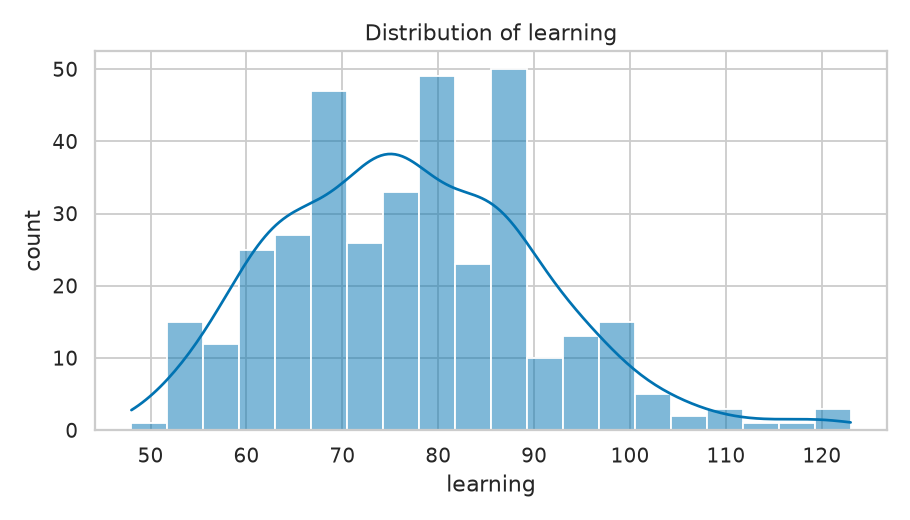

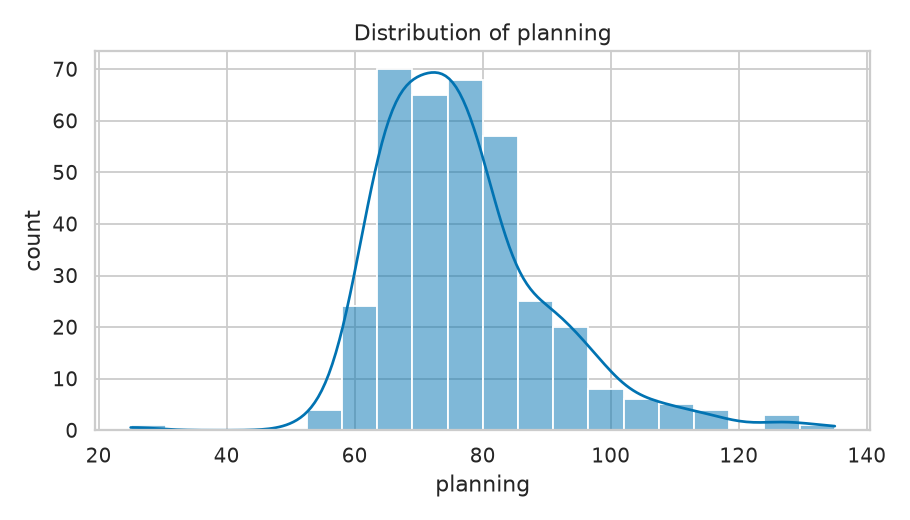

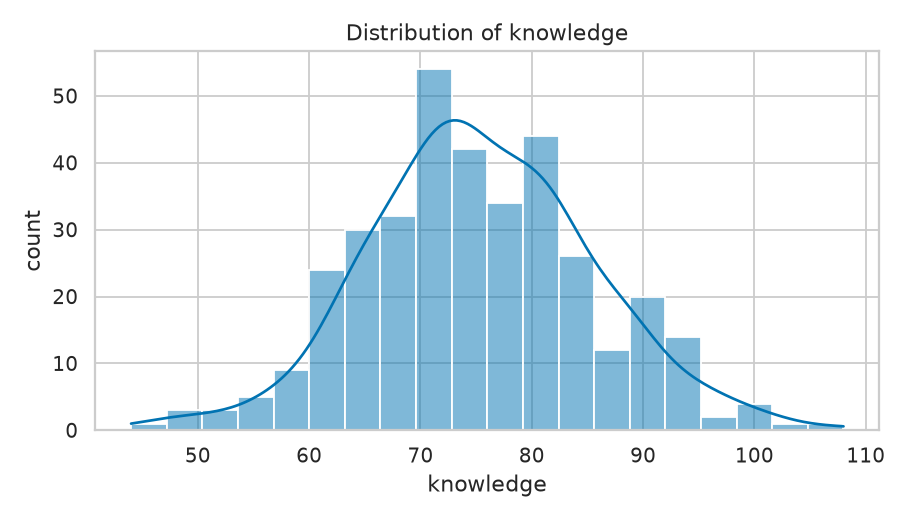

In [ ]:
print("[[step]] gen_1788249168235_0 start 2/7 ▶ Assaying: Stats Summary", flush=True)

# ── Stats Summary ──
# Appearance from this node's parameters. Set here rather than only in the
# preamble so a pipeline with two Visualize nodes can style them differently,
# which is the case when one figure is for the paper and one for a talk.
if sns is not None:
    sns.set_theme(style="whitegrid", palette="colorblind", context="notebook")
plt.rcParams["figure.figsize"] = (10.0, 6.0)
plt.rcParams["savefig.dpi"] = 130

_EDA_REQUESTED = []
_EDA_EXCLUDED = []
_eda_missing = [c for c in _EDA_REQUESTED if c not in df.columns]
_eda_kept = ([c for c in _EDA_REQUESTED if c in df.columns]
             if _EDA_REQUESTED else list(df.columns))
_eda_kept = [c for c in _eda_kept if c not in _EDA_EXCLUDED]
_eda_df = df.loc[:, _eda_kept]
if _EDA_EXCLUDED:
    print("Stats Summary: excluded from this node: "
          + ", ".join(str(c) for c in _EDA_EXCLUDED if c in df.columns), flush=True)
if _eda_missing:
    print("Stats Summary: requested columns not found: "
          + ", ".join(str(c) for c in _eda_missing), flush=True)

numeric = _eda_df.select_dtypes(include=[np.number])
if numeric.shape[1] > 0:
    desc = numeric.describe().T
else:
    # No numeric column at all: a corpus of sequences, free text, identifiers
    # or codes. describe() raises on a frame with no columns, and the run used
    # to end here on pandas' "Cannot describe a DataFrame without columns" --
    # a true sentence about the wrong subject, since the data is fine and it
    # is the summary that does not apply.
    #
    # The columns that ARE here get the summary that suits them: count,
    # distinct values, the most frequent one. Every numeric-only figure below
    # is skipped rather than attempted, and the step says which case it is in
    # so a reader is not left wondering where their histograms went.
    desc = _eda_df.describe(include="all").T if _eda_df.shape[1] > 0 else pd.DataFrame()
    print("Stats Summary: no numeric columns; summarising %d text column(s) instead "
          "(distributions and correlations need numbers)" % _eda_df.shape[1], flush=True)
desc.to_csv(ARTIFACTS / "gen_1788249168235_0__stats_summary.csv")
# Per node, not shared.
#
# Written as a bare name this was ONE value for every EDA step in the
# pipeline, and the last to run overwrote it. A Profiler sitting second
# measured twenty-one columns and displayed the zero a Visualize node wrote
# five steps later, after a reduction had emptied the frame: the panel
# reported a number the step never saw, and blamed the step for it.
METRICS["gen_1788249168235_0::numeric_columns"] = int(numeric.shape[1])
# Distributions, one per column that earns one. The cap is a ceiling on what
# is drawn, not a quota to fill: columns are considered in order and the ones
# that would repeat an earlier picture are passed over rather than counted.
_drawn = {}
_i = 0
# Stats Summary draws distributions: True
for col in (numeric.columns if True else []):
    if len(_drawn) >= 12:
        break
    _name = f"Distribution of {col}"
    if not distribution_is_worth_plotting(_name, numeric[col], _drawn):
        continue
    if not claim_plot(_name, f"distribution::{col}"):
        continue
    plt.figure(figsize=(7, 4))
    # histplot with a KDE rather than a bare histogram: two peaks separated by
    # less than a bin width look like one peak, and that is exactly the finding
    # an EDA step exists to surface.
    if sns is not None:
        sns.histplot(numeric[col].dropna(), bins=20, kde=True,
                     edgecolor=None, log_scale=False)
        if False:
            # Every observation as a tick under the axis. Worth it on a small
            # sample, where a histogram's shape is mostly the bin choice.
            sns.rugplot(numeric[col].dropna(), height=0.04, lw=0.6)
    else:
        numeric[col].hist(bins=20)
        if False:
            plt.xscale("log")
    plt.title(_name)
    plt.xlabel(str(col)); plt.ylabel("count")
    save_fig(f"gen_1788249168235_0__dist_{_i:02d}_{col}")
    _drawn[col] = numeric[col]
    _i += 1
METRICS["distributions_plotted"] = len(_drawn)
if PLOTS_SKIPPED:
    # Written out as an artifact as well as a metric: "these two columns are
    # identical" is a finding, and the report can quote it rather than leaving
    # a reader wondering why a column they expected has no plot.
    pd.DataFrame(PLOTS_SKIPPED).to_csv(ARTIFACTS / "gen_1788249168235_0__plots_skipped.csv", index=False)
if True and numeric.shape[1] >= 2:
    # on very wide data, use the highest-variance columns so the
    # heatmap stays informative and small
    corr_cols = numeric.columns
    if numeric.shape[1] > 60:
        corr_cols = numeric.var(numeric_only=True).sort_values(ascending=False).head(60).index
    sub = numeric[corr_cols]
    plt.figure(figsize=(9, 8))
    _corr = sub.corr()
    show_ticks = sub.shape[1] <= 40
    if sns is not None:
        # Annotated only where the numbers would be legible. Forty columns of
        # printed decimals is unreadable and slow to draw, and at that size the
        # colour already carries the pattern.
        sns.heatmap(_corr, cmap="vlag", vmin=-1, vmax=1, center=0,
                    square=True, linewidths=0.4 if show_ticks else 0,
                    annot=sub.shape[1] <= 12, fmt=".2f", annot_kws={"size": 7},
                    xticklabels=show_ticks, yticklabels=show_ticks,
                    cbar_kws={"label": "correlation", "shrink": 0.8})
        plt.xticks(rotation=90, fontsize=6); plt.yticks(fontsize=6)
    else:
        plt.imshow(_corr, cmap="RdBu_r", vmin=-1, vmax=1)
        plt.colorbar(label="correlation")
        if show_ticks:
            plt.xticks(range(sub.shape[1]), sub.columns, rotation=90, fontsize=6)
            plt.yticks(range(sub.shape[1]), sub.columns, fontsize=6)
        else:
            plt.xticks([]); plt.yticks([])
    title = "Correlation matrix"
    if numeric.shape[1] > 60:
        title += f" (top 60 of {numeric.shape[1]} by variance)"
    plt.title(title)
    if claim_plot("Correlation matrix", "correlation-matrix::" + ",".join(map(str, sub.columns))):
        save_fig("gen_1788249168235_0__correlation_matrix")
    else:
        plt.close()

print("[[step]] gen_1788249168235_0 done 2/7 ✓ Stats Summary", flush=True)

## Clean

In [ ]:
print("[[step]] gen_1788249168235_1 start 3/7 ▶ Transmuting: Clean", flush=True)

# ── Clean ──
before = len(df)
_cols_before = list(df.columns)
if True:
    df = df.drop_duplicates()
_after_dedupe = len(df)
# drop columns that are mostly empty
keep_cols = [c for c in df.columns if df[c].isna().mean() <= 0.6]
_dropped_cols = [c for c in _cols_before if c not in set(keep_cols)]
df = df[keep_cols]
numeric_cols = df.select_dtypes(include=[np.number]).columns
_missing_before = int(df.isna().sum().sum())
_fill_values = {}
if 'median' == "drop":
    df = df.dropna()
elif len(numeric_cols) > 0:
    fill = df[numeric_cols].median() if 'median' == "median" else df[numeric_cols].mean()
    df[numeric_cols] = df[numeric_cols].fillna(fill)
    _fill_values = {str(c): float(fill[c]) for c in numeric_cols if pd.notna(fill[c])}
_filled_cells = max(0, _missing_before - int(df.isna().sum().sum()))
# Record the cleaning so inference does the SAME thing to an incoming row.
# Dropping rows and de-duplicating are training-set decisions with no meaning
# for a single request, but the fill values are FITTED STATISTICS: a row
# arriving with a gap must be filled from the training distribution, not from
# whatever the request happens to contain. Recording the kept columns also
# lets the endpoint say which columns it stopped expecting and why.
PREP_STEPS.append({
    "kind": "clean",
    "strategy": 'median',
    "dedupe": True,
    "max_null_pct": 0.6,
    "kept_columns": [str(c) for c in df.columns],
    "fill_values": _fill_values,
})
# Per node, for the same reason: two cleaning steps shared one count.
#
# One number is not a report. Somebody opening a Clean step wants to
# know what it did TO THEIR DATA: which columns went, how many gaps
# were filled and with what rule, whether anything was duplicated. A
# panel showing "rows_removed: 0" reads as a step that did nothing,
# and is indistinguishable from one that was never asked to.
METRICS["gen_1788249168235_1::rows_removed"] = int(before - len(df))
METRICS["gen_1788249168235_1::duplicates_removed"] = int(before - _after_dedupe)
METRICS["gen_1788249168235_1::rows_before"] = int(before)
METRICS["gen_1788249168235_1::rows_after"] = int(len(df))
METRICS["gen_1788249168235_1::columns_dropped"] = len(_dropped_cols)
if _dropped_cols:
    METRICS["gen_1788249168235_1::dropped_for_emptiness"] = ", ".join(str(c) for c in _dropped_cols[:12])
METRICS["gen_1788249168235_1::missing_filled"] = int(_filled_cells)
if _fill_values:
    METRICS["gen_1788249168235_1::fill_rule"] = 'median'
if int(before - len(df)) == 0 and not _dropped_cols and int(_filled_cells) == 0:
    # The honest reading of a clean run, said plainly rather than left
    # as three zeroes for the reader to interpret.
    METRICS["gen_1788249168235_1::note"] = "nothing needed removing: no duplicates, no empty columns, no gaps"
emit_preview("gen_1788249168235_1", df)

print("[[step]] gen_1788249168235_1 done 3/7 ✓ Clean", flush=True)

## Descriptive Stats

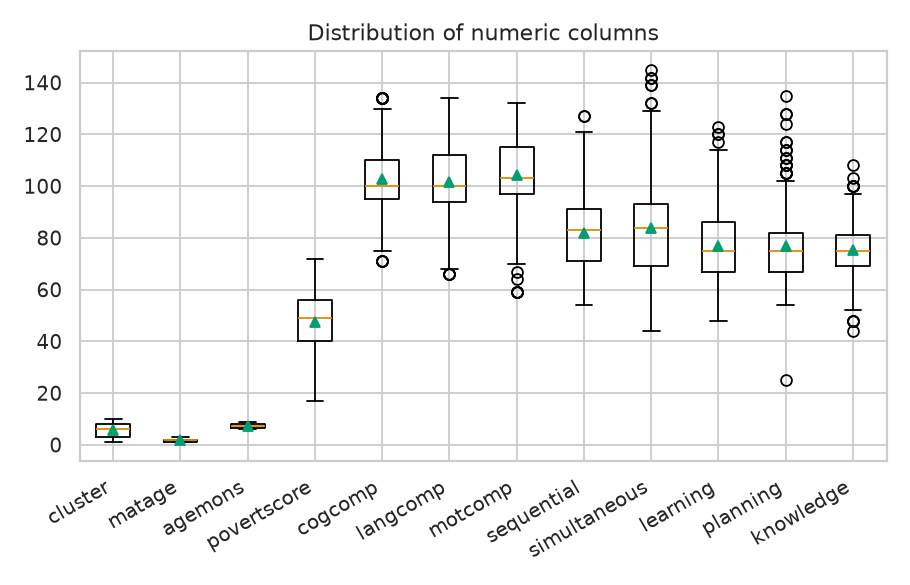

In [ ]:
print("[[step]] gen_1788249168235_2 start 4/7 ▶ Proving: Descriptive Stats", flush=True)

# ── Descriptive Stats ──
from scipy import stats as st
import json as _json

result = {}
method = 'descriptive stats'
gcol, vcol, ca, cb = '', '', '', ''
_FEAT, _SUBJ, _COND = '', '', ''
_CA, _CB = '', ''
_PTEST, _CORR = 'paired-t', 'benjamini-hochberg'
_BA_LIMITS, _BA_POINTS = 'constant', 50000
_ALPHA_CFG = 0.05
_EQ_MARGIN, _EQ_POWER = 0.02, 0.8
_PERM_STAT, _PERM_N = 'mean-absolute-difference', 1000
_CHROM, _POS = '', ''
_REG_GAP, _REG_CUT, _REG_SMOOTH = 1000, 0.01, 'none'
_CA_FACTORS, _CA_N, _CA_TEST = [], 10, 'kruskal-wallis'
_CA_CORR, _CA_MAX, _SAMP = 'bonferroni', 50000, ''
_STATS_REQUESTED, _STATS_EXCLUDED = [], ['recode_id']
_STATS_TARGET, _STATS_FEATURES = '', []

# Column choices belong to this node. Keep the incoming frame so exclusions do
# not leak into any node that runs after it.
_STATS_INPUT_DF = df
_stats_missing = [c for c in _STATS_REQUESTED if c not in df.columns]
_stats_kept = ([c for c in _STATS_REQUESTED if c in df.columns]
               if _STATS_REQUESTED else list(df.columns))
_stats_kept = [c for c in _stats_kept if c not in _STATS_EXCLUDED]
df = df.loc[:, _stats_kept]
if _STATS_EXCLUDED:
    print("Descriptive Stats: excluded from this node: "
          + ", ".join(str(c) for c in _STATS_EXCLUDED if c in _STATS_INPUT_DF.columns), flush=True)
if _stats_missing:
    print("Descriptive Stats: requested columns not found: "
          + ", ".join(str(c) for c in _stats_missing), flush=True)

def _num(col):
    return pd.to_numeric(df[col], errors="coerce").dropna()

# When the user left the columns unset, pick sensible ones from the actual
# data instead of failing: a low-cardinality categorical for grouping, numeric
# columns for values/correlations. Every auto-choice is reported back with a
# "[[param]]" line so the canvas writes it into this node's parameters.
_raw_num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]

def _looks_like_identifier(col):
    """Keep an automatic choice away from row identifiers.

    An explicitly selected identifier is still honoured. This rule applies
    only when the node has to choose for itself.
    """
    _s = df[col].dropna()
    if len(_s) <= 20 or _s.nunique() != len(_s):
        return False
    try:
        _integer = bool(pd.api.types.is_integer_dtype(_s)) or bool((_s == _s.round()).all())
    except Exception:
        _integer = False
    _name = str(col).strip().lower()
    _named = (_name in ("id", "index", "rowid", "row_id")
              or _name.endswith(("_id", "_no", "_num"))
              or any(_t in _name for _t in ("recode", "accession", "uuid", "guid")))
    return _integer and _named

_num_cols = [c for c in _raw_num_cols if not _looks_like_identifier(c)]
if not _num_cols:
    _num_cols = _raw_num_cols
_continuous_num_cols = [c for c in _num_cols if df[c].nunique(dropna=True) > 20]
_cat_cols = [c for c in df.columns
             if not pd.api.types.is_numeric_dtype(df[c]) and 2 <= df[c].nunique(dropna=True) <= 20]
_auto = {}
if any(k in method for k in ("t-test", "t test", "anova", "mann", "kruskal")):
    if not gcol or gcol not in df.columns:
        gcol = _cat_cols[0] if _cat_cols else next(
            (c for c in df.columns if df[c].nunique(dropna=True) <= 20), df.columns[0])
        _auto["group_column"] = gcol
    if not vcol or vcol not in df.columns:
        _value_pool = _continuous_num_cols or _num_cols
        vcol = next((c for c in _value_pool if c != gcol), _value_pool[0] if _value_pool else df.columns[-1])
        _auto["value_column"] = vcol
elif "correlation" in method:
    if not ca or ca not in df.columns:
        ca = _num_cols[0] if _num_cols else df.columns[0]
        _auto["column_a"] = ca
    if not cb or cb not in df.columns:
        cb = next((c for c in _num_cols if c != ca), df.columns[-1])
        _auto["column_b"] = cb
elif "chi" in method:
    _pool = _cat_cols + [c for c in _num_cols if df[c].nunique(dropna=True) <= 10]
    if not ca or ca not in df.columns:
        ca = _pool[0] if _pool else df.columns[0]
        _auto["column_a"] = ca
    if not cb or cb not in df.columns:
        cb = next((c for c in _pool if c != ca), df.columns[-1])
        _auto["column_b"] = cb
elif "normality" in method:
    if not ca or ca not in df.columns:
        _value_pool = _continuous_num_cols or _num_cols
        ca = _value_pool[0] if _value_pool else df.columns[0]
        _auto["column"] = ca
elif "ols" in method:
    if (not _STATS_TARGET or _STATS_TARGET not in df.columns) and (not vcol or vcol not in df.columns):
        vcol = _num_cols[-1] if _num_cols else df.columns[-1]
        _auto["value_column"] = vcol
for _k, _v in _auto.items():
    print("[[param]] gen_1788249168235_2 " + str(_k) + " " + str(_v), flush=True)
if _auto:
    print("Descriptive Stats: no column configured -- auto-selected "
          + ", ".join(f"{k}={v}" for k, v in _auto.items()), flush=True)

# Every test also draws ITS OWN plot(s), saved under this node's id so the
# double-click popup shows exactly this component's visual evidence.
def _p_note(p):
    return ("significant at 0.05" if p < 0.05 else "not significant at 0.05")

def _group_boxplot(title, p=None):
    data = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
    names = [str(k) for k, _ in df.groupby(gcol)]
    plt.figure(figsize=(7, 4.5))
    plt.boxplot(data[:12], showmeans=True)
    plt.xticks(range(1, min(len(names), 12) + 1), names[:12], rotation=30, ha="right")
    if p is not None:
        title += f"  (p = {p:.4g}, {_p_note(p)})"
    plt.title(title); plt.ylabel(vcol)
    save_fig("gen_1788249168235_2__group_comparison")

try:
    if "descriptive" in method:
        result = _json.loads(df.describe(include="all").to_json())
        _num_df = df.select_dtypes(include=[np.number])
        if _num_df.shape[1] > 0:
            _cols, _seen = [], {}
            for _c in _num_df.columns:
                if len(_cols) >= 12:
                    break
                if distribution_is_worth_plotting(
                        "Distribution of %s" % _c, _num_df[_c], _seen):
                    _cols.append(_c)
                    _seen[_c] = _num_df[_c]
            if _cols:
                plt.figure(figsize=(7, 4.5))
                plt.boxplot([_num_df[c].dropna().values for c in _cols], showmeans=True)
                plt.xticks(range(1, len(_cols) + 1), _cols, rotation=30, ha="right")
                plt.title("Distribution of numeric columns")
                save_fig("gen_1788249168235_2__distributions")
    elif "t-test" in method or "t test" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)][:2]
        t, p = st.ttest_ind(groups[0], groups[1], equal_var=False)
        result = {"statistic": float(t), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Welch t-test)", p)
    elif "anova" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
        f, p = st.f_oneway(*groups)
        result = {"F": float(f), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (one-way ANOVA)", p)
    elif "chi" in method:
        table = pd.crosstab(df[ca], df[cb])
        chi2, p, dof, _ = st.chi2_contingency(table)
        result = {"chi2": float(chi2), "p_value": float(p), "dof": int(dof)}
        _t = table.iloc[:15, :15]
        plt.figure(figsize=(7, 5.5))
        plt.imshow(_t.values, cmap="YlOrBr", aspect="auto")
        plt.colorbar(label="count")
        plt.xticks(range(_t.shape[1]), [str(c) for c in _t.columns], rotation=30, ha="right", fontsize=8)
        plt.yticks(range(_t.shape[0]), [str(i) for i in _t.index], fontsize=8)
        for _i in range(_t.shape[0]):
            for _j in range(_t.shape[1]):
                plt.text(_j, _i, str(_t.values[_i, _j]), ha="center", va="center", fontsize=7)
        plt.title(f"{ca} x {cb} contingency  (chi2 p = {p:.4g}, {_p_note(p)})")
        plt.xlabel(cb); plt.ylabel(ca)
        save_fig("gen_1788249168235_2__contingency")
    elif "correlation" in method:
        a, b = _num(ca), _num(cb)
        n = min(len(a), len(b)); a, b = a.iloc[:n], b.iloc[:n]
        fn = {"pearson": st.pearsonr, "spearman": st.spearmanr, "kendall": st.kendalltau}.get('pearson', st.pearsonr)
        r, p = fn(a, b)
        result = {"coefficient": float(r), "p_value": float(p)}
        plt.figure(figsize=(6.5, 5))
        _samp = min(len(a), 3000)
        plt.scatter(a.iloc[:_samp], b.iloc[:_samp], s=10, alpha=0.5)
        try:
            _k, _c = np.polyfit(a, b, 1)
            _xs = np.linspace(float(a.min()), float(a.max()), 50)
            plt.plot(_xs, _k * _xs + _c, color="crimson", linewidth=1.5)
        except Exception:
            pass
        plt.xlabel(ca); plt.ylabel(cb)
        plt.title(f"pearson r = {r:.3f}  (p = {p:.4g}, {_p_note(p)})")
        save_fig("gen_1788249168235_2__correlation_scatter")
    elif "normality" in method:
        if not _num_cols:
            raise ValueError(
                "a normality test needs a numeric column; the columns present "
                "are %s" % ", ".join(str(c) for c in df.columns[:12]))
        _col = ca if ca in df.columns else _num_cols[0]
        x = _num(_col)
        w, p = st.shapiro(x.sample(min(5000, len(x)), random_state=42))
        result = {"statistic": float(w), "p_value": float(p)}
        fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(9, 4))
        _ax1.hist(x, bins=30, edgecolor="white")
        _ax1.set_title(f"Distribution of {_col}")
        st.probplot(x, dist="norm", plot=_ax2)
        _ax2.set_title(f"Q-Q plot  (Shapiro p = {p:.4g})")
        fig.suptitle("normal" if p >= 0.05 else "deviates from normal", fontsize=10)
        save_fig("gen_1788249168235_2__normality")
    elif "mann" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)][:2]
        u, p = st.mannwhitneyu(groups[0], groups[1])
        result = {"U": float(u), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Mann-Whitney U)", p)
    elif "component association" in method:
        # DO THE MAIN DIRECTIONS OF VARIATION TRACK THE STUDY DESIGN?
        #
        # Principal components find the directions the samples actually vary
        # along. Whether those directions line up with anything in the design
        # is the question worth asking: if the largest source of variation is
        # the batch or the protocol, it is inside every result the study
        # reports.
        #
        # This is also what gives a null result its positive control. A design
        # where no component tracks the protocol but every component tracks the
        # donor has shown it can detect structure and simply did not find the
        # protocol, which is a stronger statement than "we found nothing".
        _fs = [c for c in _CA_FACTORS if c in df.columns]
        _long = _FEAT in df.columns and _SAMP in df.columns and vcol in df.columns
        if not _fs:
            step_skipped("gen_1788249168235_2", "no factor columns to test the components against")
        elif not _long and not any(pd.api.types.is_numeric_dtype(df[c]) for c in df.columns):
            step_skipped("gen_1788249168235_2", "needs either long data (feature, sample, value) or a "
                         "transposed frame with one row per sample")
        else:
            if _long:
                # Long data: pivot to samples by features first, keeping the
                # most variable, since a feature that does not vary cannot
                # separate samples.
                _v = df.groupby(_FEAT, observed=True)[vcol].var()
                _keep = _v.nlargest(min(_CA_MAX, len(_v))).index
                _sub = df[df[_FEAT].isin(_keep)]
                _M = _sub.pivot_table(index=_SAMP, columns=_FEAT, values=vcol,
                                      aggfunc="mean", observed=True)
                _facts = pd.DataFrame(
                    {c: _sub.groupby(_SAMP, observed=True)[c].first() for c in _fs}
                ).reindex(_M.index)
                if len(_v) > len(_keep):
                    print("using the %d most variable of %d features"
                          % (len(_keep), len(_v)), flush=True)
            else:
                _M = df.select_dtypes(include=[np.number]).drop(columns=_fs, errors="ignore")
                _facts = df[_fs]

            _M = _M.dropna(axis=1, how="any")
            if _M.shape[0] < 3 or _M.shape[1] < 2:
                step_skipped("gen_1788249168235_2", "only %d sample(s) and %d usable feature(s)"
                             % (_M.shape[0], _M.shape[1]))
            else:
                from sklearn.decomposition import PCA as _PCA
                _n = int(min(_CA_N, _M.shape[0] - 1, _M.shape[1]))
                _X = _M.to_numpy(dtype=float)
                _pca = _PCA(n_components=_n, svd_solver="randomized", random_state=42)
                _S = _pca.fit_transform(_X - _X.mean(axis=0))
                _ev = _pca.explained_variance_ratio_

                _rows, _pvals = [], []
                for _i in range(_n):
                    for _f in _fs:
                        _lab = _facts[_f].astype(str).to_numpy()
                        try:
                            if "spearman" in _CA_TEST:
                                _num = pd.to_numeric(_facts[_f], errors="coerce").to_numpy()
                                _ok = np.isfinite(_num)
                                _p = st.spearmanr(_S[_ok, _i], _num[_ok]).pvalue if _ok.sum() > 2 else float("nan")
                            else:
                                _g = [_S[_lab == lv, _i] for lv in pd.unique(_lab)]
                                _g = [x for x in _g if len(x) > 0]
                                _p = st.kruskal(*_g).pvalue if len(_g) > 1 else float("nan")
                        except Exception:
                            _p = float("nan")
                        _rows.append({"component": _i + 1, "factor": _f,
                                      "variance_explained": float(_ev[_i]), "p_value": _p})
                        _pvals.append(_p)

                # Corrected across EVERY component and factor tested together,
                # because that is how many questions were asked.
                _pa = np.array(_pvals, dtype=float)
                _valid = np.isfinite(_pa)
                _adj = np.full_like(_pa, np.nan)
                _m = int(_valid.sum())
                if _m:
                    if "none" in _CA_CORR:
                        _adj[_valid] = _pa[_valid]
                    elif "benjamini" in _CA_CORR:
                        _o = np.argsort(_pa[_valid])
                        _r = _pa[_valid][_o] * _m / (np.arange(_m) + 1)
                        _r = np.minimum.accumulate(_r[::-1])[::-1]
                        _out = np.empty(_m); _out[_o] = np.minimum(_r, 1.0)
                        _adj[_valid] = _out
                    else:
                        _adj[_valid] = np.minimum(_pa[_valid] * _m, 1.0)
                _res = pd.DataFrame(_rows)
                _res["p_adjusted"] = _adj
                _alpha = float(_ALPHA_CFG)
                _res["associated"] = _res["p_adjusted"] < _alpha
                _res.to_csv(ARTIFACTS / "gen_1788249168235_2__component_association.csv", index=False)

                METRICS["gen_1788249168235_2::samples"] = int(_M.shape[0])
                METRICS["gen_1788249168235_2::features_used"] = int(_M.shape[1])
                METRICS["gen_1788249168235_2::components"] = _n
                METRICS["gen_1788249168235_2::variance_pc1"] = float(_ev[0])
                for _f in _fs:
                    _sel = _res[_res["factor"] == _f]
                    METRICS["gen_1788249168235_2::associated_" + str(_f)] = int(_sel["associated"].sum())
                    METRICS["gen_1788249168235_2::smallest_p_" + str(_f)] = float(np.nanmin(_sel["p_value"]))                         if np.isfinite(_sel["p_value"]).any() else float("nan")
                result = {"samples": int(_M.shape[0]), "components": _n,
                          "factors_tested": len(_fs)}

                print("%d samples, %d features, %d components (PC1 explains %.1f%%)"
                      % (_M.shape[0], _M.shape[1], _n, _ev[0] * 100), flush=True)
                for _f in _fs:
                    _sel = _res[_res["factor"] == _f]
                    _k = int(_sel["associated"].sum())
                    print("  %s: %d of %d components associated after correction%s"
                          % (_f, _k, _n,
                             "" if _k else " (nothing in this factor tracks the variation)"),
                          flush=True)
                emit_preview("gen_1788249168235_2", _res.head(50))

                try:
                    _first = _fs[0]
                    _lab = _facts[_first].astype(str).to_numpy()
                    fig, ax = plt.subplots(figsize=(7, 5.4))
                    for lv in pd.unique(_lab):
                        _sel = _lab == lv
                        ax.scatter(_S[_sel, 0], _S[_sel, 1] if _n > 1 else np.zeros(_sel.sum()),
                                   s=48, alpha=0.85, label=str(lv), edgecolors="none")
                    ax.set_xlabel("PC1 (%.1f%%)" % (_ev[0] * 100))
                    ax.set_ylabel("PC2 (%.1f%%)" % (_ev[1] * 100) if _n > 1 else "")
                    ax.set_title("Samples in the first two components, by %s" % _first, fontsize=10)
                    ax.legend(fontsize=8, title=_first, title_fontsize=8)
                    save_fig("gen_1788249168235_2__components")
                except Exception as _e:
                    print("component figure skipped: %s" % _e, flush=True)

    elif "differential regions" in method:
        # REGIONS, NOT SITES.
        #
        # A difference too small to survive correction at any one position can
        # be real and consistent across a run of neighbouring positions. The
        # site-level test pays the multiple-testing burden once per site while
        # the evidence is spread over several, so it cannot see that. This
        # groups nearby sites, scores each run, and judges the runs against a
        # null built the way the design allows.
        _need = [c for c in (_FEAT, _CHROM, _POS, _SUBJ, _COND, vcol) if not c or c not in df.columns]
        if _need:
            step_skipped("gen_1788249168235_2", "needs a feature, chromosome, position, subject, condition and "
                         "value column; missing or not found: " + ", ".join(str(c) for c in _need if c))
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("gen_1788249168235_2", "needs two different conditions; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _sub = [c for c in _pa.columns if c in _pb.columns]
                _ft = _pa.index.intersection(_pb.index)
                if len(_sub) < 2 or len(_ft) < 2:
                    step_skipped("gen_1788249168235_2", "only %d subject(s) and %d feature(s) measured under both "
                                 "conditions" % (len(_sub), len(_ft)))
                else:
                    _D = (_pa.loc[_ft, _sub].to_numpy(dtype=float)
                          - _pb.loc[_ft, _sub].to_numpy(dtype=float))

                    # Where each feature sits. Taken once per feature, because
                    # a probe has one position however many rows mention it.
                    _coord = (_w.drop_duplicates(subset=[_FEAT])
                                .set_index(_FEAT)[[_CHROM, _POS]].reindex(_ft))
                    _chr = _coord[_CHROM].astype(str).to_numpy()
                    _bp = pd.to_numeric(_coord[_POS], errors="coerce").to_numpy()
                    _placed = np.isfinite(_bp)
                    if _placed.sum() < 2:
                        step_skipped("gen_1788249168235_2", "no usable genomic positions in %r" % _POS)
                    else:
                        _D = _D[_placed]; _chr = _chr[_placed]; _bp = _bp[_placed]
                        # Sorted along the genome, because "neighbouring" is
                        # meaningless in the order a table happens to be in.
                        _ord = np.lexsort((_bp, _chr))
                        _chr, _bp, _D = _chr[_ord], _bp[_ord], _D[_ord]
                        _feat_sorted = np.asarray(_ft, dtype=object)[_placed][_ord]

                        # Clusters: a new one begins at a new chromosome or a
                        # gap wider than the researcher allowed. Computed once,
                        # since positions do not change under permutation.
                        _new = np.ones(len(_bp), dtype=bool)
                        _new[1:] = (_chr[1:] != _chr[:-1]) | ((_bp[1:] - _bp[:-1]) > _REG_GAP)
                        _clu = np.cumsum(_new) - 1
                        _n_clusters = int(_clu[-1]) + 1

                        def _regions(_stat):
                            """Runs of consecutive sites over the cutoff, and their areas.

                            A region breaks at a cluster edge, at a change of
                            sign, or where a site falls under the cutoff: a run
                            that changes direction is two findings, not one.
                            """
                            _over = np.abs(_stat) > _REG_CUT
                            _brk = np.ones(len(_stat), dtype=bool)
                            _brk[1:] = ((_clu[1:] != _clu[:-1])
                                        | (np.sign(_stat[1:]) != np.sign(_stat[:-1]))
                                        | (~_over[1:]) | (~_over[:-1]))
                            _gid = np.cumsum(_brk) - 1
                            return _gid, _over

                        def _areas(_stat):
                            _gid, _over = _regions(_stat)
                            if not _over.any():
                                return np.zeros(1), _gid, _over
                            _ar = np.bincount(_gid[_over], weights=np.abs(_stat[_over]))
                            # bincount returns a slot for every break-group,
                            # including the runs that never cleared the cutoff.
                            # Counting those reported 118,600 "regions" where
                            # there were a few hundred: a wrong number, in the
                            # record, about the thing the step exists to count.
                            return _ar[_ar > 0], _gid, _over

                        def _per_site(_M):
                            _v = np.nanmean(_M, axis=1)
                            if "running" in _REG_SMOOTH:
                                # Three-point mean inside each cluster. Jaffe
                                # et al. use loess; this is the cheap relative
                                # and the node's help says so rather than
                                # implying the results are interchangeable.
                                _pad = _v.copy()
                                _same_l = np.zeros(len(_v), dtype=bool); _same_l[1:] = _clu[1:] == _clu[:-1]
                                _same_r = np.zeros(len(_v), dtype=bool); _same_r[:-1] = _clu[:-1] == _clu[1:]
                                _acc = _v.copy(); _cnt = np.ones(len(_v))
                                _acc[_same_l] += _v[np.roll(np.arange(len(_v)), 1)][_same_l]; _cnt[_same_l] += 1
                                _acc[_same_r] += _v[np.roll(np.arange(len(_v)), -1)][_same_r]; _cnt[_same_r] += 1
                                _pad = _acc / _cnt
                                return _pad
                            return _v

                        _stat = _per_site(_D)
                        _obs_area, _gid, _over = _areas(_stat)

                        # FAMILY-WISE ERROR, NOT PER REGION.
                        #
                        # Each permutation contributes its LARGEST region, so a
                        # region is judged against the biggest thing chance
                        # produced anywhere in the genome. That is what makes
                        # the rate family-wise rather than per-test, and it is
                        # the only correction that means anything when regions
                        # are found by searching.
                        _B = int(_PERM_N)
                        _rng = np.random.default_rng(0)
                        _null = np.empty(_B)
                        for _i in range(_B):
                            _sgn = _rng.choice([-1.0, 1.0], size=_D.shape[1])
                            _null[_i] = _areas(_per_site(_D * _sgn))[0].max()
                        _alpha = float(_ALPHA_CFG)
                        _thresh = float(np.quantile(_null, 1.0 - _alpha))
                        _pass = _obs_area > _thresh
                        _n_pass = int(_pass.sum())
                        _n_regions = int(len(_obs_area)) if _over.any() else 0

                        METRICS["gen_1788249168235_2::clusters"] = _n_clusters
                        METRICS["gen_1788249168235_2::regions_found"] = _n_regions
                        METRICS["gen_1788249168235_2::regions_significant"] = _n_pass
                        METRICS["gen_1788249168235_2::largest_region_area"] = float(_obs_area.max())
                        METRICS["gen_1788249168235_2::null_threshold"] = _thresh
                        METRICS["gen_1788249168235_2::permutations"] = _B
                        METRICS["gen_1788249168235_2::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"regions_found": _n_regions, "regions_significant": _n_pass,
                                  "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %d sites in %d clusters, %d candidate region(s), "
                              "%d significant at a family-wise error rate of %g"
                              % (_a, _b, len(_stat), _n_clusters, _n_regions, _n_pass, _alpha),
                              flush=True)
                        if not _n_pass:
                            print("no region beat the largest one chance produced: the biggest "
                                  "observed area is %.4f against a null threshold of %.4f. "
                                  "Regions of this size appear by accident in this design."
                                  % (_obs_area.max(), _thresh), flush=True)

                        # The regions themselves, so a reader can look at them
                        # whether or not any passed.
                        if _over.any():
                            _rows = []
                            _gsel = _gid[_over]
                            _order_g = np.argsort(_gsel, kind="stable")
                            _gs, _idx = np.unique(_gsel[_order_g], return_index=True)
                            _sites = np.flatnonzero(_over)[_order_g]
                            _bounds = np.append(_idx, len(_sites))
                            for _k, _g in enumerate(_gs):
                                _sl = _sites[_bounds[_k]:_bounds[_k + 1]]
                                if len(_sl) == 0:
                                    continue
                                _rows.append({
                                    "chromosome": _chr[_sl[0]],
                                    "start": float(_bp[_sl].min()),
                                    "end": float(_bp[_sl].max()),
                                    "sites": int(len(_sl)),
                                    "mean_difference": float(np.mean(_stat[_sl])),
                                    "area": float(np.sum(np.abs(_stat[_sl]))),
                                    "first_feature": str(_feat_sorted[_sl[0]]),
                                })
                            _rdf = pd.DataFrame(_rows).sort_values("area", ascending=False)
                            _rdf["passes_fwer"] = _rdf["area"] > _thresh
                            _rdf.to_csv(ARTIFACTS / "gen_1788249168235_2__regions.csv", index=False)
                            emit_preview("gen_1788249168235_2", _rdf.head(50))

                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 4.6))
                            ax.hist(_null, bins=40, color="#8899a6", edgecolor="none",
                                    label="largest region per permutation")
                            ax.axvline(_obs_area.max(), color="#C0392B", lw=1.8,
                                       label="largest observed (%.4f)" % _obs_area.max())
                            ax.axvline(_thresh, color="#C27840", lw=1.2, ls="--",
                                       label="%g threshold (%.4f)" % (_alpha, _thresh))
                            ax.set_xlabel("region area")
                            ax.set_ylabel("permutations")
                            ax.set_title("%s vs %s: %d region(s) beat chance"
                                         % (_a, _b, _n_pass), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("gen_1788249168235_2__regions")
                        except Exception as _e:
                            print("region figure skipped: %s" % _e, flush=True)

    elif "equivalence" in method or "permutation" in method:
        # Both of these need the same thing the paired test needs: one matrix
        # of differences, features by subjects, with each subject's two
        # measurements lined up against each other and nothing else.
        _ok = all(c and c in df.columns for c in (_SUBJ, _COND, vcol))
        if not _ok:
            step_skipped("gen_1788249168235_2", "needs a subject, condition and value column")
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("gen_1788249168235_2", "needs two different conditions; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _idx = _FEAT if (_FEAT and _FEAT in df.columns) else None
                if _idx is None:
                    # No feature column: one row, so the whole thing is a
                    # single measure per subject.
                    _pa = _w[_w[_COND].astype(str) == _a].groupby(_SUBJ, observed=True)[vcol].mean().to_frame().T
                    _pb = _w[_w[_COND].astype(str) == _b].groupby(_SUBJ, observed=True)[vcol].mean().to_frame().T
                else:
                    _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                        index=_idx, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                    _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                        index=_idx, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _sub = [c for c in _pa.columns if c in _pb.columns]
                _ft = _pa.index.intersection(_pb.index)
                if len(_sub) < 2 or len(_ft) == 0:
                    step_skipped("gen_1788249168235_2", "only %d subject(s) measured under both conditions"
                                 % len(_sub))
                else:
                    _D = (_pa.loc[_ft, _sub].to_numpy(dtype=float)
                          - _pb.loc[_ft, _sub].to_numpy(dtype=float))
                    _n = np.sum(~np.isnan(_D), axis=1)
                    _mean = np.nanmean(_D, axis=1)
                    _sd = np.nanstd(_D, axis=1, ddof=1)
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _se = _sd / np.sqrt(np.maximum(_n, 1))
                    _dfree = np.maximum(_n - 1, 1)
                    _alpha = float(_ALPHA_CFG)

                    if "equivalence" in method:
                        # TWO ONE-SIDED TESTS.
                        #
                        # Equivalence is not one test with the hypotheses
                        # swapped. It is two: that the difference is above
                        # -margin, and that it is below +margin. Both have to
                        # be rejected for the pair to be called equivalent, so
                        # the p-value is the LARGER of the two, which is why
                        # the procedure is conservative and why it means
                        # something.
                        _dlt = float(_EQ_MARGIN)
                        with np.errstate(invalid="ignore", divide="ignore"):
                            _p_lo = st.t.sf((_mean + _dlt) / _se, _dfree)
                            _p_hi = st.t.cdf((_mean - _dlt) / _se, _dfree)
                        _p_eq = np.maximum(_p_lo, _p_hi)
                        _eqv = _p_eq < _alpha
                        _n_eq = int(np.nansum(_eqv))
                        _tot = int(np.sum(np.isfinite(_p_eq)))

                        # WHAT THIS DESIGN COULD HAVE SEEN AT ALL.
                        #
                        # The number that makes any negative result readable.
                        # Without it, "we found no difference" and "we could
                        # not have found one" are the same sentence.
                        _tp = st.t.isf(1.0 - float(_EQ_POWER), _dfree)
                        _mdd = (st.t.isf(_alpha / 2, _dfree) + _tp) * _se
                        _mdd_gw = (st.t.isf(_alpha / max(2 * _tot, 2), _dfree) + _tp) * _se

                        METRICS["gen_1788249168235_2::features_tested"] = _tot
                        METRICS["gen_1788249168235_2::equivalent"] = _n_eq
                        METRICS["gen_1788249168235_2::equivalent_share"] = (float(_n_eq) / _tot) if _tot else float("nan")
                        METRICS["gen_1788249168235_2::margin"] = _dlt
                        METRICS["gen_1788249168235_2::median_observed_difference"] = float(np.nanmedian(np.abs(_mean)))
                        METRICS["gen_1788249168235_2::detection_limit"] = float(np.nanmedian(_mdd))
                        METRICS["gen_1788249168235_2::detection_limit_corrected"] = float(np.nanmedian(_mdd_gw))
                        METRICS["gen_1788249168235_2::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"equivalent": _n_eq, "of": _tot, "margin": _dlt,
                                  "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %d of %d equivalent within +/-%g (%.1f%%)"
                              % (_a, _b, _n_eq, _tot, _dlt,
                                 (100.0 * _n_eq / _tot) if _tot else float("nan")), flush=True)
                        print("this design could detect a difference of about %.4f per feature "
                              "(%.4f after correcting for %d tests); the median difference "
                              "observed is %.4f"
                              % (np.nanmedian(_mdd), np.nanmedian(_mdd_gw), _tot,
                                 np.nanmedian(np.abs(_mean))), flush=True)
                        if _tot and _n_eq < _tot:
                            print("the remaining %d were not SHOWN to differ either; they are "
                                  "the features this sample cannot decide" % (_tot - _n_eq),
                                  flush=True)

                        if _idx is not None:
                            pd.DataFrame({
                                "feature": np.asarray(_ft, dtype=object),
                                "mean_difference": _mean,
                                "p_equivalence": _p_eq,
                                "equivalent": _eqv,
                                "detection_limit": _mdd,
                            }).to_csv(ARTIFACTS / "gen_1788249168235_2__equivalence.csv", index=False)
                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 5))
                            _fin = np.isfinite(_mean)
                            ax.hist(_mean[_fin], bins=120, color="#8899a6", edgecolor="none")
                            ax.axvline(-_dlt, color="#C0392B", lw=1.2, ls="--",
                                       label="margin +/-%g" % _dlt)
                            ax.axvline(_dlt, color="#C0392B", lw=1.2, ls="--")
                            ax.axvline(0, color="#444", lw=0.8)
                            ax.set_xlabel("mean difference (%s minus %s)" % (_a, _b))
                            ax.set_ylabel("features")
                            ax.set_title("%d of %d equivalent within the margin"
                                         % (_n_eq, _tot), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("gen_1788249168235_2__equivalence")
                        except Exception as _e:
                            print("equivalence figure skipped: %s" % _e, flush=True)

                    else:
                        # ONE STATISTIC OVER EVERYTHING, AGAINST A NULL THE
                        # DESIGN ALLOWS.
                        #
                        # The permutation has to respect the pairing. These
                        # measurements are not independent: each subject was
                        # measured under both conditions, so the only thing
                        # free to vary under the null is WHICH of a subject's
                        # two values is called first. That is a sign flip per
                        # subject, and it is the exact test for a paired
                        # design rather than an approximation to one.
                        def _stat(_M):
                            _pf = np.nanmean(_M, axis=1)
                            if "max" in _PERM_STAT:
                                return float(np.nanmax(np.abs(_pf)))
                            if "root" in _PERM_STAT:
                                return float(np.sqrt(np.nanmean(_pf ** 2)))
                            return float(np.nanmean(np.abs(_pf)))

                        _obs = _stat(_D)
                        _B = int(_PERM_N)
                        _rng = np.random.default_rng(0)
                        _null = np.empty(_B)
                        for _i in range(_B):
                            _sgn = _rng.choice([-1.0, 1.0], size=_D.shape[1])
                            _null[_i] = _stat(_D * _sgn)
                        # +1 in both parts: the observed arrangement is itself
                        # one of the permutations, and leaving it out can
                        # report p = 0, which no permutation test can support.
                        _p = (1.0 + float(np.sum(_null >= _obs))) / (_B + 1.0)
                        _resolution = 1.0 / (_B + 1.0)

                        METRICS["gen_1788249168235_2::statistic"] = _obs
                        METRICS["gen_1788249168235_2::p_value"] = _p
                        METRICS["gen_1788249168235_2::permutations"] = _B
                        METRICS["gen_1788249168235_2::null_median"] = float(np.median(_null))
                        METRICS["gen_1788249168235_2::features"] = int(len(_ft))
                        METRICS["gen_1788249168235_2::subjects"] = int(len(_sub))
                        METRICS["gen_1788249168235_2::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"statistic": _obs, "p_value": _p,
                                  "permutations": _B, "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %s = %.6f across %d features and %d paired subjects; "
                              "p = %.4f from %d sign-flip permutations"
                              % (_a, _b, _PERM_STAT, _obs, len(_ft), len(_sub), _p, _B), flush=True)
                        if _p <= _resolution * 1.5:
                            print("that p is at the floor this many permutations can report "
                                  "(1/%d); raise the count to say anything smaller" % (_B + 1),
                                  flush=True)
                        print("a shift shared by every feature is invisible to testing them one "
                              "at a time, which is what this looks for and a per-feature test "
                              "cannot see", flush=True)
                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 4.6))
                            ax.hist(_null, bins=40, color="#8899a6", edgecolor="none",
                                    label="under the null")
                            ax.axvline(_obs, color="#C0392B", lw=1.8,
                                       label="observed (p = %.4f)" % _p)
                            ax.set_xlabel(_PERM_STAT.replace("-", " "))
                            ax.set_ylabel("permutations")
                            ax.set_title("%s vs %s, %d sign-flip permutations"
                                         % (_a, _b, _B), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("gen_1788249168235_2__permutation")
                        except Exception as _e:
                            print("permutation figure skipped: %s" % _e, flush=True)

    elif "paired feature" in method:
        # THE SAME QUESTION, ASKED OF EVERY FEATURE, PAIRED WITHIN SUBJECT.
        #
        # An epigenome-wide study asks it 440,110 times. Looping would take
        # minutes and produce the same numbers, so the pairing is done as a
        # pivot and the test as one vectorised pass: differences per feature
        # per subject, then a one-sample test of those differences against
        # zero. That is exactly what a paired t-test is.
        _need = [c for c in (_FEAT, _SUBJ, _COND, vcol) if not c or c not in df.columns]
        if _need:
            _missing = [n for n in ("feature", "subject", "condition", "value")
                        if not [_FEAT, _SUBJ, _COND, vcol][("feature","subject","condition","value").index(n)]
                        or [_FEAT, _SUBJ, _COND, vcol][("feature","subject","condition","value").index(n)] not in df.columns]
            step_skipped("gen_1788249168235_2", "needs a feature, subject, condition and value column; missing: "
                         + ", ".join(_missing))
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("gen_1788249168235_2", "needs two different conditions to compare; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                # feature x subject, one frame per condition, so subtracting
                # them pairs every measurement with its own subject's other
                # measurement and nothing else.
                _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _shared_subj = [c for c in _pa.columns if c in _pb.columns]
                _shared_feat = _pa.index.intersection(_pb.index)
                if len(_shared_subj) < 2 or len(_shared_feat) == 0:
                    step_skipped("gen_1788249168235_2",
                                 "only %d subject(s) measured under both conditions and %d shared feature(s); "
                                 "a paired test needs at least two of each"
                                 % (len(_shared_subj), len(_shared_feat)))
                else:
                    _d = (_pa.loc[_shared_feat, _shared_subj].to_numpy(dtype=float)
                          - _pb.loc[_shared_feat, _shared_subj].to_numpy(dtype=float))
                    _n_ok = np.sum(~np.isnan(_d), axis=1)
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _mean = np.nanmean(_d, axis=1)
                        _sd = np.nanstd(_d, axis=1, ddof=1)
                        _se = _sd / np.sqrt(np.maximum(_n_ok, 1))
                        _t = np.where(_se > 0, _mean / _se, np.nan)
                    _dfree = np.maximum(_n_ok - 1, 1)
                    _p = np.where(np.isnan(_t), np.nan,
                                  2 * st.t.sf(np.abs(np.nan_to_num(_t)), _dfree))
                    if "wilcoxon" in _PTEST:
                        # Signed-rank per feature. Only worth the loop when
                        # asked for, and only over features with enough pairs.
                        _p = np.full(len(_shared_feat), np.nan)
                        for _i in range(_d.shape[0]):
                            _row = _d[_i][~np.isnan(_d[_i])]
                            if len(_row) >= 6 and np.any(_row != 0):
                                try:
                                    _p[_i] = st.wilcoxon(_row).pvalue
                                except Exception:
                                    pass

                    _valid = ~np.isnan(_p)
                    _adj = np.full_like(_p, np.nan, dtype=float)
                    _pv = _p[_valid]
                    _m = len(_pv)
                    if _m:
                        if "bonferroni" in _CORR:
                            _adj[_valid] = np.minimum(_pv * _m, 1.0)
                        elif "none" in _CORR:
                            _adj[_valid] = _pv
                        else:
                            # Benjamini-Hochberg, with the monotonicity step
                            # that stops a later q falling below an earlier one.
                            _order = np.argsort(_pv)
                            _ranked = _pv[_order] * _m / (np.arange(_m) + 1)
                            _ranked = np.minimum.accumulate(_ranked[::-1])[::-1]
                            _out = np.empty(_m); _out[_order] = np.minimum(_ranked, 1.0)
                            _adj[_valid] = _out

                    _res = pd.DataFrame({
                        "feature": np.asarray(_shared_feat, dtype=object),
                        "mean_difference": _mean,
                        "t": _t,
                        "p_value": _p,
                        "p_adjusted": _adj,
                        "pairs": _n_ok,
                    }).sort_values("p_value", na_position="last")
                    _alpha = float(_ALPHA_CFG)
                    _sig = int(np.nansum(_adj < _alpha))

                    _res.to_csv(ARTIFACTS / "gen_1788249168235_2__paired_feature_test.csv", index=False)
                    METRICS["gen_1788249168235_2::features_tested"] = int(len(_shared_feat))
                    METRICS["gen_1788249168235_2::subjects_paired"] = int(len(_shared_subj))
                    METRICS["gen_1788249168235_2::significant"] = _sig
                    METRICS["gen_1788249168235_2::comparison"] = "%s vs %s" % (_a, _b)
                    METRICS["gen_1788249168235_2::smallest_p"] = float(np.nanmin(_p)) if np.any(_valid) else float("nan")
                    # WHAT A NULL RESULT HERE ACTUALLY MEANS.
                    #
                    # "No feature reached significance" is a statement about
                    # the sample size as much as about the effect, and the two
                    # read identically unless the detection limit is reported
                    # beside it. Free to compute: the spread is already here.
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _mdd80 = (st.t.isf(_alpha / max(2 * _m, 2), _dfree)
                                  + st.t.isf(0.20, _dfree)) * _se
                    METRICS["gen_1788249168235_2::detection_limit"] = float(np.nanmedian(_mdd80))
                    if not _sig and np.isfinite(np.nanmedian(_mdd80)):
                        print("nothing reached significance. at this sample size the smallest "
                              "difference this test could have found is about %.4f, against a "
                              "median observed difference of %.4f: a real effect smaller than "
                              "that would not appear here"
                              % (np.nanmedian(_mdd80), np.nanmedian(np.abs(_mean))), flush=True)
                    result = {"features_tested": int(len(_shared_feat)),
                              "subjects_paired": int(len(_shared_subj)),
                              "significant": _sig, "comparison": "%s vs %s" % (_a, _b)}

                    # A finding of NOTHING is a finding, and the sentence has
                    # to say so plainly rather than leaving an empty table to
                    # be read as a failed step.
                    print("%s vs %s: %d features tested across %d paired subjects, "
                          "%d significant at %s < %.3g%s"
                          % (_a, _b, len(_shared_feat), len(_shared_subj), _sig,
                             "adjusted p" if "none" not in _CORR else "p", _alpha,
                             "" if _sig else " -- none reached significance"), flush=True)

                    # Volcano: effect size against evidence, which is the plot
                    # that shows a null result honestly. A difference can be
                    # large and unsupported, or tiny and certain.
                    try:
                        _fin = np.isfinite(_p) & np.isfinite(_mean) & (_p > 0)
                        if _fin.sum():
                            fig, ax = plt.subplots(figsize=(7, 5))
                            ax.scatter(_mean[_fin], -np.log10(_p[_fin]), s=4, alpha=0.25,
                                       color="#8899a6", edgecolors="none")
                            _hit = _fin & (_adj < _alpha)
                            if _hit.sum():
                                ax.scatter(_mean[_hit], -np.log10(_p[_hit]), s=8, alpha=0.9,
                                           color="#C0392B", edgecolors="none",
                                           label="%d significant" % int(_hit.sum()))
                                ax.legend(loc="upper right", fontsize=8)
                            ax.axvline(0, color="#444", lw=0.8)
                            ax.set_xlabel("mean difference (%s minus %s)" % (_a, _b))
                            ax.set_ylabel("-log10 p")
                            ax.set_title("%s vs %s, paired across %d subjects"
                                         % (_a, _b, len(_shared_subj)), fontsize=10)
                            save_fig("gen_1788249168235_2__volcano")
                    except Exception as _e:
                        print("volcano plot skipped: %s" % _e, flush=True)
                    emit_preview("gen_1788249168235_2", _res.head(50))

    elif "method agreement" in method:
        # DO TWO WAYS OF MEASURING THE SAME THING AGREE.
        #
        # Correlation is the wrong tool and the usual mistake: two methods
        # with a constant offset correlate perfectly and disagree on every
        # single measurement. Bland-Altman asks the right question by plotting
        # the difference against the average.
        _need_ok = _SUBJ in df.columns and _COND in df.columns and vcol in df.columns
        if not _need_ok:
            step_skipped("gen_1788249168235_2", "needs a subject, method and value column")
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("gen_1788249168235_2", "needs two different methods to compare; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _key = [_SUBJ] + ([_FEAT] if _FEAT and _FEAT in df.columns else [])
                _p2 = _w.pivot_table(index=_key, columns=_COND, values=vcol, aggfunc="mean", observed=True)
                if _a not in _p2.columns or _b not in _p2.columns:
                    step_skipped("gen_1788249168235_2", "the two methods share no measured subject")
                else:
                    _va = _p2[_a].to_numpy(dtype=float)
                    _vb = _p2[_b].to_numpy(dtype=float)
                    _ok = np.isfinite(_va) & np.isfinite(_vb)
                    _va, _vb = _va[_ok], _vb[_ok]
                    if len(_va) < 3:
                        step_skipped("gen_1788249168235_2", "only %d paired measurement(s); too few to describe agreement"
                                     % len(_va))
                    else:
                        _avg = (_va + _vb) / 2.0
                        _dif = _va - _vb
                        _bias = float(np.mean(_dif))
                        _sd = float(np.std(_dif, ddof=1))
                        _lo, _hi = _bias - 1.96 * _sd, _bias + 1.96 * _sd

                        # Whether the constant limits are even appropriate.
                        # Bland-Altman assumes the differences are normal, and
                        # bounded measurements like a methylation beta are not.
                        _norm_p = float("nan")
                        try:
                            _samp = _dif if len(_dif) <= 5000 else np.random.default_rng(0).choice(_dif, 5000, replace=False)
                            _norm_p = float(st.shapiro(_samp).pvalue)
                        except Exception:
                            pass

                        _band = None
                        if "proportional" in _BA_LIMITS:
                            # A spread that changes with the measurement:
                            # sigma(x) = exp(a + b(x - c)^2), fitted by least
                            # squares on the log absolute difference. Bounded
                            # values disagree least at the extremes and most in
                            # the middle, and constant limits describe neither.
                            try:
                                _c = float(np.mean(_avg))
                                _X = np.column_stack([np.ones_like(_avg), (_avg - _c) ** 2])
                                _y = np.log(np.abs(_dif) + 1e-9)
                                _coef, *_ = np.linalg.lstsq(_X, _y, rcond=None)
                                _grid = np.linspace(np.min(_avg), np.max(_avg), 200)
                                _sig = np.exp(_coef[0] + _coef[1] * (_grid - _c) ** 2)
                                # exp of a log-|difference| fit estimates the
                                # mean absolute difference, and the 1.96-sigma
                                # band wants a standard deviation.
                                _band = (_grid, 1.96 * _sig * np.sqrt(np.pi / 2))
                                METRICS["gen_1788249168235_2::limits_shape_a"] = float(_coef[0])
                                METRICS["gen_1788249168235_2::limits_shape_b"] = float(_coef[1])
                            except Exception as _e:
                                print("proportional limits could not be fitted (%s); "
                                      "constant limits are shown" % _e, flush=True)

                        METRICS["gen_1788249168235_2::bias"] = _bias
                        METRICS["gen_1788249168235_2::limit_lower"] = float(_lo)
                        METRICS["gen_1788249168235_2::limit_upper"] = float(_hi)
                        METRICS["gen_1788249168235_2::pairs"] = int(len(_va))
                        METRICS["gen_1788249168235_2::comparison"] = "%s vs %s" % (_a, _b)
                        if np.isfinite(_norm_p):
                            # NAME THE HYPOTHESIS, NOT JUST THE NUMBER.
                            #
                            # This was called "differences_normal_p", and a
                            # report writer reading the evidence took it for a
                            # p-value ON the differences between methods and
                            # wrote that the methods differ significantly. The
                            # opposite of the finding, from a correct number.
                            #
                            # A bare p-value cannot be read without knowing
                            # what was tested, so the step says so itself
                            # rather than leaving the name to be guessed at.
                            METRICS["gen_1788249168235_2::normality_shapiro_p"] = _norm_p
                            METRICS["gen_1788249168235_2::normality_shapiro_tests"] = (
                                "normality of the paired differences, NOT a "
                                "difference between the two methods. A small "
                                "p means the differences are not normally "
                                "distributed, so constant limits of agreement "
                                "would misdescribe the spread and "
                                "proportional limits are used instead.")
                        result = {"bias": _bias, "limits_of_agreement": [float(_lo), float(_hi)],
                                  "pairs": int(len(_va)), "comparison": "%s vs %s" % (_a, _b)}
                        print("%s vs %s: bias %.5f, 95%% of differences between %.5f and %.5f, "
                              "over %d paired measurements%s"
                              % (_a, _b, _bias, _lo, _hi, len(_va),
                                 "" if not np.isfinite(_norm_p) or _norm_p >= 0.05
                                 else " (the differences are not normally distributed, "
                                      "so constant limits understate the spread at some levels)"),
                              flush=True)
                        try:
                            _n_plot = min(int(_BA_POINTS), len(_avg))
                            _sel = (np.arange(len(_avg)) if _n_plot >= len(_avg)
                                    else np.random.default_rng(0).choice(len(_avg), _n_plot, replace=False))
                            fig, ax = plt.subplots(figsize=(7.5, 5))
                            ax.scatter(_avg[_sel], _dif[_sel], s=3, alpha=0.15,
                                       color="#8899a6", edgecolors="none")
                            ax.axhline(_bias, color="#C27840", lw=1.4, label="bias %.4f" % _bias)
                            if _band is not None:
                                ax.plot(_band[0], _bias + _band[1], color="#C0392B", lw=1.2,
                                        label="proportional limits")
                                ax.plot(_band[0], _bias - _band[1], color="#C0392B", lw=1.2)
                            else:
                                ax.axhline(_hi, color="#C0392B", lw=1.1, ls="--",
                                           label="95%% limits (%.4f, %.4f)" % (_lo, _hi))
                                ax.axhline(_lo, color="#C0392B", lw=1.1, ls="--")
                            ax.set_xlabel("mean of %s and %s" % (_a, _b))
                            ax.set_ylabel("%s minus %s" % (_a, _b))
                            ax.set_title("Agreement between %s and %s (%d pairs%s)"
                                         % (_a, _b, len(_va),
                                            ", %d shown" % _n_plot if _n_plot < len(_va) else ""),
                                         fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("gen_1788249168235_2__bland_altman")
                        except Exception as _e:
                            print("agreement plot skipped: %s" % _e, flush=True)

    elif "kruskal" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
        h, p = st.kruskal(*groups)
        result = {"H": float(h), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Kruskal-Wallis)", p)
    elif "ols" in method:
        from sklearn.linear_model import LinearRegression
        tgt = _STATS_TARGET if _STATS_TARGET in df.columns else (
            vcol if vcol in df.columns else df.columns[-1])
        _feature_cols = [c for c in _STATS_FEATURES
                         if c in df.columns and c != tgt]
        Xr = (df[_feature_cols] if _feature_cols
              else df.select_dtypes(include=[np.number]).drop(columns=[tgt], errors="ignore"))
        Xr = Xr.fillna(0)
        yr = pd.to_numeric(df[tgt], errors="coerce").fillna(0)
        if Xr.shape[1] == 0:
            # Named here rather than left to sklearn, which answers "at least
            # one array or dtype is required" from inside its input check and
            # says nothing about which column it wanted.
            raise ValueError(
                "a regression needs at least one numeric predictor besides the "
                "response %r; the columns present are %s. Add an Encode step "
                "before this one, or use a table that holds the measurements."
                % (tgt, ", ".join(str(c) for c in df.columns[:12])))
        lr = LinearRegression().fit(Xr, yr)
        result = {"r_squared": float(lr.score(Xr, yr)), "n_features": int(Xr.shape[1])}
        _pred = lr.predict(Xr)
        fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(9, 4))
        _ax1.scatter(yr[:3000], _pred[:3000], s=10, alpha=0.5)
        _lim = [float(min(yr.min(), _pred.min())), float(max(yr.max(), _pred.max()))]
        _ax1.plot(_lim, _lim, color="crimson", linewidth=1)
        _ax1.set_xlabel(f"actual {tgt}"); _ax1.set_ylabel("predicted")
        _ax1.set_title(f"OLS fit  (R2 = {result['r_squared']:.3f})")
        _res = yr - _pred
        _ax2.hist(_res, bins=30, edgecolor="white")
        _ax2.set_title("Residuals"); _ax2.set_xlabel("actual - predicted")
        save_fig("gen_1788249168235_2__ols_fit")
    else:
        result = {"note": "unrecognized test"}
    if "p_value" in result:
        result["significant_at_0.05"] = bool(result["p_value"] < 0.05)
except Exception as _e:
    result = {"error": str(_e)}

for k, v in result.items():
    if isinstance(v, (int, float, bool)):
        METRICS[f"{method}::{k}"] = v          # legacy run-level key
        METRICS["gen_1788249168235_2::" + str(k)] = v            # per-node: two same-type tests stay separate
with open(ARTIFACTS / "gen_1788249168235_2__test_result.json", "w") as _f:
    _json.dump(result, _f, indent=2, default=str)
# a tidy per-node report table alongside the raw JSON
_rep_rows = [{"item": str(k), "value": v} for k, v in result.items()
             if not isinstance(v, dict)]
if _rep_rows:
    _rep = pd.DataFrame(_rep_rows)
    _rep.insert(0, "test", 'Descriptive Stats')
    _rep.to_csv(ARTIFACTS / "gen_1788249168235_2__test_report.csv", index=False)
# concise line for the terminal (the full result is saved as an artifact)
_summary = {k: v for k, v in result.items() if isinstance(v, (int, float, bool))}
print(f"    Descriptive Stats:", _summary if _summary else "computed (saved to results)", flush=True)
# Restore the exact input frame for the next node. Column exclusions are a
# view of this analysis, not a hidden Drop Columns transform.
df = _STATS_INPUT_DF

print("[[step]] gen_1788249168235_2 done 4/7 ✓ Descriptive Stats", flush=True)

## t-Test

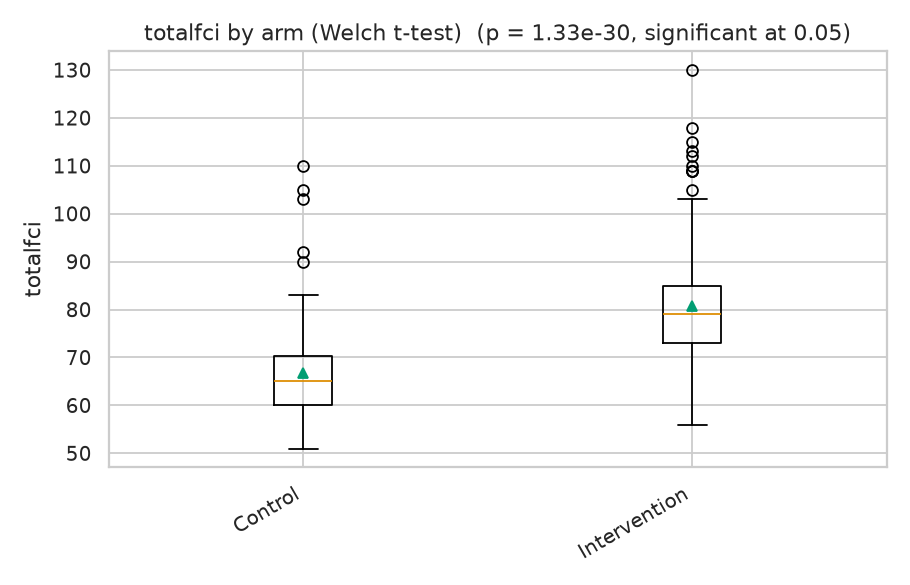

In [ ]:
print("[[step]] gen_1788249168235_3 start 5/7 ▶ Proving: t-Test", flush=True)

# ── t-Test ──
from scipy import stats as st
import json as _json

result = {}
method = 't-test'
gcol, vcol, ca, cb = 'arm', 'totalfci', '', ''
_FEAT, _SUBJ, _COND = '', '', ''
_CA, _CB = '', ''
_PTEST, _CORR = 'paired-t', 'benjamini-hochberg'
_BA_LIMITS, _BA_POINTS = 'constant', 50000
_ALPHA_CFG = 0.05
_EQ_MARGIN, _EQ_POWER = 0.02, 0.8
_PERM_STAT, _PERM_N = 'mean-absolute-difference', 1000
_CHROM, _POS = '', ''
_REG_GAP, _REG_CUT, _REG_SMOOTH = 1000, 0.01, 'none'
_CA_FACTORS, _CA_N, _CA_TEST = [], 10, 'kruskal-wallis'
_CA_CORR, _CA_MAX, _SAMP = 'bonferroni', 50000, ''
_STATS_REQUESTED, _STATS_EXCLUDED = [], []
_STATS_TARGET, _STATS_FEATURES = '', []

# Column choices belong to this node. Keep the incoming frame so exclusions do
# not leak into any node that runs after it.
_STATS_INPUT_DF = df
_stats_missing = [c for c in _STATS_REQUESTED if c not in df.columns]
_stats_kept = ([c for c in _STATS_REQUESTED if c in df.columns]
               if _STATS_REQUESTED else list(df.columns))
_stats_kept = [c for c in _stats_kept if c not in _STATS_EXCLUDED]
df = df.loc[:, _stats_kept]
if _STATS_EXCLUDED:
    print("t-Test: excluded from this node: "
          + ", ".join(str(c) for c in _STATS_EXCLUDED if c in _STATS_INPUT_DF.columns), flush=True)
if _stats_missing:
    print("t-Test: requested columns not found: "
          + ", ".join(str(c) for c in _stats_missing), flush=True)

def _num(col):
    return pd.to_numeric(df[col], errors="coerce").dropna()

# When the user left the columns unset, pick sensible ones from the actual
# data instead of failing: a low-cardinality categorical for grouping, numeric
# columns for values/correlations. Every auto-choice is reported back with a
# "[[param]]" line so the canvas writes it into this node's parameters.
_raw_num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]

def _looks_like_identifier(col):
    """Keep an automatic choice away from row identifiers.

    An explicitly selected identifier is still honoured. This rule applies
    only when the node has to choose for itself.
    """
    _s = df[col].dropna()
    if len(_s) <= 20 or _s.nunique() != len(_s):
        return False
    try:
        _integer = bool(pd.api.types.is_integer_dtype(_s)) or bool((_s == _s.round()).all())
    except Exception:
        _integer = False
    _name = str(col).strip().lower()
    _named = (_name in ("id", "index", "rowid", "row_id")
              or _name.endswith(("_id", "_no", "_num"))
              or any(_t in _name for _t in ("recode", "accession", "uuid", "guid")))
    return _integer and _named

_num_cols = [c for c in _raw_num_cols if not _looks_like_identifier(c)]
if not _num_cols:
    _num_cols = _raw_num_cols
_continuous_num_cols = [c for c in _num_cols if df[c].nunique(dropna=True) > 20]
_cat_cols = [c for c in df.columns
             if not pd.api.types.is_numeric_dtype(df[c]) and 2 <= df[c].nunique(dropna=True) <= 20]
_auto = {}
if any(k in method for k in ("t-test", "t test", "anova", "mann", "kruskal")):
    if not gcol or gcol not in df.columns:
        gcol = _cat_cols[0] if _cat_cols else next(
            (c for c in df.columns if df[c].nunique(dropna=True) <= 20), df.columns[0])
        _auto["group_column"] = gcol
    if not vcol or vcol not in df.columns:
        _value_pool = _continuous_num_cols or _num_cols
        vcol = next((c for c in _value_pool if c != gcol), _value_pool[0] if _value_pool else df.columns[-1])
        _auto["value_column"] = vcol
elif "correlation" in method:
    if not ca or ca not in df.columns:
        ca = _num_cols[0] if _num_cols else df.columns[0]
        _auto["column_a"] = ca
    if not cb or cb not in df.columns:
        cb = next((c for c in _num_cols if c != ca), df.columns[-1])
        _auto["column_b"] = cb
elif "chi" in method:
    _pool = _cat_cols + [c for c in _num_cols if df[c].nunique(dropna=True) <= 10]
    if not ca or ca not in df.columns:
        ca = _pool[0] if _pool else df.columns[0]
        _auto["column_a"] = ca
    if not cb or cb not in df.columns:
        cb = next((c for c in _pool if c != ca), df.columns[-1])
        _auto["column_b"] = cb
elif "normality" in method:
    if not ca or ca not in df.columns:
        _value_pool = _continuous_num_cols or _num_cols
        ca = _value_pool[0] if _value_pool else df.columns[0]
        _auto["column"] = ca
elif "ols" in method:
    if (not _STATS_TARGET or _STATS_TARGET not in df.columns) and (not vcol or vcol not in df.columns):
        vcol = _num_cols[-1] if _num_cols else df.columns[-1]
        _auto["value_column"] = vcol
for _k, _v in _auto.items():
    print("[[param]] gen_1788249168235_3 " + str(_k) + " " + str(_v), flush=True)
if _auto:
    print("t-Test: no column configured -- auto-selected "
          + ", ".join(f"{k}={v}" for k, v in _auto.items()), flush=True)

# Every test also draws ITS OWN plot(s), saved under this node's id so the
# double-click popup shows exactly this component's visual evidence.
def _p_note(p):
    return ("significant at 0.05" if p < 0.05 else "not significant at 0.05")

def _group_boxplot(title, p=None):
    data = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
    names = [str(k) for k, _ in df.groupby(gcol)]
    plt.figure(figsize=(7, 4.5))
    plt.boxplot(data[:12], showmeans=True)
    plt.xticks(range(1, min(len(names), 12) + 1), names[:12], rotation=30, ha="right")
    if p is not None:
        title += f"  (p = {p:.4g}, {_p_note(p)})"
    plt.title(title); plt.ylabel(vcol)
    save_fig("gen_1788249168235_3__group_comparison")

try:
    if "descriptive" in method:
        result = _json.loads(df.describe(include="all").to_json())
        _num_df = df.select_dtypes(include=[np.number])
        if _num_df.shape[1] > 0:
            _cols, _seen = [], {}
            for _c in _num_df.columns:
                if len(_cols) >= 12:
                    break
                if distribution_is_worth_plotting(
                        "Distribution of %s" % _c, _num_df[_c], _seen):
                    _cols.append(_c)
                    _seen[_c] = _num_df[_c]
            if _cols:
                plt.figure(figsize=(7, 4.5))
                plt.boxplot([_num_df[c].dropna().values for c in _cols], showmeans=True)
                plt.xticks(range(1, len(_cols) + 1), _cols, rotation=30, ha="right")
                plt.title("Distribution of numeric columns")
                save_fig("gen_1788249168235_3__distributions")
    elif "t-test" in method or "t test" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)][:2]
        t, p = st.ttest_ind(groups[0], groups[1], equal_var=False)
        result = {"statistic": float(t), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Welch t-test)", p)
    elif "anova" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
        f, p = st.f_oneway(*groups)
        result = {"F": float(f), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (one-way ANOVA)", p)
    elif "chi" in method:
        table = pd.crosstab(df[ca], df[cb])
        chi2, p, dof, _ = st.chi2_contingency(table)
        result = {"chi2": float(chi2), "p_value": float(p), "dof": int(dof)}
        _t = table.iloc[:15, :15]
        plt.figure(figsize=(7, 5.5))
        plt.imshow(_t.values, cmap="YlOrBr", aspect="auto")
        plt.colorbar(label="count")
        plt.xticks(range(_t.shape[1]), [str(c) for c in _t.columns], rotation=30, ha="right", fontsize=8)
        plt.yticks(range(_t.shape[0]), [str(i) for i in _t.index], fontsize=8)
        for _i in range(_t.shape[0]):
            for _j in range(_t.shape[1]):
                plt.text(_j, _i, str(_t.values[_i, _j]), ha="center", va="center", fontsize=7)
        plt.title(f"{ca} x {cb} contingency  (chi2 p = {p:.4g}, {_p_note(p)})")
        plt.xlabel(cb); plt.ylabel(ca)
        save_fig("gen_1788249168235_3__contingency")
    elif "correlation" in method:
        a, b = _num(ca), _num(cb)
        n = min(len(a), len(b)); a, b = a.iloc[:n], b.iloc[:n]
        fn = {"pearson": st.pearsonr, "spearman": st.spearmanr, "kendall": st.kendalltau}.get('pearson', st.pearsonr)
        r, p = fn(a, b)
        result = {"coefficient": float(r), "p_value": float(p)}
        plt.figure(figsize=(6.5, 5))
        _samp = min(len(a), 3000)
        plt.scatter(a.iloc[:_samp], b.iloc[:_samp], s=10, alpha=0.5)
        try:
            _k, _c = np.polyfit(a, b, 1)
            _xs = np.linspace(float(a.min()), float(a.max()), 50)
            plt.plot(_xs, _k * _xs + _c, color="crimson", linewidth=1.5)
        except Exception:
            pass
        plt.xlabel(ca); plt.ylabel(cb)
        plt.title(f"pearson r = {r:.3f}  (p = {p:.4g}, {_p_note(p)})")
        save_fig("gen_1788249168235_3__correlation_scatter")
    elif "normality" in method:
        if not _num_cols:
            raise ValueError(
                "a normality test needs a numeric column; the columns present "
                "are %s" % ", ".join(str(c) for c in df.columns[:12]))
        _col = ca if ca in df.columns else _num_cols[0]
        x = _num(_col)
        w, p = st.shapiro(x.sample(min(5000, len(x)), random_state=42))
        result = {"statistic": float(w), "p_value": float(p)}
        fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(9, 4))
        _ax1.hist(x, bins=30, edgecolor="white")
        _ax1.set_title(f"Distribution of {_col}")
        st.probplot(x, dist="norm", plot=_ax2)
        _ax2.set_title(f"Q-Q plot  (Shapiro p = {p:.4g})")
        fig.suptitle("normal" if p >= 0.05 else "deviates from normal", fontsize=10)
        save_fig("gen_1788249168235_3__normality")
    elif "mann" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)][:2]
        u, p = st.mannwhitneyu(groups[0], groups[1])
        result = {"U": float(u), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Mann-Whitney U)", p)
    elif "component association" in method:
        # DO THE MAIN DIRECTIONS OF VARIATION TRACK THE STUDY DESIGN?
        #
        # Principal components find the directions the samples actually vary
        # along. Whether those directions line up with anything in the design
        # is the question worth asking: if the largest source of variation is
        # the batch or the protocol, it is inside every result the study
        # reports.
        #
        # This is also what gives a null result its positive control. A design
        # where no component tracks the protocol but every component tracks the
        # donor has shown it can detect structure and simply did not find the
        # protocol, which is a stronger statement than "we found nothing".
        _fs = [c for c in _CA_FACTORS if c in df.columns]
        _long = _FEAT in df.columns and _SAMP in df.columns and vcol in df.columns
        if not _fs:
            step_skipped("gen_1788249168235_3", "no factor columns to test the components against")
        elif not _long and not any(pd.api.types.is_numeric_dtype(df[c]) for c in df.columns):
            step_skipped("gen_1788249168235_3", "needs either long data (feature, sample, value) or a "
                         "transposed frame with one row per sample")
        else:
            if _long:
                # Long data: pivot to samples by features first, keeping the
                # most variable, since a feature that does not vary cannot
                # separate samples.
                _v = df.groupby(_FEAT, observed=True)[vcol].var()
                _keep = _v.nlargest(min(_CA_MAX, len(_v))).index
                _sub = df[df[_FEAT].isin(_keep)]
                _M = _sub.pivot_table(index=_SAMP, columns=_FEAT, values=vcol,
                                      aggfunc="mean", observed=True)
                _facts = pd.DataFrame(
                    {c: _sub.groupby(_SAMP, observed=True)[c].first() for c in _fs}
                ).reindex(_M.index)
                if len(_v) > len(_keep):
                    print("using the %d most variable of %d features"
                          % (len(_keep), len(_v)), flush=True)
            else:
                _M = df.select_dtypes(include=[np.number]).drop(columns=_fs, errors="ignore")
                _facts = df[_fs]

            _M = _M.dropna(axis=1, how="any")
            if _M.shape[0] < 3 or _M.shape[1] < 2:
                step_skipped("gen_1788249168235_3", "only %d sample(s) and %d usable feature(s)"
                             % (_M.shape[0], _M.shape[1]))
            else:
                from sklearn.decomposition import PCA as _PCA
                _n = int(min(_CA_N, _M.shape[0] - 1, _M.shape[1]))
                _X = _M.to_numpy(dtype=float)
                _pca = _PCA(n_components=_n, svd_solver="randomized", random_state=42)
                _S = _pca.fit_transform(_X - _X.mean(axis=0))
                _ev = _pca.explained_variance_ratio_

                _rows, _pvals = [], []
                for _i in range(_n):
                    for _f in _fs:
                        _lab = _facts[_f].astype(str).to_numpy()
                        try:
                            if "spearman" in _CA_TEST:
                                _num = pd.to_numeric(_facts[_f], errors="coerce").to_numpy()
                                _ok = np.isfinite(_num)
                                _p = st.spearmanr(_S[_ok, _i], _num[_ok]).pvalue if _ok.sum() > 2 else float("nan")
                            else:
                                _g = [_S[_lab == lv, _i] for lv in pd.unique(_lab)]
                                _g = [x for x in _g if len(x) > 0]
                                _p = st.kruskal(*_g).pvalue if len(_g) > 1 else float("nan")
                        except Exception:
                            _p = float("nan")
                        _rows.append({"component": _i + 1, "factor": _f,
                                      "variance_explained": float(_ev[_i]), "p_value": _p})
                        _pvals.append(_p)

                # Corrected across EVERY component and factor tested together,
                # because that is how many questions were asked.
                _pa = np.array(_pvals, dtype=float)
                _valid = np.isfinite(_pa)
                _adj = np.full_like(_pa, np.nan)
                _m = int(_valid.sum())
                if _m:
                    if "none" in _CA_CORR:
                        _adj[_valid] = _pa[_valid]
                    elif "benjamini" in _CA_CORR:
                        _o = np.argsort(_pa[_valid])
                        _r = _pa[_valid][_o] * _m / (np.arange(_m) + 1)
                        _r = np.minimum.accumulate(_r[::-1])[::-1]
                        _out = np.empty(_m); _out[_o] = np.minimum(_r, 1.0)
                        _adj[_valid] = _out
                    else:
                        _adj[_valid] = np.minimum(_pa[_valid] * _m, 1.0)
                _res = pd.DataFrame(_rows)
                _res["p_adjusted"] = _adj
                _alpha = float(_ALPHA_CFG)
                _res["associated"] = _res["p_adjusted"] < _alpha
                _res.to_csv(ARTIFACTS / "gen_1788249168235_3__component_association.csv", index=False)

                METRICS["gen_1788249168235_3::samples"] = int(_M.shape[0])
                METRICS["gen_1788249168235_3::features_used"] = int(_M.shape[1])
                METRICS["gen_1788249168235_3::components"] = _n
                METRICS["gen_1788249168235_3::variance_pc1"] = float(_ev[0])
                for _f in _fs:
                    _sel = _res[_res["factor"] == _f]
                    METRICS["gen_1788249168235_3::associated_" + str(_f)] = int(_sel["associated"].sum())
                    METRICS["gen_1788249168235_3::smallest_p_" + str(_f)] = float(np.nanmin(_sel["p_value"]))                         if np.isfinite(_sel["p_value"]).any() else float("nan")
                result = {"samples": int(_M.shape[0]), "components": _n,
                          "factors_tested": len(_fs)}

                print("%d samples, %d features, %d components (PC1 explains %.1f%%)"
                      % (_M.shape[0], _M.shape[1], _n, _ev[0] * 100), flush=True)
                for _f in _fs:
                    _sel = _res[_res["factor"] == _f]
                    _k = int(_sel["associated"].sum())
                    print("  %s: %d of %d components associated after correction%s"
                          % (_f, _k, _n,
                             "" if _k else " (nothing in this factor tracks the variation)"),
                          flush=True)
                emit_preview("gen_1788249168235_3", _res.head(50))

                try:
                    _first = _fs[0]
                    _lab = _facts[_first].astype(str).to_numpy()
                    fig, ax = plt.subplots(figsize=(7, 5.4))
                    for lv in pd.unique(_lab):
                        _sel = _lab == lv
                        ax.scatter(_S[_sel, 0], _S[_sel, 1] if _n > 1 else np.zeros(_sel.sum()),
                                   s=48, alpha=0.85, label=str(lv), edgecolors="none")
                    ax.set_xlabel("PC1 (%.1f%%)" % (_ev[0] * 100))
                    ax.set_ylabel("PC2 (%.1f%%)" % (_ev[1] * 100) if _n > 1 else "")
                    ax.set_title("Samples in the first two components, by %s" % _first, fontsize=10)
                    ax.legend(fontsize=8, title=_first, title_fontsize=8)
                    save_fig("gen_1788249168235_3__components")
                except Exception as _e:
                    print("component figure skipped: %s" % _e, flush=True)

    elif "differential regions" in method:
        # REGIONS, NOT SITES.
        #
        # A difference too small to survive correction at any one position can
        # be real and consistent across a run of neighbouring positions. The
        # site-level test pays the multiple-testing burden once per site while
        # the evidence is spread over several, so it cannot see that. This
        # groups nearby sites, scores each run, and judges the runs against a
        # null built the way the design allows.
        _need = [c for c in (_FEAT, _CHROM, _POS, _SUBJ, _COND, vcol) if not c or c not in df.columns]
        if _need:
            step_skipped("gen_1788249168235_3", "needs a feature, chromosome, position, subject, condition and "
                         "value column; missing or not found: " + ", ".join(str(c) for c in _need if c))
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("gen_1788249168235_3", "needs two different conditions; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _sub = [c for c in _pa.columns if c in _pb.columns]
                _ft = _pa.index.intersection(_pb.index)
                if len(_sub) < 2 or len(_ft) < 2:
                    step_skipped("gen_1788249168235_3", "only %d subject(s) and %d feature(s) measured under both "
                                 "conditions" % (len(_sub), len(_ft)))
                else:
                    _D = (_pa.loc[_ft, _sub].to_numpy(dtype=float)
                          - _pb.loc[_ft, _sub].to_numpy(dtype=float))

                    # Where each feature sits. Taken once per feature, because
                    # a probe has one position however many rows mention it.
                    _coord = (_w.drop_duplicates(subset=[_FEAT])
                                .set_index(_FEAT)[[_CHROM, _POS]].reindex(_ft))
                    _chr = _coord[_CHROM].astype(str).to_numpy()
                    _bp = pd.to_numeric(_coord[_POS], errors="coerce").to_numpy()
                    _placed = np.isfinite(_bp)
                    if _placed.sum() < 2:
                        step_skipped("gen_1788249168235_3", "no usable genomic positions in %r" % _POS)
                    else:
                        _D = _D[_placed]; _chr = _chr[_placed]; _bp = _bp[_placed]
                        # Sorted along the genome, because "neighbouring" is
                        # meaningless in the order a table happens to be in.
                        _ord = np.lexsort((_bp, _chr))
                        _chr, _bp, _D = _chr[_ord], _bp[_ord], _D[_ord]
                        _feat_sorted = np.asarray(_ft, dtype=object)[_placed][_ord]

                        # Clusters: a new one begins at a new chromosome or a
                        # gap wider than the researcher allowed. Computed once,
                        # since positions do not change under permutation.
                        _new = np.ones(len(_bp), dtype=bool)
                        _new[1:] = (_chr[1:] != _chr[:-1]) | ((_bp[1:] - _bp[:-1]) > _REG_GAP)
                        _clu = np.cumsum(_new) - 1
                        _n_clusters = int(_clu[-1]) + 1

                        def _regions(_stat):
                            """Runs of consecutive sites over the cutoff, and their areas.

                            A region breaks at a cluster edge, at a change of
                            sign, or where a site falls under the cutoff: a run
                            that changes direction is two findings, not one.
                            """
                            _over = np.abs(_stat) > _REG_CUT
                            _brk = np.ones(len(_stat), dtype=bool)
                            _brk[1:] = ((_clu[1:] != _clu[:-1])
                                        | (np.sign(_stat[1:]) != np.sign(_stat[:-1]))
                                        | (~_over[1:]) | (~_over[:-1]))
                            _gid = np.cumsum(_brk) - 1
                            return _gid, _over

                        def _areas(_stat):
                            _gid, _over = _regions(_stat)
                            if not _over.any():
                                return np.zeros(1), _gid, _over
                            _ar = np.bincount(_gid[_over], weights=np.abs(_stat[_over]))
                            # bincount returns a slot for every break-group,
                            # including the runs that never cleared the cutoff.
                            # Counting those reported 118,600 "regions" where
                            # there were a few hundred: a wrong number, in the
                            # record, about the thing the step exists to count.
                            return _ar[_ar > 0], _gid, _over

                        def _per_site(_M):
                            _v = np.nanmean(_M, axis=1)
                            if "running" in _REG_SMOOTH:
                                # Three-point mean inside each cluster. Jaffe
                                # et al. use loess; this is the cheap relative
                                # and the node's help says so rather than
                                # implying the results are interchangeable.
                                _pad = _v.copy()
                                _same_l = np.zeros(len(_v), dtype=bool); _same_l[1:] = _clu[1:] == _clu[:-1]
                                _same_r = np.zeros(len(_v), dtype=bool); _same_r[:-1] = _clu[:-1] == _clu[1:]
                                _acc = _v.copy(); _cnt = np.ones(len(_v))
                                _acc[_same_l] += _v[np.roll(np.arange(len(_v)), 1)][_same_l]; _cnt[_same_l] += 1
                                _acc[_same_r] += _v[np.roll(np.arange(len(_v)), -1)][_same_r]; _cnt[_same_r] += 1
                                _pad = _acc / _cnt
                                return _pad
                            return _v

                        _stat = _per_site(_D)
                        _obs_area, _gid, _over = _areas(_stat)

                        # FAMILY-WISE ERROR, NOT PER REGION.
                        #
                        # Each permutation contributes its LARGEST region, so a
                        # region is judged against the biggest thing chance
                        # produced anywhere in the genome. That is what makes
                        # the rate family-wise rather than per-test, and it is
                        # the only correction that means anything when regions
                        # are found by searching.
                        _B = int(_PERM_N)
                        _rng = np.random.default_rng(0)
                        _null = np.empty(_B)
                        for _i in range(_B):
                            _sgn = _rng.choice([-1.0, 1.0], size=_D.shape[1])
                            _null[_i] = _areas(_per_site(_D * _sgn))[0].max()
                        _alpha = float(_ALPHA_CFG)
                        _thresh = float(np.quantile(_null, 1.0 - _alpha))
                        _pass = _obs_area > _thresh
                        _n_pass = int(_pass.sum())
                        _n_regions = int(len(_obs_area)) if _over.any() else 0

                        METRICS["gen_1788249168235_3::clusters"] = _n_clusters
                        METRICS["gen_1788249168235_3::regions_found"] = _n_regions
                        METRICS["gen_1788249168235_3::regions_significant"] = _n_pass
                        METRICS["gen_1788249168235_3::largest_region_area"] = float(_obs_area.max())
                        METRICS["gen_1788249168235_3::null_threshold"] = _thresh
                        METRICS["gen_1788249168235_3::permutations"] = _B
                        METRICS["gen_1788249168235_3::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"regions_found": _n_regions, "regions_significant": _n_pass,
                                  "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %d sites in %d clusters, %d candidate region(s), "
                              "%d significant at a family-wise error rate of %g"
                              % (_a, _b, len(_stat), _n_clusters, _n_regions, _n_pass, _alpha),
                              flush=True)
                        if not _n_pass:
                            print("no region beat the largest one chance produced: the biggest "
                                  "observed area is %.4f against a null threshold of %.4f. "
                                  "Regions of this size appear by accident in this design."
                                  % (_obs_area.max(), _thresh), flush=True)

                        # The regions themselves, so a reader can look at them
                        # whether or not any passed.
                        if _over.any():
                            _rows = []
                            _gsel = _gid[_over]
                            _order_g = np.argsort(_gsel, kind="stable")
                            _gs, _idx = np.unique(_gsel[_order_g], return_index=True)
                            _sites = np.flatnonzero(_over)[_order_g]
                            _bounds = np.append(_idx, len(_sites))
                            for _k, _g in enumerate(_gs):
                                _sl = _sites[_bounds[_k]:_bounds[_k + 1]]
                                if len(_sl) == 0:
                                    continue
                                _rows.append({
                                    "chromosome": _chr[_sl[0]],
                                    "start": float(_bp[_sl].min()),
                                    "end": float(_bp[_sl].max()),
                                    "sites": int(len(_sl)),
                                    "mean_difference": float(np.mean(_stat[_sl])),
                                    "area": float(np.sum(np.abs(_stat[_sl]))),
                                    "first_feature": str(_feat_sorted[_sl[0]]),
                                })
                            _rdf = pd.DataFrame(_rows).sort_values("area", ascending=False)
                            _rdf["passes_fwer"] = _rdf["area"] > _thresh
                            _rdf.to_csv(ARTIFACTS / "gen_1788249168235_3__regions.csv", index=False)
                            emit_preview("gen_1788249168235_3", _rdf.head(50))

                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 4.6))
                            ax.hist(_null, bins=40, color="#8899a6", edgecolor="none",
                                    label="largest region per permutation")
                            ax.axvline(_obs_area.max(), color="#C0392B", lw=1.8,
                                       label="largest observed (%.4f)" % _obs_area.max())
                            ax.axvline(_thresh, color="#C27840", lw=1.2, ls="--",
                                       label="%g threshold (%.4f)" % (_alpha, _thresh))
                            ax.set_xlabel("region area")
                            ax.set_ylabel("permutations")
                            ax.set_title("%s vs %s: %d region(s) beat chance"
                                         % (_a, _b, _n_pass), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("gen_1788249168235_3__regions")
                        except Exception as _e:
                            print("region figure skipped: %s" % _e, flush=True)

    elif "equivalence" in method or "permutation" in method:
        # Both of these need the same thing the paired test needs: one matrix
        # of differences, features by subjects, with each subject's two
        # measurements lined up against each other and nothing else.
        _ok = all(c and c in df.columns for c in (_SUBJ, _COND, vcol))
        if not _ok:
            step_skipped("gen_1788249168235_3", "needs a subject, condition and value column")
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("gen_1788249168235_3", "needs two different conditions; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _idx = _FEAT if (_FEAT and _FEAT in df.columns) else None
                if _idx is None:
                    # No feature column: one row, so the whole thing is a
                    # single measure per subject.
                    _pa = _w[_w[_COND].astype(str) == _a].groupby(_SUBJ, observed=True)[vcol].mean().to_frame().T
                    _pb = _w[_w[_COND].astype(str) == _b].groupby(_SUBJ, observed=True)[vcol].mean().to_frame().T
                else:
                    _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                        index=_idx, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                    _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                        index=_idx, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _sub = [c for c in _pa.columns if c in _pb.columns]
                _ft = _pa.index.intersection(_pb.index)
                if len(_sub) < 2 or len(_ft) == 0:
                    step_skipped("gen_1788249168235_3", "only %d subject(s) measured under both conditions"
                                 % len(_sub))
                else:
                    _D = (_pa.loc[_ft, _sub].to_numpy(dtype=float)
                          - _pb.loc[_ft, _sub].to_numpy(dtype=float))
                    _n = np.sum(~np.isnan(_D), axis=1)
                    _mean = np.nanmean(_D, axis=1)
                    _sd = np.nanstd(_D, axis=1, ddof=1)
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _se = _sd / np.sqrt(np.maximum(_n, 1))
                    _dfree = np.maximum(_n - 1, 1)
                    _alpha = float(_ALPHA_CFG)

                    if "equivalence" in method:
                        # TWO ONE-SIDED TESTS.
                        #
                        # Equivalence is not one test with the hypotheses
                        # swapped. It is two: that the difference is above
                        # -margin, and that it is below +margin. Both have to
                        # be rejected for the pair to be called equivalent, so
                        # the p-value is the LARGER of the two, which is why
                        # the procedure is conservative and why it means
                        # something.
                        _dlt = float(_EQ_MARGIN)
                        with np.errstate(invalid="ignore", divide="ignore"):
                            _p_lo = st.t.sf((_mean + _dlt) / _se, _dfree)
                            _p_hi = st.t.cdf((_mean - _dlt) / _se, _dfree)
                        _p_eq = np.maximum(_p_lo, _p_hi)
                        _eqv = _p_eq < _alpha
                        _n_eq = int(np.nansum(_eqv))
                        _tot = int(np.sum(np.isfinite(_p_eq)))

                        # WHAT THIS DESIGN COULD HAVE SEEN AT ALL.
                        #
                        # The number that makes any negative result readable.
                        # Without it, "we found no difference" and "we could
                        # not have found one" are the same sentence.
                        _tp = st.t.isf(1.0 - float(_EQ_POWER), _dfree)
                        _mdd = (st.t.isf(_alpha / 2, _dfree) + _tp) * _se
                        _mdd_gw = (st.t.isf(_alpha / max(2 * _tot, 2), _dfree) + _tp) * _se

                        METRICS["gen_1788249168235_3::features_tested"] = _tot
                        METRICS["gen_1788249168235_3::equivalent"] = _n_eq
                        METRICS["gen_1788249168235_3::equivalent_share"] = (float(_n_eq) / _tot) if _tot else float("nan")
                        METRICS["gen_1788249168235_3::margin"] = _dlt
                        METRICS["gen_1788249168235_3::median_observed_difference"] = float(np.nanmedian(np.abs(_mean)))
                        METRICS["gen_1788249168235_3::detection_limit"] = float(np.nanmedian(_mdd))
                        METRICS["gen_1788249168235_3::detection_limit_corrected"] = float(np.nanmedian(_mdd_gw))
                        METRICS["gen_1788249168235_3::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"equivalent": _n_eq, "of": _tot, "margin": _dlt,
                                  "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %d of %d equivalent within +/-%g (%.1f%%)"
                              % (_a, _b, _n_eq, _tot, _dlt,
                                 (100.0 * _n_eq / _tot) if _tot else float("nan")), flush=True)
                        print("this design could detect a difference of about %.4f per feature "
                              "(%.4f after correcting for %d tests); the median difference "
                              "observed is %.4f"
                              % (np.nanmedian(_mdd), np.nanmedian(_mdd_gw), _tot,
                                 np.nanmedian(np.abs(_mean))), flush=True)
                        if _tot and _n_eq < _tot:
                            print("the remaining %d were not SHOWN to differ either; they are "
                                  "the features this sample cannot decide" % (_tot - _n_eq),
                                  flush=True)

                        if _idx is not None:
                            pd.DataFrame({
                                "feature": np.asarray(_ft, dtype=object),
                                "mean_difference": _mean,
                                "p_equivalence": _p_eq,
                                "equivalent": _eqv,
                                "detection_limit": _mdd,
                            }).to_csv(ARTIFACTS / "gen_1788249168235_3__equivalence.csv", index=False)
                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 5))
                            _fin = np.isfinite(_mean)
                            ax.hist(_mean[_fin], bins=120, color="#8899a6", edgecolor="none")
                            ax.axvline(-_dlt, color="#C0392B", lw=1.2, ls="--",
                                       label="margin +/-%g" % _dlt)
                            ax.axvline(_dlt, color="#C0392B", lw=1.2, ls="--")
                            ax.axvline(0, color="#444", lw=0.8)
                            ax.set_xlabel("mean difference (%s minus %s)" % (_a, _b))
                            ax.set_ylabel("features")
                            ax.set_title("%d of %d equivalent within the margin"
                                         % (_n_eq, _tot), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("gen_1788249168235_3__equivalence")
                        except Exception as _e:
                            print("equivalence figure skipped: %s" % _e, flush=True)

                    else:
                        # ONE STATISTIC OVER EVERYTHING, AGAINST A NULL THE
                        # DESIGN ALLOWS.
                        #
                        # The permutation has to respect the pairing. These
                        # measurements are not independent: each subject was
                        # measured under both conditions, so the only thing
                        # free to vary under the null is WHICH of a subject's
                        # two values is called first. That is a sign flip per
                        # subject, and it is the exact test for a paired
                        # design rather than an approximation to one.
                        def _stat(_M):
                            _pf = np.nanmean(_M, axis=1)
                            if "max" in _PERM_STAT:
                                return float(np.nanmax(np.abs(_pf)))
                            if "root" in _PERM_STAT:
                                return float(np.sqrt(np.nanmean(_pf ** 2)))
                            return float(np.nanmean(np.abs(_pf)))

                        _obs = _stat(_D)
                        _B = int(_PERM_N)
                        _rng = np.random.default_rng(0)
                        _null = np.empty(_B)
                        for _i in range(_B):
                            _sgn = _rng.choice([-1.0, 1.0], size=_D.shape[1])
                            _null[_i] = _stat(_D * _sgn)
                        # +1 in both parts: the observed arrangement is itself
                        # one of the permutations, and leaving it out can
                        # report p = 0, which no permutation test can support.
                        _p = (1.0 + float(np.sum(_null >= _obs))) / (_B + 1.0)
                        _resolution = 1.0 / (_B + 1.0)

                        METRICS["gen_1788249168235_3::statistic"] = _obs
                        METRICS["gen_1788249168235_3::p_value"] = _p
                        METRICS["gen_1788249168235_3::permutations"] = _B
                        METRICS["gen_1788249168235_3::null_median"] = float(np.median(_null))
                        METRICS["gen_1788249168235_3::features"] = int(len(_ft))
                        METRICS["gen_1788249168235_3::subjects"] = int(len(_sub))
                        METRICS["gen_1788249168235_3::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"statistic": _obs, "p_value": _p,
                                  "permutations": _B, "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %s = %.6f across %d features and %d paired subjects; "
                              "p = %.4f from %d sign-flip permutations"
                              % (_a, _b, _PERM_STAT, _obs, len(_ft), len(_sub), _p, _B), flush=True)
                        if _p <= _resolution * 1.5:
                            print("that p is at the floor this many permutations can report "
                                  "(1/%d); raise the count to say anything smaller" % (_B + 1),
                                  flush=True)
                        print("a shift shared by every feature is invisible to testing them one "
                              "at a time, which is what this looks for and a per-feature test "
                              "cannot see", flush=True)
                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 4.6))
                            ax.hist(_null, bins=40, color="#8899a6", edgecolor="none",
                                    label="under the null")
                            ax.axvline(_obs, color="#C0392B", lw=1.8,
                                       label="observed (p = %.4f)" % _p)
                            ax.set_xlabel(_PERM_STAT.replace("-", " "))
                            ax.set_ylabel("permutations")
                            ax.set_title("%s vs %s, %d sign-flip permutations"
                                         % (_a, _b, _B), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("gen_1788249168235_3__permutation")
                        except Exception as _e:
                            print("permutation figure skipped: %s" % _e, flush=True)

    elif "paired feature" in method:
        # THE SAME QUESTION, ASKED OF EVERY FEATURE, PAIRED WITHIN SUBJECT.
        #
        # An epigenome-wide study asks it 440,110 times. Looping would take
        # minutes and produce the same numbers, so the pairing is done as a
        # pivot and the test as one vectorised pass: differences per feature
        # per subject, then a one-sample test of those differences against
        # zero. That is exactly what a paired t-test is.
        _need = [c for c in (_FEAT, _SUBJ, _COND, vcol) if not c or c not in df.columns]
        if _need:
            _missing = [n for n in ("feature", "subject", "condition", "value")
                        if not [_FEAT, _SUBJ, _COND, vcol][("feature","subject","condition","value").index(n)]
                        or [_FEAT, _SUBJ, _COND, vcol][("feature","subject","condition","value").index(n)] not in df.columns]
            step_skipped("gen_1788249168235_3", "needs a feature, subject, condition and value column; missing: "
                         + ", ".join(_missing))
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("gen_1788249168235_3", "needs two different conditions to compare; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                # feature x subject, one frame per condition, so subtracting
                # them pairs every measurement with its own subject's other
                # measurement and nothing else.
                _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _shared_subj = [c for c in _pa.columns if c in _pb.columns]
                _shared_feat = _pa.index.intersection(_pb.index)
                if len(_shared_subj) < 2 or len(_shared_feat) == 0:
                    step_skipped("gen_1788249168235_3",
                                 "only %d subject(s) measured under both conditions and %d shared feature(s); "
                                 "a paired test needs at least two of each"
                                 % (len(_shared_subj), len(_shared_feat)))
                else:
                    _d = (_pa.loc[_shared_feat, _shared_subj].to_numpy(dtype=float)
                          - _pb.loc[_shared_feat, _shared_subj].to_numpy(dtype=float))
                    _n_ok = np.sum(~np.isnan(_d), axis=1)
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _mean = np.nanmean(_d, axis=1)
                        _sd = np.nanstd(_d, axis=1, ddof=1)
                        _se = _sd / np.sqrt(np.maximum(_n_ok, 1))
                        _t = np.where(_se > 0, _mean / _se, np.nan)
                    _dfree = np.maximum(_n_ok - 1, 1)
                    _p = np.where(np.isnan(_t), np.nan,
                                  2 * st.t.sf(np.abs(np.nan_to_num(_t)), _dfree))
                    if "wilcoxon" in _PTEST:
                        # Signed-rank per feature. Only worth the loop when
                        # asked for, and only over features with enough pairs.
                        _p = np.full(len(_shared_feat), np.nan)
                        for _i in range(_d.shape[0]):
                            _row = _d[_i][~np.isnan(_d[_i])]
                            if len(_row) >= 6 and np.any(_row != 0):
                                try:
                                    _p[_i] = st.wilcoxon(_row).pvalue
                                except Exception:
                                    pass

                    _valid = ~np.isnan(_p)
                    _adj = np.full_like(_p, np.nan, dtype=float)
                    _pv = _p[_valid]
                    _m = len(_pv)
                    if _m:
                        if "bonferroni" in _CORR:
                            _adj[_valid] = np.minimum(_pv * _m, 1.0)
                        elif "none" in _CORR:
                            _adj[_valid] = _pv
                        else:
                            # Benjamini-Hochberg, with the monotonicity step
                            # that stops a later q falling below an earlier one.
                            _order = np.argsort(_pv)
                            _ranked = _pv[_order] * _m / (np.arange(_m) + 1)
                            _ranked = np.minimum.accumulate(_ranked[::-1])[::-1]
                            _out = np.empty(_m); _out[_order] = np.minimum(_ranked, 1.0)
                            _adj[_valid] = _out

                    _res = pd.DataFrame({
                        "feature": np.asarray(_shared_feat, dtype=object),
                        "mean_difference": _mean,
                        "t": _t,
                        "p_value": _p,
                        "p_adjusted": _adj,
                        "pairs": _n_ok,
                    }).sort_values("p_value", na_position="last")
                    _alpha = float(_ALPHA_CFG)
                    _sig = int(np.nansum(_adj < _alpha))

                    _res.to_csv(ARTIFACTS / "gen_1788249168235_3__paired_feature_test.csv", index=False)
                    METRICS["gen_1788249168235_3::features_tested"] = int(len(_shared_feat))
                    METRICS["gen_1788249168235_3::subjects_paired"] = int(len(_shared_subj))
                    METRICS["gen_1788249168235_3::significant"] = _sig
                    METRICS["gen_1788249168235_3::comparison"] = "%s vs %s" % (_a, _b)
                    METRICS["gen_1788249168235_3::smallest_p"] = float(np.nanmin(_p)) if np.any(_valid) else float("nan")
                    # WHAT A NULL RESULT HERE ACTUALLY MEANS.
                    #
                    # "No feature reached significance" is a statement about
                    # the sample size as much as about the effect, and the two
                    # read identically unless the detection limit is reported
                    # beside it. Free to compute: the spread is already here.
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _mdd80 = (st.t.isf(_alpha / max(2 * _m, 2), _dfree)
                                  + st.t.isf(0.20, _dfree)) * _se
                    METRICS["gen_1788249168235_3::detection_limit"] = float(np.nanmedian(_mdd80))
                    if not _sig and np.isfinite(np.nanmedian(_mdd80)):
                        print("nothing reached significance. at this sample size the smallest "
                              "difference this test could have found is about %.4f, against a "
                              "median observed difference of %.4f: a real effect smaller than "
                              "that would not appear here"
                              % (np.nanmedian(_mdd80), np.nanmedian(np.abs(_mean))), flush=True)
                    result = {"features_tested": int(len(_shared_feat)),
                              "subjects_paired": int(len(_shared_subj)),
                              "significant": _sig, "comparison": "%s vs %s" % (_a, _b)}

                    # A finding of NOTHING is a finding, and the sentence has
                    # to say so plainly rather than leaving an empty table to
                    # be read as a failed step.
                    print("%s vs %s: %d features tested across %d paired subjects, "
                          "%d significant at %s < %.3g%s"
                          % (_a, _b, len(_shared_feat), len(_shared_subj), _sig,
                             "adjusted p" if "none" not in _CORR else "p", _alpha,
                             "" if _sig else " -- none reached significance"), flush=True)

                    # Volcano: effect size against evidence, which is the plot
                    # that shows a null result honestly. A difference can be
                    # large and unsupported, or tiny and certain.
                    try:
                        _fin = np.isfinite(_p) & np.isfinite(_mean) & (_p > 0)
                        if _fin.sum():
                            fig, ax = plt.subplots(figsize=(7, 5))
                            ax.scatter(_mean[_fin], -np.log10(_p[_fin]), s=4, alpha=0.25,
                                       color="#8899a6", edgecolors="none")
                            _hit = _fin & (_adj < _alpha)
                            if _hit.sum():
                                ax.scatter(_mean[_hit], -np.log10(_p[_hit]), s=8, alpha=0.9,
                                           color="#C0392B", edgecolors="none",
                                           label="%d significant" % int(_hit.sum()))
                                ax.legend(loc="upper right", fontsize=8)
                            ax.axvline(0, color="#444", lw=0.8)
                            ax.set_xlabel("mean difference (%s minus %s)" % (_a, _b))
                            ax.set_ylabel("-log10 p")
                            ax.set_title("%s vs %s, paired across %d subjects"
                                         % (_a, _b, len(_shared_subj)), fontsize=10)
                            save_fig("gen_1788249168235_3__volcano")
                    except Exception as _e:
                        print("volcano plot skipped: %s" % _e, flush=True)
                    emit_preview("gen_1788249168235_3", _res.head(50))

    elif "method agreement" in method:
        # DO TWO WAYS OF MEASURING THE SAME THING AGREE.
        #
        # Correlation is the wrong tool and the usual mistake: two methods
        # with a constant offset correlate perfectly and disagree on every
        # single measurement. Bland-Altman asks the right question by plotting
        # the difference against the average.
        _need_ok = _SUBJ in df.columns and _COND in df.columns and vcol in df.columns
        if not _need_ok:
            step_skipped("gen_1788249168235_3", "needs a subject, method and value column")
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("gen_1788249168235_3", "needs two different methods to compare; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _key = [_SUBJ] + ([_FEAT] if _FEAT and _FEAT in df.columns else [])
                _p2 = _w.pivot_table(index=_key, columns=_COND, values=vcol, aggfunc="mean", observed=True)
                if _a not in _p2.columns or _b not in _p2.columns:
                    step_skipped("gen_1788249168235_3", "the two methods share no measured subject")
                else:
                    _va = _p2[_a].to_numpy(dtype=float)
                    _vb = _p2[_b].to_numpy(dtype=float)
                    _ok = np.isfinite(_va) & np.isfinite(_vb)
                    _va, _vb = _va[_ok], _vb[_ok]
                    if len(_va) < 3:
                        step_skipped("gen_1788249168235_3", "only %d paired measurement(s); too few to describe agreement"
                                     % len(_va))
                    else:
                        _avg = (_va + _vb) / 2.0
                        _dif = _va - _vb
                        _bias = float(np.mean(_dif))
                        _sd = float(np.std(_dif, ddof=1))
                        _lo, _hi = _bias - 1.96 * _sd, _bias + 1.96 * _sd

                        # Whether the constant limits are even appropriate.
                        # Bland-Altman assumes the differences are normal, and
                        # bounded measurements like a methylation beta are not.
                        _norm_p = float("nan")
                        try:
                            _samp = _dif if len(_dif) <= 5000 else np.random.default_rng(0).choice(_dif, 5000, replace=False)
                            _norm_p = float(st.shapiro(_samp).pvalue)
                        except Exception:
                            pass

                        _band = None
                        if "proportional" in _BA_LIMITS:
                            # A spread that changes with the measurement:
                            # sigma(x) = exp(a + b(x - c)^2), fitted by least
                            # squares on the log absolute difference. Bounded
                            # values disagree least at the extremes and most in
                            # the middle, and constant limits describe neither.
                            try:
                                _c = float(np.mean(_avg))
                                _X = np.column_stack([np.ones_like(_avg), (_avg - _c) ** 2])
                                _y = np.log(np.abs(_dif) + 1e-9)
                                _coef, *_ = np.linalg.lstsq(_X, _y, rcond=None)
                                _grid = np.linspace(np.min(_avg), np.max(_avg), 200)
                                _sig = np.exp(_coef[0] + _coef[1] * (_grid - _c) ** 2)
                                # exp of a log-|difference| fit estimates the
                                # mean absolute difference, and the 1.96-sigma
                                # band wants a standard deviation.
                                _band = (_grid, 1.96 * _sig * np.sqrt(np.pi / 2))
                                METRICS["gen_1788249168235_3::limits_shape_a"] = float(_coef[0])
                                METRICS["gen_1788249168235_3::limits_shape_b"] = float(_coef[1])
                            except Exception as _e:
                                print("proportional limits could not be fitted (%s); "
                                      "constant limits are shown" % _e, flush=True)

                        METRICS["gen_1788249168235_3::bias"] = _bias
                        METRICS["gen_1788249168235_3::limit_lower"] = float(_lo)
                        METRICS["gen_1788249168235_3::limit_upper"] = float(_hi)
                        METRICS["gen_1788249168235_3::pairs"] = int(len(_va))
                        METRICS["gen_1788249168235_3::comparison"] = "%s vs %s" % (_a, _b)
                        if np.isfinite(_norm_p):
                            # NAME THE HYPOTHESIS, NOT JUST THE NUMBER.
                            #
                            # This was called "differences_normal_p", and a
                            # report writer reading the evidence took it for a
                            # p-value ON the differences between methods and
                            # wrote that the methods differ significantly. The
                            # opposite of the finding, from a correct number.
                            #
                            # A bare p-value cannot be read without knowing
                            # what was tested, so the step says so itself
                            # rather than leaving the name to be guessed at.
                            METRICS["gen_1788249168235_3::normality_shapiro_p"] = _norm_p
                            METRICS["gen_1788249168235_3::normality_shapiro_tests"] = (
                                "normality of the paired differences, NOT a "
                                "difference between the two methods. A small "
                                "p means the differences are not normally "
                                "distributed, so constant limits of agreement "
                                "would misdescribe the spread and "
                                "proportional limits are used instead.")
                        result = {"bias": _bias, "limits_of_agreement": [float(_lo), float(_hi)],
                                  "pairs": int(len(_va)), "comparison": "%s vs %s" % (_a, _b)}
                        print("%s vs %s: bias %.5f, 95%% of differences between %.5f and %.5f, "
                              "over %d paired measurements%s"
                              % (_a, _b, _bias, _lo, _hi, len(_va),
                                 "" if not np.isfinite(_norm_p) or _norm_p >= 0.05
                                 else " (the differences are not normally distributed, "
                                      "so constant limits understate the spread at some levels)"),
                              flush=True)
                        try:
                            _n_plot = min(int(_BA_POINTS), len(_avg))
                            _sel = (np.arange(len(_avg)) if _n_plot >= len(_avg)
                                    else np.random.default_rng(0).choice(len(_avg), _n_plot, replace=False))
                            fig, ax = plt.subplots(figsize=(7.5, 5))
                            ax.scatter(_avg[_sel], _dif[_sel], s=3, alpha=0.15,
                                       color="#8899a6", edgecolors="none")
                            ax.axhline(_bias, color="#C27840", lw=1.4, label="bias %.4f" % _bias)
                            if _band is not None:
                                ax.plot(_band[0], _bias + _band[1], color="#C0392B", lw=1.2,
                                        label="proportional limits")
                                ax.plot(_band[0], _bias - _band[1], color="#C0392B", lw=1.2)
                            else:
                                ax.axhline(_hi, color="#C0392B", lw=1.1, ls="--",
                                           label="95%% limits (%.4f, %.4f)" % (_lo, _hi))
                                ax.axhline(_lo, color="#C0392B", lw=1.1, ls="--")
                            ax.set_xlabel("mean of %s and %s" % (_a, _b))
                            ax.set_ylabel("%s minus %s" % (_a, _b))
                            ax.set_title("Agreement between %s and %s (%d pairs%s)"
                                         % (_a, _b, len(_va),
                                            ", %d shown" % _n_plot if _n_plot < len(_va) else ""),
                                         fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("gen_1788249168235_3__bland_altman")
                        except Exception as _e:
                            print("agreement plot skipped: %s" % _e, flush=True)

    elif "kruskal" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
        h, p = st.kruskal(*groups)
        result = {"H": float(h), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Kruskal-Wallis)", p)
    elif "ols" in method:
        from sklearn.linear_model import LinearRegression
        tgt = _STATS_TARGET if _STATS_TARGET in df.columns else (
            vcol if vcol in df.columns else df.columns[-1])
        _feature_cols = [c for c in _STATS_FEATURES
                         if c in df.columns and c != tgt]
        Xr = (df[_feature_cols] if _feature_cols
              else df.select_dtypes(include=[np.number]).drop(columns=[tgt], errors="ignore"))
        Xr = Xr.fillna(0)
        yr = pd.to_numeric(df[tgt], errors="coerce").fillna(0)
        if Xr.shape[1] == 0:
            # Named here rather than left to sklearn, which answers "at least
            # one array or dtype is required" from inside its input check and
            # says nothing about which column it wanted.
            raise ValueError(
                "a regression needs at least one numeric predictor besides the "
                "response %r; the columns present are %s. Add an Encode step "
                "before this one, or use a table that holds the measurements."
                % (tgt, ", ".join(str(c) for c in df.columns[:12])))
        lr = LinearRegression().fit(Xr, yr)
        result = {"r_squared": float(lr.score(Xr, yr)), "n_features": int(Xr.shape[1])}
        _pred = lr.predict(Xr)
        fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(9, 4))
        _ax1.scatter(yr[:3000], _pred[:3000], s=10, alpha=0.5)
        _lim = [float(min(yr.min(), _pred.min())), float(max(yr.max(), _pred.max()))]
        _ax1.plot(_lim, _lim, color="crimson", linewidth=1)
        _ax1.set_xlabel(f"actual {tgt}"); _ax1.set_ylabel("predicted")
        _ax1.set_title(f"OLS fit  (R2 = {result['r_squared']:.3f})")
        _res = yr - _pred
        _ax2.hist(_res, bins=30, edgecolor="white")
        _ax2.set_title("Residuals"); _ax2.set_xlabel("actual - predicted")
        save_fig("gen_1788249168235_3__ols_fit")
    else:
        result = {"note": "unrecognized test"}
    if "p_value" in result:
        result["significant_at_0.05"] = bool(result["p_value"] < 0.05)
except Exception as _e:
    result = {"error": str(_e)}

for k, v in result.items():
    if isinstance(v, (int, float, bool)):
        METRICS[f"{method}::{k}"] = v          # legacy run-level key
        METRICS["gen_1788249168235_3::" + str(k)] = v            # per-node: two same-type tests stay separate
with open(ARTIFACTS / "gen_1788249168235_3__test_result.json", "w") as _f:
    _json.dump(result, _f, indent=2, default=str)
# a tidy per-node report table alongside the raw JSON
_rep_rows = [{"item": str(k), "value": v} for k, v in result.items()
             if not isinstance(v, dict)]
if _rep_rows:
    _rep = pd.DataFrame(_rep_rows)
    _rep.insert(0, "test", 't-Test')
    _rep.to_csv(ARTIFACTS / "gen_1788249168235_3__test_report.csv", index=False)
# concise line for the terminal (the full result is saved as an artifact)
_summary = {k: v for k, v in result.items() if isinstance(v, (int, float, bool))}
print(f"    t-Test:", _summary if _summary else "computed (saved to results)", flush=True)
# Restore the exact input frame for the next node. Column exclusions are a
# view of this analysis, not a hidden Drop Columns transform.
df = _STATS_INPUT_DF

print("[[step]] gen_1788249168235_3 done 5/7 ✓ t-Test", flush=True)

## Mann-Whitney U

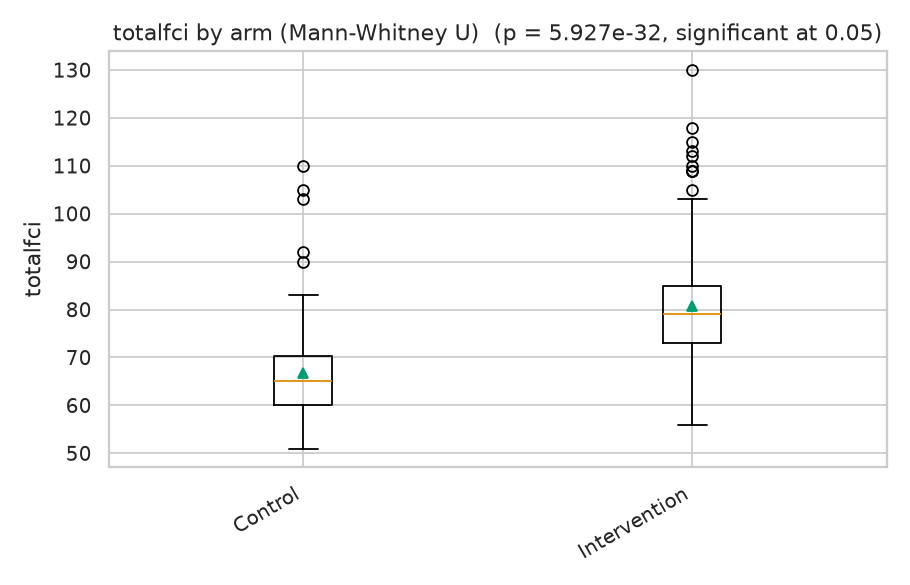

In [ ]:
print("[[step]] gen_1788249168235_4 start 6/7 ▶ Proving: Mann-Whitney U", flush=True)

# ── Mann-Whitney U ──
from scipy import stats as st
import json as _json

result = {}
method = 'mann-whitney u'
gcol, vcol, ca, cb = 'arm', 'totalfci', '', ''
_FEAT, _SUBJ, _COND = '', '', ''
_CA, _CB = '', ''
_PTEST, _CORR = 'paired-t', 'benjamini-hochberg'
_BA_LIMITS, _BA_POINTS = 'constant', 50000
_ALPHA_CFG = 0.05
_EQ_MARGIN, _EQ_POWER = 0.02, 0.8
_PERM_STAT, _PERM_N = 'mean-absolute-difference', 1000
_CHROM, _POS = '', ''
_REG_GAP, _REG_CUT, _REG_SMOOTH = 1000, 0.01, 'none'
_CA_FACTORS, _CA_N, _CA_TEST = [], 10, 'kruskal-wallis'
_CA_CORR, _CA_MAX, _SAMP = 'bonferroni', 50000, ''
_STATS_REQUESTED, _STATS_EXCLUDED = [], []
_STATS_TARGET, _STATS_FEATURES = '', []

# Column choices belong to this node. Keep the incoming frame so exclusions do
# not leak into any node that runs after it.
_STATS_INPUT_DF = df
_stats_missing = [c for c in _STATS_REQUESTED if c not in df.columns]
_stats_kept = ([c for c in _STATS_REQUESTED if c in df.columns]
               if _STATS_REQUESTED else list(df.columns))
_stats_kept = [c for c in _stats_kept if c not in _STATS_EXCLUDED]
df = df.loc[:, _stats_kept]
if _STATS_EXCLUDED:
    print("Mann-Whitney U: excluded from this node: "
          + ", ".join(str(c) for c in _STATS_EXCLUDED if c in _STATS_INPUT_DF.columns), flush=True)
if _stats_missing:
    print("Mann-Whitney U: requested columns not found: "
          + ", ".join(str(c) for c in _stats_missing), flush=True)

def _num(col):
    return pd.to_numeric(df[col], errors="coerce").dropna()

# When the user left the columns unset, pick sensible ones from the actual
# data instead of failing: a low-cardinality categorical for grouping, numeric
# columns for values/correlations. Every auto-choice is reported back with a
# "[[param]]" line so the canvas writes it into this node's parameters.
_raw_num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]

def _looks_like_identifier(col):
    """Keep an automatic choice away from row identifiers.

    An explicitly selected identifier is still honoured. This rule applies
    only when the node has to choose for itself.
    """
    _s = df[col].dropna()
    if len(_s) <= 20 or _s.nunique() != len(_s):
        return False
    try:
        _integer = bool(pd.api.types.is_integer_dtype(_s)) or bool((_s == _s.round()).all())
    except Exception:
        _integer = False
    _name = str(col).strip().lower()
    _named = (_name in ("id", "index", "rowid", "row_id")
              or _name.endswith(("_id", "_no", "_num"))
              or any(_t in _name for _t in ("recode", "accession", "uuid", "guid")))
    return _integer and _named

_num_cols = [c for c in _raw_num_cols if not _looks_like_identifier(c)]
if not _num_cols:
    _num_cols = _raw_num_cols
_continuous_num_cols = [c for c in _num_cols if df[c].nunique(dropna=True) > 20]
_cat_cols = [c for c in df.columns
             if not pd.api.types.is_numeric_dtype(df[c]) and 2 <= df[c].nunique(dropna=True) <= 20]
_auto = {}
if any(k in method for k in ("t-test", "t test", "anova", "mann", "kruskal")):
    if not gcol or gcol not in df.columns:
        gcol = _cat_cols[0] if _cat_cols else next(
            (c for c in df.columns if df[c].nunique(dropna=True) <= 20), df.columns[0])
        _auto["group_column"] = gcol
    if not vcol or vcol not in df.columns:
        _value_pool = _continuous_num_cols or _num_cols
        vcol = next((c for c in _value_pool if c != gcol), _value_pool[0] if _value_pool else df.columns[-1])
        _auto["value_column"] = vcol
elif "correlation" in method:
    if not ca or ca not in df.columns:
        ca = _num_cols[0] if _num_cols else df.columns[0]
        _auto["column_a"] = ca
    if not cb or cb not in df.columns:
        cb = next((c for c in _num_cols if c != ca), df.columns[-1])
        _auto["column_b"] = cb
elif "chi" in method:
    _pool = _cat_cols + [c for c in _num_cols if df[c].nunique(dropna=True) <= 10]
    if not ca or ca not in df.columns:
        ca = _pool[0] if _pool else df.columns[0]
        _auto["column_a"] = ca
    if not cb or cb not in df.columns:
        cb = next((c for c in _pool if c != ca), df.columns[-1])
        _auto["column_b"] = cb
elif "normality" in method:
    if not ca or ca not in df.columns:
        _value_pool = _continuous_num_cols or _num_cols
        ca = _value_pool[0] if _value_pool else df.columns[0]
        _auto["column"] = ca
elif "ols" in method:
    if (not _STATS_TARGET or _STATS_TARGET not in df.columns) and (not vcol or vcol not in df.columns):
        vcol = _num_cols[-1] if _num_cols else df.columns[-1]
        _auto["value_column"] = vcol
for _k, _v in _auto.items():
    print("[[param]] gen_1788249168235_4 " + str(_k) + " " + str(_v), flush=True)
if _auto:
    print("Mann-Whitney U: no column configured -- auto-selected "
          + ", ".join(f"{k}={v}" for k, v in _auto.items()), flush=True)

# Every test also draws ITS OWN plot(s), saved under this node's id so the
# double-click popup shows exactly this component's visual evidence.
def _p_note(p):
    return ("significant at 0.05" if p < 0.05 else "not significant at 0.05")

def _group_boxplot(title, p=None):
    data = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
    names = [str(k) for k, _ in df.groupby(gcol)]
    plt.figure(figsize=(7, 4.5))
    plt.boxplot(data[:12], showmeans=True)
    plt.xticks(range(1, min(len(names), 12) + 1), names[:12], rotation=30, ha="right")
    if p is not None:
        title += f"  (p = {p:.4g}, {_p_note(p)})"
    plt.title(title); plt.ylabel(vcol)
    save_fig("gen_1788249168235_4__group_comparison")

try:
    if "descriptive" in method:
        result = _json.loads(df.describe(include="all").to_json())
        _num_df = df.select_dtypes(include=[np.number])
        if _num_df.shape[1] > 0:
            _cols, _seen = [], {}
            for _c in _num_df.columns:
                if len(_cols) >= 12:
                    break
                if distribution_is_worth_plotting(
                        "Distribution of %s" % _c, _num_df[_c], _seen):
                    _cols.append(_c)
                    _seen[_c] = _num_df[_c]
            if _cols:
                plt.figure(figsize=(7, 4.5))
                plt.boxplot([_num_df[c].dropna().values for c in _cols], showmeans=True)
                plt.xticks(range(1, len(_cols) + 1), _cols, rotation=30, ha="right")
                plt.title("Distribution of numeric columns")
                save_fig("gen_1788249168235_4__distributions")
    elif "t-test" in method or "t test" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)][:2]
        t, p = st.ttest_ind(groups[0], groups[1], equal_var=False)
        result = {"statistic": float(t), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Welch t-test)", p)
    elif "anova" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
        f, p = st.f_oneway(*groups)
        result = {"F": float(f), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (one-way ANOVA)", p)
    elif "chi" in method:
        table = pd.crosstab(df[ca], df[cb])
        chi2, p, dof, _ = st.chi2_contingency(table)
        result = {"chi2": float(chi2), "p_value": float(p), "dof": int(dof)}
        _t = table.iloc[:15, :15]
        plt.figure(figsize=(7, 5.5))
        plt.imshow(_t.values, cmap="YlOrBr", aspect="auto")
        plt.colorbar(label="count")
        plt.xticks(range(_t.shape[1]), [str(c) for c in _t.columns], rotation=30, ha="right", fontsize=8)
        plt.yticks(range(_t.shape[0]), [str(i) for i in _t.index], fontsize=8)
        for _i in range(_t.shape[0]):
            for _j in range(_t.shape[1]):
                plt.text(_j, _i, str(_t.values[_i, _j]), ha="center", va="center", fontsize=7)
        plt.title(f"{ca} x {cb} contingency  (chi2 p = {p:.4g}, {_p_note(p)})")
        plt.xlabel(cb); plt.ylabel(ca)
        save_fig("gen_1788249168235_4__contingency")
    elif "correlation" in method:
        a, b = _num(ca), _num(cb)
        n = min(len(a), len(b)); a, b = a.iloc[:n], b.iloc[:n]
        fn = {"pearson": st.pearsonr, "spearman": st.spearmanr, "kendall": st.kendalltau}.get('pearson', st.pearsonr)
        r, p = fn(a, b)
        result = {"coefficient": float(r), "p_value": float(p)}
        plt.figure(figsize=(6.5, 5))
        _samp = min(len(a), 3000)
        plt.scatter(a.iloc[:_samp], b.iloc[:_samp], s=10, alpha=0.5)
        try:
            _k, _c = np.polyfit(a, b, 1)
            _xs = np.linspace(float(a.min()), float(a.max()), 50)
            plt.plot(_xs, _k * _xs + _c, color="crimson", linewidth=1.5)
        except Exception:
            pass
        plt.xlabel(ca); plt.ylabel(cb)
        plt.title(f"pearson r = {r:.3f}  (p = {p:.4g}, {_p_note(p)})")
        save_fig("gen_1788249168235_4__correlation_scatter")
    elif "normality" in method:
        if not _num_cols:
            raise ValueError(
                "a normality test needs a numeric column; the columns present "
                "are %s" % ", ".join(str(c) for c in df.columns[:12]))
        _col = ca if ca in df.columns else _num_cols[0]
        x = _num(_col)
        w, p = st.shapiro(x.sample(min(5000, len(x)), random_state=42))
        result = {"statistic": float(w), "p_value": float(p)}
        fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(9, 4))
        _ax1.hist(x, bins=30, edgecolor="white")
        _ax1.set_title(f"Distribution of {_col}")
        st.probplot(x, dist="norm", plot=_ax2)
        _ax2.set_title(f"Q-Q plot  (Shapiro p = {p:.4g})")
        fig.suptitle("normal" if p >= 0.05 else "deviates from normal", fontsize=10)
        save_fig("gen_1788249168235_4__normality")
    elif "mann" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)][:2]
        u, p = st.mannwhitneyu(groups[0], groups[1])
        result = {"U": float(u), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Mann-Whitney U)", p)
    elif "component association" in method:
        # DO THE MAIN DIRECTIONS OF VARIATION TRACK THE STUDY DESIGN?
        #
        # Principal components find the directions the samples actually vary
        # along. Whether those directions line up with anything in the design
        # is the question worth asking: if the largest source of variation is
        # the batch or the protocol, it is inside every result the study
        # reports.
        #
        # This is also what gives a null result its positive control. A design
        # where no component tracks the protocol but every component tracks the
        # donor has shown it can detect structure and simply did not find the
        # protocol, which is a stronger statement than "we found nothing".
        _fs = [c for c in _CA_FACTORS if c in df.columns]
        _long = _FEAT in df.columns and _SAMP in df.columns and vcol in df.columns
        if not _fs:
            step_skipped("gen_1788249168235_4", "no factor columns to test the components against")
        elif not _long and not any(pd.api.types.is_numeric_dtype(df[c]) for c in df.columns):
            step_skipped("gen_1788249168235_4", "needs either long data (feature, sample, value) or a "
                         "transposed frame with one row per sample")
        else:
            if _long:
                # Long data: pivot to samples by features first, keeping the
                # most variable, since a feature that does not vary cannot
                # separate samples.
                _v = df.groupby(_FEAT, observed=True)[vcol].var()
                _keep = _v.nlargest(min(_CA_MAX, len(_v))).index
                _sub = df[df[_FEAT].isin(_keep)]
                _M = _sub.pivot_table(index=_SAMP, columns=_FEAT, values=vcol,
                                      aggfunc="mean", observed=True)
                _facts = pd.DataFrame(
                    {c: _sub.groupby(_SAMP, observed=True)[c].first() for c in _fs}
                ).reindex(_M.index)
                if len(_v) > len(_keep):
                    print("using the %d most variable of %d features"
                          % (len(_keep), len(_v)), flush=True)
            else:
                _M = df.select_dtypes(include=[np.number]).drop(columns=_fs, errors="ignore")
                _facts = df[_fs]

            _M = _M.dropna(axis=1, how="any")
            if _M.shape[0] < 3 or _M.shape[1] < 2:
                step_skipped("gen_1788249168235_4", "only %d sample(s) and %d usable feature(s)"
                             % (_M.shape[0], _M.shape[1]))
            else:
                from sklearn.decomposition import PCA as _PCA
                _n = int(min(_CA_N, _M.shape[0] - 1, _M.shape[1]))
                _X = _M.to_numpy(dtype=float)
                _pca = _PCA(n_components=_n, svd_solver="randomized", random_state=42)
                _S = _pca.fit_transform(_X - _X.mean(axis=0))
                _ev = _pca.explained_variance_ratio_

                _rows, _pvals = [], []
                for _i in range(_n):
                    for _f in _fs:
                        _lab = _facts[_f].astype(str).to_numpy()
                        try:
                            if "spearman" in _CA_TEST:
                                _num = pd.to_numeric(_facts[_f], errors="coerce").to_numpy()
                                _ok = np.isfinite(_num)
                                _p = st.spearmanr(_S[_ok, _i], _num[_ok]).pvalue if _ok.sum() > 2 else float("nan")
                            else:
                                _g = [_S[_lab == lv, _i] for lv in pd.unique(_lab)]
                                _g = [x for x in _g if len(x) > 0]
                                _p = st.kruskal(*_g).pvalue if len(_g) > 1 else float("nan")
                        except Exception:
                            _p = float("nan")
                        _rows.append({"component": _i + 1, "factor": _f,
                                      "variance_explained": float(_ev[_i]), "p_value": _p})
                        _pvals.append(_p)

                # Corrected across EVERY component and factor tested together,
                # because that is how many questions were asked.
                _pa = np.array(_pvals, dtype=float)
                _valid = np.isfinite(_pa)
                _adj = np.full_like(_pa, np.nan)
                _m = int(_valid.sum())
                if _m:
                    if "none" in _CA_CORR:
                        _adj[_valid] = _pa[_valid]
                    elif "benjamini" in _CA_CORR:
                        _o = np.argsort(_pa[_valid])
                        _r = _pa[_valid][_o] * _m / (np.arange(_m) + 1)
                        _r = np.minimum.accumulate(_r[::-1])[::-1]
                        _out = np.empty(_m); _out[_o] = np.minimum(_r, 1.0)
                        _adj[_valid] = _out
                    else:
                        _adj[_valid] = np.minimum(_pa[_valid] * _m, 1.0)
                _res = pd.DataFrame(_rows)
                _res["p_adjusted"] = _adj
                _alpha = float(_ALPHA_CFG)
                _res["associated"] = _res["p_adjusted"] < _alpha
                _res.to_csv(ARTIFACTS / "gen_1788249168235_4__component_association.csv", index=False)

                METRICS["gen_1788249168235_4::samples"] = int(_M.shape[0])
                METRICS["gen_1788249168235_4::features_used"] = int(_M.shape[1])
                METRICS["gen_1788249168235_4::components"] = _n
                METRICS["gen_1788249168235_4::variance_pc1"] = float(_ev[0])
                for _f in _fs:
                    _sel = _res[_res["factor"] == _f]
                    METRICS["gen_1788249168235_4::associated_" + str(_f)] = int(_sel["associated"].sum())
                    METRICS["gen_1788249168235_4::smallest_p_" + str(_f)] = float(np.nanmin(_sel["p_value"]))                         if np.isfinite(_sel["p_value"]).any() else float("nan")
                result = {"samples": int(_M.shape[0]), "components": _n,
                          "factors_tested": len(_fs)}

                print("%d samples, %d features, %d components (PC1 explains %.1f%%)"
                      % (_M.shape[0], _M.shape[1], _n, _ev[0] * 100), flush=True)
                for _f in _fs:
                    _sel = _res[_res["factor"] == _f]
                    _k = int(_sel["associated"].sum())
                    print("  %s: %d of %d components associated after correction%s"
                          % (_f, _k, _n,
                             "" if _k else " (nothing in this factor tracks the variation)"),
                          flush=True)
                emit_preview("gen_1788249168235_4", _res.head(50))

                try:
                    _first = _fs[0]
                    _lab = _facts[_first].astype(str).to_numpy()
                    fig, ax = plt.subplots(figsize=(7, 5.4))
                    for lv in pd.unique(_lab):
                        _sel = _lab == lv
                        ax.scatter(_S[_sel, 0], _S[_sel, 1] if _n > 1 else np.zeros(_sel.sum()),
                                   s=48, alpha=0.85, label=str(lv), edgecolors="none")
                    ax.set_xlabel("PC1 (%.1f%%)" % (_ev[0] * 100))
                    ax.set_ylabel("PC2 (%.1f%%)" % (_ev[1] * 100) if _n > 1 else "")
                    ax.set_title("Samples in the first two components, by %s" % _first, fontsize=10)
                    ax.legend(fontsize=8, title=_first, title_fontsize=8)
                    save_fig("gen_1788249168235_4__components")
                except Exception as _e:
                    print("component figure skipped: %s" % _e, flush=True)

    elif "differential regions" in method:
        # REGIONS, NOT SITES.
        #
        # A difference too small to survive correction at any one position can
        # be real and consistent across a run of neighbouring positions. The
        # site-level test pays the multiple-testing burden once per site while
        # the evidence is spread over several, so it cannot see that. This
        # groups nearby sites, scores each run, and judges the runs against a
        # null built the way the design allows.
        _need = [c for c in (_FEAT, _CHROM, _POS, _SUBJ, _COND, vcol) if not c or c not in df.columns]
        if _need:
            step_skipped("gen_1788249168235_4", "needs a feature, chromosome, position, subject, condition and "
                         "value column; missing or not found: " + ", ".join(str(c) for c in _need if c))
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("gen_1788249168235_4", "needs two different conditions; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _sub = [c for c in _pa.columns if c in _pb.columns]
                _ft = _pa.index.intersection(_pb.index)
                if len(_sub) < 2 or len(_ft) < 2:
                    step_skipped("gen_1788249168235_4", "only %d subject(s) and %d feature(s) measured under both "
                                 "conditions" % (len(_sub), len(_ft)))
                else:
                    _D = (_pa.loc[_ft, _sub].to_numpy(dtype=float)
                          - _pb.loc[_ft, _sub].to_numpy(dtype=float))

                    # Where each feature sits. Taken once per feature, because
                    # a probe has one position however many rows mention it.
                    _coord = (_w.drop_duplicates(subset=[_FEAT])
                                .set_index(_FEAT)[[_CHROM, _POS]].reindex(_ft))
                    _chr = _coord[_CHROM].astype(str).to_numpy()
                    _bp = pd.to_numeric(_coord[_POS], errors="coerce").to_numpy()
                    _placed = np.isfinite(_bp)
                    if _placed.sum() < 2:
                        step_skipped("gen_1788249168235_4", "no usable genomic positions in %r" % _POS)
                    else:
                        _D = _D[_placed]; _chr = _chr[_placed]; _bp = _bp[_placed]
                        # Sorted along the genome, because "neighbouring" is
                        # meaningless in the order a table happens to be in.
                        _ord = np.lexsort((_bp, _chr))
                        _chr, _bp, _D = _chr[_ord], _bp[_ord], _D[_ord]
                        _feat_sorted = np.asarray(_ft, dtype=object)[_placed][_ord]

                        # Clusters: a new one begins at a new chromosome or a
                        # gap wider than the researcher allowed. Computed once,
                        # since positions do not change under permutation.
                        _new = np.ones(len(_bp), dtype=bool)
                        _new[1:] = (_chr[1:] != _chr[:-1]) | ((_bp[1:] - _bp[:-1]) > _REG_GAP)
                        _clu = np.cumsum(_new) - 1
                        _n_clusters = int(_clu[-1]) + 1

                        def _regions(_stat):
                            """Runs of consecutive sites over the cutoff, and their areas.

                            A region breaks at a cluster edge, at a change of
                            sign, or where a site falls under the cutoff: a run
                            that changes direction is two findings, not one.
                            """
                            _over = np.abs(_stat) > _REG_CUT
                            _brk = np.ones(len(_stat), dtype=bool)
                            _brk[1:] = ((_clu[1:] != _clu[:-1])
                                        | (np.sign(_stat[1:]) != np.sign(_stat[:-1]))
                                        | (~_over[1:]) | (~_over[:-1]))
                            _gid = np.cumsum(_brk) - 1
                            return _gid, _over

                        def _areas(_stat):
                            _gid, _over = _regions(_stat)
                            if not _over.any():
                                return np.zeros(1), _gid, _over
                            _ar = np.bincount(_gid[_over], weights=np.abs(_stat[_over]))
                            # bincount returns a slot for every break-group,
                            # including the runs that never cleared the cutoff.
                            # Counting those reported 118,600 "regions" where
                            # there were a few hundred: a wrong number, in the
                            # record, about the thing the step exists to count.
                            return _ar[_ar > 0], _gid, _over

                        def _per_site(_M):
                            _v = np.nanmean(_M, axis=1)
                            if "running" in _REG_SMOOTH:
                                # Three-point mean inside each cluster. Jaffe
                                # et al. use loess; this is the cheap relative
                                # and the node's help says so rather than
                                # implying the results are interchangeable.
                                _pad = _v.copy()
                                _same_l = np.zeros(len(_v), dtype=bool); _same_l[1:] = _clu[1:] == _clu[:-1]
                                _same_r = np.zeros(len(_v), dtype=bool); _same_r[:-1] = _clu[:-1] == _clu[1:]
                                _acc = _v.copy(); _cnt = np.ones(len(_v))
                                _acc[_same_l] += _v[np.roll(np.arange(len(_v)), 1)][_same_l]; _cnt[_same_l] += 1
                                _acc[_same_r] += _v[np.roll(np.arange(len(_v)), -1)][_same_r]; _cnt[_same_r] += 1
                                _pad = _acc / _cnt
                                return _pad
                            return _v

                        _stat = _per_site(_D)
                        _obs_area, _gid, _over = _areas(_stat)

                        # FAMILY-WISE ERROR, NOT PER REGION.
                        #
                        # Each permutation contributes its LARGEST region, so a
                        # region is judged against the biggest thing chance
                        # produced anywhere in the genome. That is what makes
                        # the rate family-wise rather than per-test, and it is
                        # the only correction that means anything when regions
                        # are found by searching.
                        _B = int(_PERM_N)
                        _rng = np.random.default_rng(0)
                        _null = np.empty(_B)
                        for _i in range(_B):
                            _sgn = _rng.choice([-1.0, 1.0], size=_D.shape[1])
                            _null[_i] = _areas(_per_site(_D * _sgn))[0].max()
                        _alpha = float(_ALPHA_CFG)
                        _thresh = float(np.quantile(_null, 1.0 - _alpha))
                        _pass = _obs_area > _thresh
                        _n_pass = int(_pass.sum())
                        _n_regions = int(len(_obs_area)) if _over.any() else 0

                        METRICS["gen_1788249168235_4::clusters"] = _n_clusters
                        METRICS["gen_1788249168235_4::regions_found"] = _n_regions
                        METRICS["gen_1788249168235_4::regions_significant"] = _n_pass
                        METRICS["gen_1788249168235_4::largest_region_area"] = float(_obs_area.max())
                        METRICS["gen_1788249168235_4::null_threshold"] = _thresh
                        METRICS["gen_1788249168235_4::permutations"] = _B
                        METRICS["gen_1788249168235_4::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"regions_found": _n_regions, "regions_significant": _n_pass,
                                  "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %d sites in %d clusters, %d candidate region(s), "
                              "%d significant at a family-wise error rate of %g"
                              % (_a, _b, len(_stat), _n_clusters, _n_regions, _n_pass, _alpha),
                              flush=True)
                        if not _n_pass:
                            print("no region beat the largest one chance produced: the biggest "
                                  "observed area is %.4f against a null threshold of %.4f. "
                                  "Regions of this size appear by accident in this design."
                                  % (_obs_area.max(), _thresh), flush=True)

                        # The regions themselves, so a reader can look at them
                        # whether or not any passed.
                        if _over.any():
                            _rows = []
                            _gsel = _gid[_over]
                            _order_g = np.argsort(_gsel, kind="stable")
                            _gs, _idx = np.unique(_gsel[_order_g], return_index=True)
                            _sites = np.flatnonzero(_over)[_order_g]
                            _bounds = np.append(_idx, len(_sites))
                            for _k, _g in enumerate(_gs):
                                _sl = _sites[_bounds[_k]:_bounds[_k + 1]]
                                if len(_sl) == 0:
                                    continue
                                _rows.append({
                                    "chromosome": _chr[_sl[0]],
                                    "start": float(_bp[_sl].min()),
                                    "end": float(_bp[_sl].max()),
                                    "sites": int(len(_sl)),
                                    "mean_difference": float(np.mean(_stat[_sl])),
                                    "area": float(np.sum(np.abs(_stat[_sl]))),
                                    "first_feature": str(_feat_sorted[_sl[0]]),
                                })
                            _rdf = pd.DataFrame(_rows).sort_values("area", ascending=False)
                            _rdf["passes_fwer"] = _rdf["area"] > _thresh
                            _rdf.to_csv(ARTIFACTS / "gen_1788249168235_4__regions.csv", index=False)
                            emit_preview("gen_1788249168235_4", _rdf.head(50))

                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 4.6))
                            ax.hist(_null, bins=40, color="#8899a6", edgecolor="none",
                                    label="largest region per permutation")
                            ax.axvline(_obs_area.max(), color="#C0392B", lw=1.8,
                                       label="largest observed (%.4f)" % _obs_area.max())
                            ax.axvline(_thresh, color="#C27840", lw=1.2, ls="--",
                                       label="%g threshold (%.4f)" % (_alpha, _thresh))
                            ax.set_xlabel("region area")
                            ax.set_ylabel("permutations")
                            ax.set_title("%s vs %s: %d region(s) beat chance"
                                         % (_a, _b, _n_pass), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("gen_1788249168235_4__regions")
                        except Exception as _e:
                            print("region figure skipped: %s" % _e, flush=True)

    elif "equivalence" in method or "permutation" in method:
        # Both of these need the same thing the paired test needs: one matrix
        # of differences, features by subjects, with each subject's two
        # measurements lined up against each other and nothing else.
        _ok = all(c and c in df.columns for c in (_SUBJ, _COND, vcol))
        if not _ok:
            step_skipped("gen_1788249168235_4", "needs a subject, condition and value column")
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("gen_1788249168235_4", "needs two different conditions; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _idx = _FEAT if (_FEAT and _FEAT in df.columns) else None
                if _idx is None:
                    # No feature column: one row, so the whole thing is a
                    # single measure per subject.
                    _pa = _w[_w[_COND].astype(str) == _a].groupby(_SUBJ, observed=True)[vcol].mean().to_frame().T
                    _pb = _w[_w[_COND].astype(str) == _b].groupby(_SUBJ, observed=True)[vcol].mean().to_frame().T
                else:
                    _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                        index=_idx, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                    _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                        index=_idx, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _sub = [c for c in _pa.columns if c in _pb.columns]
                _ft = _pa.index.intersection(_pb.index)
                if len(_sub) < 2 or len(_ft) == 0:
                    step_skipped("gen_1788249168235_4", "only %d subject(s) measured under both conditions"
                                 % len(_sub))
                else:
                    _D = (_pa.loc[_ft, _sub].to_numpy(dtype=float)
                          - _pb.loc[_ft, _sub].to_numpy(dtype=float))
                    _n = np.sum(~np.isnan(_D), axis=1)
                    _mean = np.nanmean(_D, axis=1)
                    _sd = np.nanstd(_D, axis=1, ddof=1)
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _se = _sd / np.sqrt(np.maximum(_n, 1))
                    _dfree = np.maximum(_n - 1, 1)
                    _alpha = float(_ALPHA_CFG)

                    if "equivalence" in method:
                        # TWO ONE-SIDED TESTS.
                        #
                        # Equivalence is not one test with the hypotheses
                        # swapped. It is two: that the difference is above
                        # -margin, and that it is below +margin. Both have to
                        # be rejected for the pair to be called equivalent, so
                        # the p-value is the LARGER of the two, which is why
                        # the procedure is conservative and why it means
                        # something.
                        _dlt = float(_EQ_MARGIN)
                        with np.errstate(invalid="ignore", divide="ignore"):
                            _p_lo = st.t.sf((_mean + _dlt) / _se, _dfree)
                            _p_hi = st.t.cdf((_mean - _dlt) / _se, _dfree)
                        _p_eq = np.maximum(_p_lo, _p_hi)
                        _eqv = _p_eq < _alpha
                        _n_eq = int(np.nansum(_eqv))
                        _tot = int(np.sum(np.isfinite(_p_eq)))

                        # WHAT THIS DESIGN COULD HAVE SEEN AT ALL.
                        #
                        # The number that makes any negative result readable.
                        # Without it, "we found no difference" and "we could
                        # not have found one" are the same sentence.
                        _tp = st.t.isf(1.0 - float(_EQ_POWER), _dfree)
                        _mdd = (st.t.isf(_alpha / 2, _dfree) + _tp) * _se
                        _mdd_gw = (st.t.isf(_alpha / max(2 * _tot, 2), _dfree) + _tp) * _se

                        METRICS["gen_1788249168235_4::features_tested"] = _tot
                        METRICS["gen_1788249168235_4::equivalent"] = _n_eq
                        METRICS["gen_1788249168235_4::equivalent_share"] = (float(_n_eq) / _tot) if _tot else float("nan")
                        METRICS["gen_1788249168235_4::margin"] = _dlt
                        METRICS["gen_1788249168235_4::median_observed_difference"] = float(np.nanmedian(np.abs(_mean)))
                        METRICS["gen_1788249168235_4::detection_limit"] = float(np.nanmedian(_mdd))
                        METRICS["gen_1788249168235_4::detection_limit_corrected"] = float(np.nanmedian(_mdd_gw))
                        METRICS["gen_1788249168235_4::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"equivalent": _n_eq, "of": _tot, "margin": _dlt,
                                  "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %d of %d equivalent within +/-%g (%.1f%%)"
                              % (_a, _b, _n_eq, _tot, _dlt,
                                 (100.0 * _n_eq / _tot) if _tot else float("nan")), flush=True)
                        print("this design could detect a difference of about %.4f per feature "
                              "(%.4f after correcting for %d tests); the median difference "
                              "observed is %.4f"
                              % (np.nanmedian(_mdd), np.nanmedian(_mdd_gw), _tot,
                                 np.nanmedian(np.abs(_mean))), flush=True)
                        if _tot and _n_eq < _tot:
                            print("the remaining %d were not SHOWN to differ either; they are "
                                  "the features this sample cannot decide" % (_tot - _n_eq),
                                  flush=True)

                        if _idx is not None:
                            pd.DataFrame({
                                "feature": np.asarray(_ft, dtype=object),
                                "mean_difference": _mean,
                                "p_equivalence": _p_eq,
                                "equivalent": _eqv,
                                "detection_limit": _mdd,
                            }).to_csv(ARTIFACTS / "gen_1788249168235_4__equivalence.csv", index=False)
                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 5))
                            _fin = np.isfinite(_mean)
                            ax.hist(_mean[_fin], bins=120, color="#8899a6", edgecolor="none")
                            ax.axvline(-_dlt, color="#C0392B", lw=1.2, ls="--",
                                       label="margin +/-%g" % _dlt)
                            ax.axvline(_dlt, color="#C0392B", lw=1.2, ls="--")
                            ax.axvline(0, color="#444", lw=0.8)
                            ax.set_xlabel("mean difference (%s minus %s)" % (_a, _b))
                            ax.set_ylabel("features")
                            ax.set_title("%d of %d equivalent within the margin"
                                         % (_n_eq, _tot), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("gen_1788249168235_4__equivalence")
                        except Exception as _e:
                            print("equivalence figure skipped: %s" % _e, flush=True)

                    else:
                        # ONE STATISTIC OVER EVERYTHING, AGAINST A NULL THE
                        # DESIGN ALLOWS.
                        #
                        # The permutation has to respect the pairing. These
                        # measurements are not independent: each subject was
                        # measured under both conditions, so the only thing
                        # free to vary under the null is WHICH of a subject's
                        # two values is called first. That is a sign flip per
                        # subject, and it is the exact test for a paired
                        # design rather than an approximation to one.
                        def _stat(_M):
                            _pf = np.nanmean(_M, axis=1)
                            if "max" in _PERM_STAT:
                                return float(np.nanmax(np.abs(_pf)))
                            if "root" in _PERM_STAT:
                                return float(np.sqrt(np.nanmean(_pf ** 2)))
                            return float(np.nanmean(np.abs(_pf)))

                        _obs = _stat(_D)
                        _B = int(_PERM_N)
                        _rng = np.random.default_rng(0)
                        _null = np.empty(_B)
                        for _i in range(_B):
                            _sgn = _rng.choice([-1.0, 1.0], size=_D.shape[1])
                            _null[_i] = _stat(_D * _sgn)
                        # +1 in both parts: the observed arrangement is itself
                        # one of the permutations, and leaving it out can
                        # report p = 0, which no permutation test can support.
                        _p = (1.0 + float(np.sum(_null >= _obs))) / (_B + 1.0)
                        _resolution = 1.0 / (_B + 1.0)

                        METRICS["gen_1788249168235_4::statistic"] = _obs
                        METRICS["gen_1788249168235_4::p_value"] = _p
                        METRICS["gen_1788249168235_4::permutations"] = _B
                        METRICS["gen_1788249168235_4::null_median"] = float(np.median(_null))
                        METRICS["gen_1788249168235_4::features"] = int(len(_ft))
                        METRICS["gen_1788249168235_4::subjects"] = int(len(_sub))
                        METRICS["gen_1788249168235_4::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"statistic": _obs, "p_value": _p,
                                  "permutations": _B, "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %s = %.6f across %d features and %d paired subjects; "
                              "p = %.4f from %d sign-flip permutations"
                              % (_a, _b, _PERM_STAT, _obs, len(_ft), len(_sub), _p, _B), flush=True)
                        if _p <= _resolution * 1.5:
                            print("that p is at the floor this many permutations can report "
                                  "(1/%d); raise the count to say anything smaller" % (_B + 1),
                                  flush=True)
                        print("a shift shared by every feature is invisible to testing them one "
                              "at a time, which is what this looks for and a per-feature test "
                              "cannot see", flush=True)
                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 4.6))
                            ax.hist(_null, bins=40, color="#8899a6", edgecolor="none",
                                    label="under the null")
                            ax.axvline(_obs, color="#C0392B", lw=1.8,
                                       label="observed (p = %.4f)" % _p)
                            ax.set_xlabel(_PERM_STAT.replace("-", " "))
                            ax.set_ylabel("permutations")
                            ax.set_title("%s vs %s, %d sign-flip permutations"
                                         % (_a, _b, _B), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("gen_1788249168235_4__permutation")
                        except Exception as _e:
                            print("permutation figure skipped: %s" % _e, flush=True)

    elif "paired feature" in method:
        # THE SAME QUESTION, ASKED OF EVERY FEATURE, PAIRED WITHIN SUBJECT.
        #
        # An epigenome-wide study asks it 440,110 times. Looping would take
        # minutes and produce the same numbers, so the pairing is done as a
        # pivot and the test as one vectorised pass: differences per feature
        # per subject, then a one-sample test of those differences against
        # zero. That is exactly what a paired t-test is.
        _need = [c for c in (_FEAT, _SUBJ, _COND, vcol) if not c or c not in df.columns]
        if _need:
            _missing = [n for n in ("feature", "subject", "condition", "value")
                        if not [_FEAT, _SUBJ, _COND, vcol][("feature","subject","condition","value").index(n)]
                        or [_FEAT, _SUBJ, _COND, vcol][("feature","subject","condition","value").index(n)] not in df.columns]
            step_skipped("gen_1788249168235_4", "needs a feature, subject, condition and value column; missing: "
                         + ", ".join(_missing))
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("gen_1788249168235_4", "needs two different conditions to compare; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                # feature x subject, one frame per condition, so subtracting
                # them pairs every measurement with its own subject's other
                # measurement and nothing else.
                _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _shared_subj = [c for c in _pa.columns if c in _pb.columns]
                _shared_feat = _pa.index.intersection(_pb.index)
                if len(_shared_subj) < 2 or len(_shared_feat) == 0:
                    step_skipped("gen_1788249168235_4",
                                 "only %d subject(s) measured under both conditions and %d shared feature(s); "
                                 "a paired test needs at least two of each"
                                 % (len(_shared_subj), len(_shared_feat)))
                else:
                    _d = (_pa.loc[_shared_feat, _shared_subj].to_numpy(dtype=float)
                          - _pb.loc[_shared_feat, _shared_subj].to_numpy(dtype=float))
                    _n_ok = np.sum(~np.isnan(_d), axis=1)
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _mean = np.nanmean(_d, axis=1)
                        _sd = np.nanstd(_d, axis=1, ddof=1)
                        _se = _sd / np.sqrt(np.maximum(_n_ok, 1))
                        _t = np.where(_se > 0, _mean / _se, np.nan)
                    _dfree = np.maximum(_n_ok - 1, 1)
                    _p = np.where(np.isnan(_t), np.nan,
                                  2 * st.t.sf(np.abs(np.nan_to_num(_t)), _dfree))
                    if "wilcoxon" in _PTEST:
                        # Signed-rank per feature. Only worth the loop when
                        # asked for, and only over features with enough pairs.
                        _p = np.full(len(_shared_feat), np.nan)
                        for _i in range(_d.shape[0]):
                            _row = _d[_i][~np.isnan(_d[_i])]
                            if len(_row) >= 6 and np.any(_row != 0):
                                try:
                                    _p[_i] = st.wilcoxon(_row).pvalue
                                except Exception:
                                    pass

                    _valid = ~np.isnan(_p)
                    _adj = np.full_like(_p, np.nan, dtype=float)
                    _pv = _p[_valid]
                    _m = len(_pv)
                    if _m:
                        if "bonferroni" in _CORR:
                            _adj[_valid] = np.minimum(_pv * _m, 1.0)
                        elif "none" in _CORR:
                            _adj[_valid] = _pv
                        else:
                            # Benjamini-Hochberg, with the monotonicity step
                            # that stops a later q falling below an earlier one.
                            _order = np.argsort(_pv)
                            _ranked = _pv[_order] * _m / (np.arange(_m) + 1)
                            _ranked = np.minimum.accumulate(_ranked[::-1])[::-1]
                            _out = np.empty(_m); _out[_order] = np.minimum(_ranked, 1.0)
                            _adj[_valid] = _out

                    _res = pd.DataFrame({
                        "feature": np.asarray(_shared_feat, dtype=object),
                        "mean_difference": _mean,
                        "t": _t,
                        "p_value": _p,
                        "p_adjusted": _adj,
                        "pairs": _n_ok,
                    }).sort_values("p_value", na_position="last")
                    _alpha = float(_ALPHA_CFG)
                    _sig = int(np.nansum(_adj < _alpha))

                    _res.to_csv(ARTIFACTS / "gen_1788249168235_4__paired_feature_test.csv", index=False)
                    METRICS["gen_1788249168235_4::features_tested"] = int(len(_shared_feat))
                    METRICS["gen_1788249168235_4::subjects_paired"] = int(len(_shared_subj))
                    METRICS["gen_1788249168235_4::significant"] = _sig
                    METRICS["gen_1788249168235_4::comparison"] = "%s vs %s" % (_a, _b)
                    METRICS["gen_1788249168235_4::smallest_p"] = float(np.nanmin(_p)) if np.any(_valid) else float("nan")
                    # WHAT A NULL RESULT HERE ACTUALLY MEANS.
                    #
                    # "No feature reached significance" is a statement about
                    # the sample size as much as about the effect, and the two
                    # read identically unless the detection limit is reported
                    # beside it. Free to compute: the spread is already here.
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _mdd80 = (st.t.isf(_alpha / max(2 * _m, 2), _dfree)
                                  + st.t.isf(0.20, _dfree)) * _se
                    METRICS["gen_1788249168235_4::detection_limit"] = float(np.nanmedian(_mdd80))
                    if not _sig and np.isfinite(np.nanmedian(_mdd80)):
                        print("nothing reached significance. at this sample size the smallest "
                              "difference this test could have found is about %.4f, against a "
                              "median observed difference of %.4f: a real effect smaller than "
                              "that would not appear here"
                              % (np.nanmedian(_mdd80), np.nanmedian(np.abs(_mean))), flush=True)
                    result = {"features_tested": int(len(_shared_feat)),
                              "subjects_paired": int(len(_shared_subj)),
                              "significant": _sig, "comparison": "%s vs %s" % (_a, _b)}

                    # A finding of NOTHING is a finding, and the sentence has
                    # to say so plainly rather than leaving an empty table to
                    # be read as a failed step.
                    print("%s vs %s: %d features tested across %d paired subjects, "
                          "%d significant at %s < %.3g%s"
                          % (_a, _b, len(_shared_feat), len(_shared_subj), _sig,
                             "adjusted p" if "none" not in _CORR else "p", _alpha,
                             "" if _sig else " -- none reached significance"), flush=True)

                    # Volcano: effect size against evidence, which is the plot
                    # that shows a null result honestly. A difference can be
                    # large and unsupported, or tiny and certain.
                    try:
                        _fin = np.isfinite(_p) & np.isfinite(_mean) & (_p > 0)
                        if _fin.sum():
                            fig, ax = plt.subplots(figsize=(7, 5))
                            ax.scatter(_mean[_fin], -np.log10(_p[_fin]), s=4, alpha=0.25,
                                       color="#8899a6", edgecolors="none")
                            _hit = _fin & (_adj < _alpha)
                            if _hit.sum():
                                ax.scatter(_mean[_hit], -np.log10(_p[_hit]), s=8, alpha=0.9,
                                           color="#C0392B", edgecolors="none",
                                           label="%d significant" % int(_hit.sum()))
                                ax.legend(loc="upper right", fontsize=8)
                            ax.axvline(0, color="#444", lw=0.8)
                            ax.set_xlabel("mean difference (%s minus %s)" % (_a, _b))
                            ax.set_ylabel("-log10 p")
                            ax.set_title("%s vs %s, paired across %d subjects"
                                         % (_a, _b, len(_shared_subj)), fontsize=10)
                            save_fig("gen_1788249168235_4__volcano")
                    except Exception as _e:
                        print("volcano plot skipped: %s" % _e, flush=True)
                    emit_preview("gen_1788249168235_4", _res.head(50))

    elif "method agreement" in method:
        # DO TWO WAYS OF MEASURING THE SAME THING AGREE.
        #
        # Correlation is the wrong tool and the usual mistake: two methods
        # with a constant offset correlate perfectly and disagree on every
        # single measurement. Bland-Altman asks the right question by plotting
        # the difference against the average.
        _need_ok = _SUBJ in df.columns and _COND in df.columns and vcol in df.columns
        if not _need_ok:
            step_skipped("gen_1788249168235_4", "needs a subject, method and value column")
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("gen_1788249168235_4", "needs two different methods to compare; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _key = [_SUBJ] + ([_FEAT] if _FEAT and _FEAT in df.columns else [])
                _p2 = _w.pivot_table(index=_key, columns=_COND, values=vcol, aggfunc="mean", observed=True)
                if _a not in _p2.columns or _b not in _p2.columns:
                    step_skipped("gen_1788249168235_4", "the two methods share no measured subject")
                else:
                    _va = _p2[_a].to_numpy(dtype=float)
                    _vb = _p2[_b].to_numpy(dtype=float)
                    _ok = np.isfinite(_va) & np.isfinite(_vb)
                    _va, _vb = _va[_ok], _vb[_ok]
                    if len(_va) < 3:
                        step_skipped("gen_1788249168235_4", "only %d paired measurement(s); too few to describe agreement"
                                     % len(_va))
                    else:
                        _avg = (_va + _vb) / 2.0
                        _dif = _va - _vb
                        _bias = float(np.mean(_dif))
                        _sd = float(np.std(_dif, ddof=1))
                        _lo, _hi = _bias - 1.96 * _sd, _bias + 1.96 * _sd

                        # Whether the constant limits are even appropriate.
                        # Bland-Altman assumes the differences are normal, and
                        # bounded measurements like a methylation beta are not.
                        _norm_p = float("nan")
                        try:
                            _samp = _dif if len(_dif) <= 5000 else np.random.default_rng(0).choice(_dif, 5000, replace=False)
                            _norm_p = float(st.shapiro(_samp).pvalue)
                        except Exception:
                            pass

                        _band = None
                        if "proportional" in _BA_LIMITS:
                            # A spread that changes with the measurement:
                            # sigma(x) = exp(a + b(x - c)^2), fitted by least
                            # squares on the log absolute difference. Bounded
                            # values disagree least at the extremes and most in
                            # the middle, and constant limits describe neither.
                            try:
                                _c = float(np.mean(_avg))
                                _X = np.column_stack([np.ones_like(_avg), (_avg - _c) ** 2])
                                _y = np.log(np.abs(_dif) + 1e-9)
                                _coef, *_ = np.linalg.lstsq(_X, _y, rcond=None)
                                _grid = np.linspace(np.min(_avg), np.max(_avg), 200)
                                _sig = np.exp(_coef[0] + _coef[1] * (_grid - _c) ** 2)
                                # exp of a log-|difference| fit estimates the
                                # mean absolute difference, and the 1.96-sigma
                                # band wants a standard deviation.
                                _band = (_grid, 1.96 * _sig * np.sqrt(np.pi / 2))
                                METRICS["gen_1788249168235_4::limits_shape_a"] = float(_coef[0])
                                METRICS["gen_1788249168235_4::limits_shape_b"] = float(_coef[1])
                            except Exception as _e:
                                print("proportional limits could not be fitted (%s); "
                                      "constant limits are shown" % _e, flush=True)

                        METRICS["gen_1788249168235_4::bias"] = _bias
                        METRICS["gen_1788249168235_4::limit_lower"] = float(_lo)
                        METRICS["gen_1788249168235_4::limit_upper"] = float(_hi)
                        METRICS["gen_1788249168235_4::pairs"] = int(len(_va))
                        METRICS["gen_1788249168235_4::comparison"] = "%s vs %s" % (_a, _b)
                        if np.isfinite(_norm_p):
                            # NAME THE HYPOTHESIS, NOT JUST THE NUMBER.
                            #
                            # This was called "differences_normal_p", and a
                            # report writer reading the evidence took it for a
                            # p-value ON the differences between methods and
                            # wrote that the methods differ significantly. The
                            # opposite of the finding, from a correct number.
                            #
                            # A bare p-value cannot be read without knowing
                            # what was tested, so the step says so itself
                            # rather than leaving the name to be guessed at.
                            METRICS["gen_1788249168235_4::normality_shapiro_p"] = _norm_p
                            METRICS["gen_1788249168235_4::normality_shapiro_tests"] = (
                                "normality of the paired differences, NOT a "
                                "difference between the two methods. A small "
                                "p means the differences are not normally "
                                "distributed, so constant limits of agreement "
                                "would misdescribe the spread and "
                                "proportional limits are used instead.")
                        result = {"bias": _bias, "limits_of_agreement": [float(_lo), float(_hi)],
                                  "pairs": int(len(_va)), "comparison": "%s vs %s" % (_a, _b)}
                        print("%s vs %s: bias %.5f, 95%% of differences between %.5f and %.5f, "
                              "over %d paired measurements%s"
                              % (_a, _b, _bias, _lo, _hi, len(_va),
                                 "" if not np.isfinite(_norm_p) or _norm_p >= 0.05
                                 else " (the differences are not normally distributed, "
                                      "so constant limits understate the spread at some levels)"),
                              flush=True)
                        try:
                            _n_plot = min(int(_BA_POINTS), len(_avg))
                            _sel = (np.arange(len(_avg)) if _n_plot >= len(_avg)
                                    else np.random.default_rng(0).choice(len(_avg), _n_plot, replace=False))
                            fig, ax = plt.subplots(figsize=(7.5, 5))
                            ax.scatter(_avg[_sel], _dif[_sel], s=3, alpha=0.15,
                                       color="#8899a6", edgecolors="none")
                            ax.axhline(_bias, color="#C27840", lw=1.4, label="bias %.4f" % _bias)
                            if _band is not None:
                                ax.plot(_band[0], _bias + _band[1], color="#C0392B", lw=1.2,
                                        label="proportional limits")
                                ax.plot(_band[0], _bias - _band[1], color="#C0392B", lw=1.2)
                            else:
                                ax.axhline(_hi, color="#C0392B", lw=1.1, ls="--",
                                           label="95%% limits (%.4f, %.4f)" % (_lo, _hi))
                                ax.axhline(_lo, color="#C0392B", lw=1.1, ls="--")
                            ax.set_xlabel("mean of %s and %s" % (_a, _b))
                            ax.set_ylabel("%s minus %s" % (_a, _b))
                            ax.set_title("Agreement between %s and %s (%d pairs%s)"
                                         % (_a, _b, len(_va),
                                            ", %d shown" % _n_plot if _n_plot < len(_va) else ""),
                                         fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("gen_1788249168235_4__bland_altman")
                        except Exception as _e:
                            print("agreement plot skipped: %s" % _e, flush=True)

    elif "kruskal" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
        h, p = st.kruskal(*groups)
        result = {"H": float(h), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Kruskal-Wallis)", p)
    elif "ols" in method:
        from sklearn.linear_model import LinearRegression
        tgt = _STATS_TARGET if _STATS_TARGET in df.columns else (
            vcol if vcol in df.columns else df.columns[-1])
        _feature_cols = [c for c in _STATS_FEATURES
                         if c in df.columns and c != tgt]
        Xr = (df[_feature_cols] if _feature_cols
              else df.select_dtypes(include=[np.number]).drop(columns=[tgt], errors="ignore"))
        Xr = Xr.fillna(0)
        yr = pd.to_numeric(df[tgt], errors="coerce").fillna(0)
        if Xr.shape[1] == 0:
            # Named here rather than left to sklearn, which answers "at least
            # one array or dtype is required" from inside its input check and
            # says nothing about which column it wanted.
            raise ValueError(
                "a regression needs at least one numeric predictor besides the "
                "response %r; the columns present are %s. Add an Encode step "
                "before this one, or use a table that holds the measurements."
                % (tgt, ", ".join(str(c) for c in df.columns[:12])))
        lr = LinearRegression().fit(Xr, yr)
        result = {"r_squared": float(lr.score(Xr, yr)), "n_features": int(Xr.shape[1])}
        _pred = lr.predict(Xr)
        fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(9, 4))
        _ax1.scatter(yr[:3000], _pred[:3000], s=10, alpha=0.5)
        _lim = [float(min(yr.min(), _pred.min())), float(max(yr.max(), _pred.max()))]
        _ax1.plot(_lim, _lim, color="crimson", linewidth=1)
        _ax1.set_xlabel(f"actual {tgt}"); _ax1.set_ylabel("predicted")
        _ax1.set_title(f"OLS fit  (R2 = {result['r_squared']:.3f})")
        _res = yr - _pred
        _ax2.hist(_res, bins=30, edgecolor="white")
        _ax2.set_title("Residuals"); _ax2.set_xlabel("actual - predicted")
        save_fig("gen_1788249168235_4__ols_fit")
    else:
        result = {"note": "unrecognized test"}
    if "p_value" in result:
        result["significant_at_0.05"] = bool(result["p_value"] < 0.05)
except Exception as _e:
    result = {"error": str(_e)}

for k, v in result.items():
    if isinstance(v, (int, float, bool)):
        METRICS[f"{method}::{k}"] = v          # legacy run-level key
        METRICS["gen_1788249168235_4::" + str(k)] = v            # per-node: two same-type tests stay separate
with open(ARTIFACTS / "gen_1788249168235_4__test_result.json", "w") as _f:
    _json.dump(result, _f, indent=2, default=str)
# a tidy per-node report table alongside the raw JSON
_rep_rows = [{"item": str(k), "value": v} for k, v in result.items()
             if not isinstance(v, dict)]
if _rep_rows:
    _rep = pd.DataFrame(_rep_rows)
    _rep.insert(0, "test", 'Mann-Whitney U')
    _rep.to_csv(ARTIFACTS / "gen_1788249168235_4__test_report.csv", index=False)
# concise line for the terminal (the full result is saved as an artifact)
_summary = {k: v for k, v in result.items() if isinstance(v, (int, float, bool))}
print(f"    Mann-Whitney U:", _summary if _summary else "computed (saved to results)", flush=True)
# Restore the exact input frame for the next node. Column exclusions are a
# view of this analysis, not a hidden Drop Columns transform.
df = _STATS_INPUT_DF

print("[[step]] gen_1788249168235_4 done 6/7 ✓ Mann-Whitney U", flush=True)

## Normality Test

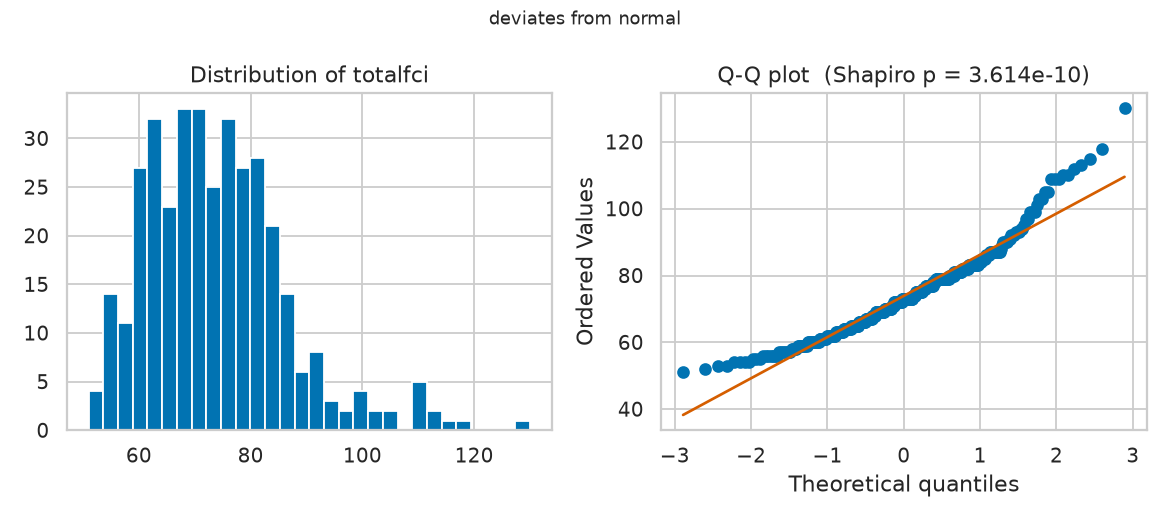

In [ ]:
print("[[step]] gen_1788249168235_5 start 7/7 ▶ Proving: Normality Test", flush=True)

# ── Normality Test ──
from scipy import stats as st
import json as _json

result = {}
method = 'normality test'
gcol, vcol, ca, cb = '', '', 'totalfci', ''
_FEAT, _SUBJ, _COND = '', '', ''
_CA, _CB = '', ''
_PTEST, _CORR = 'paired-t', 'benjamini-hochberg'
_BA_LIMITS, _BA_POINTS = 'constant', 50000
_ALPHA_CFG = 0.05
_EQ_MARGIN, _EQ_POWER = 0.02, 0.8
_PERM_STAT, _PERM_N = 'mean-absolute-difference', 1000
_CHROM, _POS = '', ''
_REG_GAP, _REG_CUT, _REG_SMOOTH = 1000, 0.01, 'none'
_CA_FACTORS, _CA_N, _CA_TEST = [], 10, 'kruskal-wallis'
_CA_CORR, _CA_MAX, _SAMP = 'bonferroni', 50000, ''
_STATS_REQUESTED, _STATS_EXCLUDED = [], []
_STATS_TARGET, _STATS_FEATURES = '', []

# Column choices belong to this node. Keep the incoming frame so exclusions do
# not leak into any node that runs after it.
_STATS_INPUT_DF = df
_stats_missing = [c for c in _STATS_REQUESTED if c not in df.columns]
_stats_kept = ([c for c in _STATS_REQUESTED if c in df.columns]
               if _STATS_REQUESTED else list(df.columns))
_stats_kept = [c for c in _stats_kept if c not in _STATS_EXCLUDED]
df = df.loc[:, _stats_kept]
if _STATS_EXCLUDED:
    print("Normality Test: excluded from this node: "
          + ", ".join(str(c) for c in _STATS_EXCLUDED if c in _STATS_INPUT_DF.columns), flush=True)
if _stats_missing:
    print("Normality Test: requested columns not found: "
          + ", ".join(str(c) for c in _stats_missing), flush=True)

def _num(col):
    return pd.to_numeric(df[col], errors="coerce").dropna()

# When the user left the columns unset, pick sensible ones from the actual
# data instead of failing: a low-cardinality categorical for grouping, numeric
# columns for values/correlations. Every auto-choice is reported back with a
# "[[param]]" line so the canvas writes it into this node's parameters.
_raw_num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]

def _looks_like_identifier(col):
    """Keep an automatic choice away from row identifiers.

    An explicitly selected identifier is still honoured. This rule applies
    only when the node has to choose for itself.
    """
    _s = df[col].dropna()
    if len(_s) <= 20 or _s.nunique() != len(_s):
        return False
    try:
        _integer = bool(pd.api.types.is_integer_dtype(_s)) or bool((_s == _s.round()).all())
    except Exception:
        _integer = False
    _name = str(col).strip().lower()
    _named = (_name in ("id", "index", "rowid", "row_id")
              or _name.endswith(("_id", "_no", "_num"))
              or any(_t in _name for _t in ("recode", "accession", "uuid", "guid")))
    return _integer and _named

_num_cols = [c for c in _raw_num_cols if not _looks_like_identifier(c)]
if not _num_cols:
    _num_cols = _raw_num_cols
_continuous_num_cols = [c for c in _num_cols if df[c].nunique(dropna=True) > 20]
_cat_cols = [c for c in df.columns
             if not pd.api.types.is_numeric_dtype(df[c]) and 2 <= df[c].nunique(dropna=True) <= 20]
_auto = {}
if any(k in method for k in ("t-test", "t test", "anova", "mann", "kruskal")):
    if not gcol or gcol not in df.columns:
        gcol = _cat_cols[0] if _cat_cols else next(
            (c for c in df.columns if df[c].nunique(dropna=True) <= 20), df.columns[0])
        _auto["group_column"] = gcol
    if not vcol or vcol not in df.columns:
        _value_pool = _continuous_num_cols or _num_cols
        vcol = next((c for c in _value_pool if c != gcol), _value_pool[0] if _value_pool else df.columns[-1])
        _auto["value_column"] = vcol
elif "correlation" in method:
    if not ca or ca not in df.columns:
        ca = _num_cols[0] if _num_cols else df.columns[0]
        _auto["column_a"] = ca
    if not cb or cb not in df.columns:
        cb = next((c for c in _num_cols if c != ca), df.columns[-1])
        _auto["column_b"] = cb
elif "chi" in method:
    _pool = _cat_cols + [c for c in _num_cols if df[c].nunique(dropna=True) <= 10]
    if not ca or ca not in df.columns:
        ca = _pool[0] if _pool else df.columns[0]
        _auto["column_a"] = ca
    if not cb or cb not in df.columns:
        cb = next((c for c in _pool if c != ca), df.columns[-1])
        _auto["column_b"] = cb
elif "normality" in method:
    if not ca or ca not in df.columns:
        _value_pool = _continuous_num_cols or _num_cols
        ca = _value_pool[0] if _value_pool else df.columns[0]
        _auto["column"] = ca
elif "ols" in method:
    if (not _STATS_TARGET or _STATS_TARGET not in df.columns) and (not vcol or vcol not in df.columns):
        vcol = _num_cols[-1] if _num_cols else df.columns[-1]
        _auto["value_column"] = vcol
for _k, _v in _auto.items():
    print("[[param]] gen_1788249168235_5 " + str(_k) + " " + str(_v), flush=True)
if _auto:
    print("Normality Test: no column configured -- auto-selected "
          + ", ".join(f"{k}={v}" for k, v in _auto.items()), flush=True)

# Every test also draws ITS OWN plot(s), saved under this node's id so the
# double-click popup shows exactly this component's visual evidence.
def _p_note(p):
    return ("significant at 0.05" if p < 0.05 else "not significant at 0.05")

def _group_boxplot(title, p=None):
    data = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
    names = [str(k) for k, _ in df.groupby(gcol)]
    plt.figure(figsize=(7, 4.5))
    plt.boxplot(data[:12], showmeans=True)
    plt.xticks(range(1, min(len(names), 12) + 1), names[:12], rotation=30, ha="right")
    if p is not None:
        title += f"  (p = {p:.4g}, {_p_note(p)})"
    plt.title(title); plt.ylabel(vcol)
    save_fig("gen_1788249168235_5__group_comparison")

try:
    if "descriptive" in method:
        result = _json.loads(df.describe(include="all").to_json())
        _num_df = df.select_dtypes(include=[np.number])
        if _num_df.shape[1] > 0:
            _cols, _seen = [], {}
            for _c in _num_df.columns:
                if len(_cols) >= 12:
                    break
                if distribution_is_worth_plotting(
                        "Distribution of %s" % _c, _num_df[_c], _seen):
                    _cols.append(_c)
                    _seen[_c] = _num_df[_c]
            if _cols:
                plt.figure(figsize=(7, 4.5))
                plt.boxplot([_num_df[c].dropna().values for c in _cols], showmeans=True)
                plt.xticks(range(1, len(_cols) + 1), _cols, rotation=30, ha="right")
                plt.title("Distribution of numeric columns")
                save_fig("gen_1788249168235_5__distributions")
    elif "t-test" in method or "t test" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)][:2]
        t, p = st.ttest_ind(groups[0], groups[1], equal_var=False)
        result = {"statistic": float(t), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Welch t-test)", p)
    elif "anova" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
        f, p = st.f_oneway(*groups)
        result = {"F": float(f), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (one-way ANOVA)", p)
    elif "chi" in method:
        table = pd.crosstab(df[ca], df[cb])
        chi2, p, dof, _ = st.chi2_contingency(table)
        result = {"chi2": float(chi2), "p_value": float(p), "dof": int(dof)}
        _t = table.iloc[:15, :15]
        plt.figure(figsize=(7, 5.5))
        plt.imshow(_t.values, cmap="YlOrBr", aspect="auto")
        plt.colorbar(label="count")
        plt.xticks(range(_t.shape[1]), [str(c) for c in _t.columns], rotation=30, ha="right", fontsize=8)
        plt.yticks(range(_t.shape[0]), [str(i) for i in _t.index], fontsize=8)
        for _i in range(_t.shape[0]):
            for _j in range(_t.shape[1]):
                plt.text(_j, _i, str(_t.values[_i, _j]), ha="center", va="center", fontsize=7)
        plt.title(f"{ca} x {cb} contingency  (chi2 p = {p:.4g}, {_p_note(p)})")
        plt.xlabel(cb); plt.ylabel(ca)
        save_fig("gen_1788249168235_5__contingency")
    elif "correlation" in method:
        a, b = _num(ca), _num(cb)
        n = min(len(a), len(b)); a, b = a.iloc[:n], b.iloc[:n]
        fn = {"pearson": st.pearsonr, "spearman": st.spearmanr, "kendall": st.kendalltau}.get('shapiro', st.pearsonr)
        r, p = fn(a, b)
        result = {"coefficient": float(r), "p_value": float(p)}
        plt.figure(figsize=(6.5, 5))
        _samp = min(len(a), 3000)
        plt.scatter(a.iloc[:_samp], b.iloc[:_samp], s=10, alpha=0.5)
        try:
            _k, _c = np.polyfit(a, b, 1)
            _xs = np.linspace(float(a.min()), float(a.max()), 50)
            plt.plot(_xs, _k * _xs + _c, color="crimson", linewidth=1.5)
        except Exception:
            pass
        plt.xlabel(ca); plt.ylabel(cb)
        plt.title(f"shapiro r = {r:.3f}  (p = {p:.4g}, {_p_note(p)})")
        save_fig("gen_1788249168235_5__correlation_scatter")
    elif "normality" in method:
        if not _num_cols:
            raise ValueError(
                "a normality test needs a numeric column; the columns present "
                "are %s" % ", ".join(str(c) for c in df.columns[:12]))
        _col = ca if ca in df.columns else _num_cols[0]
        x = _num(_col)
        w, p = st.shapiro(x.sample(min(5000, len(x)), random_state=42))
        result = {"statistic": float(w), "p_value": float(p)}
        fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(9, 4))
        _ax1.hist(x, bins=30, edgecolor="white")
        _ax1.set_title(f"Distribution of {_col}")
        st.probplot(x, dist="norm", plot=_ax2)
        _ax2.set_title(f"Q-Q plot  (Shapiro p = {p:.4g})")
        fig.suptitle("normal" if p >= 0.05 else "deviates from normal", fontsize=10)
        save_fig("gen_1788249168235_5__normality")
    elif "mann" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)][:2]
        u, p = st.mannwhitneyu(groups[0], groups[1])
        result = {"U": float(u), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Mann-Whitney U)", p)
    elif "component association" in method:
        # DO THE MAIN DIRECTIONS OF VARIATION TRACK THE STUDY DESIGN?
        #
        # Principal components find the directions the samples actually vary
        # along. Whether those directions line up with anything in the design
        # is the question worth asking: if the largest source of variation is
        # the batch or the protocol, it is inside every result the study
        # reports.
        #
        # This is also what gives a null result its positive control. A design
        # where no component tracks the protocol but every component tracks the
        # donor has shown it can detect structure and simply did not find the
        # protocol, which is a stronger statement than "we found nothing".
        _fs = [c for c in _CA_FACTORS if c in df.columns]
        _long = _FEAT in df.columns and _SAMP in df.columns and vcol in df.columns
        if not _fs:
            step_skipped("gen_1788249168235_5", "no factor columns to test the components against")
        elif not _long and not any(pd.api.types.is_numeric_dtype(df[c]) for c in df.columns):
            step_skipped("gen_1788249168235_5", "needs either long data (feature, sample, value) or a "
                         "transposed frame with one row per sample")
        else:
            if _long:
                # Long data: pivot to samples by features first, keeping the
                # most variable, since a feature that does not vary cannot
                # separate samples.
                _v = df.groupby(_FEAT, observed=True)[vcol].var()
                _keep = _v.nlargest(min(_CA_MAX, len(_v))).index
                _sub = df[df[_FEAT].isin(_keep)]
                _M = _sub.pivot_table(index=_SAMP, columns=_FEAT, values=vcol,
                                      aggfunc="mean", observed=True)
                _facts = pd.DataFrame(
                    {c: _sub.groupby(_SAMP, observed=True)[c].first() for c in _fs}
                ).reindex(_M.index)
                if len(_v) > len(_keep):
                    print("using the %d most variable of %d features"
                          % (len(_keep), len(_v)), flush=True)
            else:
                _M = df.select_dtypes(include=[np.number]).drop(columns=_fs, errors="ignore")
                _facts = df[_fs]

            _M = _M.dropna(axis=1, how="any")
            if _M.shape[0] < 3 or _M.shape[1] < 2:
                step_skipped("gen_1788249168235_5", "only %d sample(s) and %d usable feature(s)"
                             % (_M.shape[0], _M.shape[1]))
            else:
                from sklearn.decomposition import PCA as _PCA
                _n = int(min(_CA_N, _M.shape[0] - 1, _M.shape[1]))
                _X = _M.to_numpy(dtype=float)
                _pca = _PCA(n_components=_n, svd_solver="randomized", random_state=42)
                _S = _pca.fit_transform(_X - _X.mean(axis=0))
                _ev = _pca.explained_variance_ratio_

                _rows, _pvals = [], []
                for _i in range(_n):
                    for _f in _fs:
                        _lab = _facts[_f].astype(str).to_numpy()
                        try:
                            if "spearman" in _CA_TEST:
                                _num = pd.to_numeric(_facts[_f], errors="coerce").to_numpy()
                                _ok = np.isfinite(_num)
                                _p = st.spearmanr(_S[_ok, _i], _num[_ok]).pvalue if _ok.sum() > 2 else float("nan")
                            else:
                                _g = [_S[_lab == lv, _i] for lv in pd.unique(_lab)]
                                _g = [x for x in _g if len(x) > 0]
                                _p = st.kruskal(*_g).pvalue if len(_g) > 1 else float("nan")
                        except Exception:
                            _p = float("nan")
                        _rows.append({"component": _i + 1, "factor": _f,
                                      "variance_explained": float(_ev[_i]), "p_value": _p})
                        _pvals.append(_p)

                # Corrected across EVERY component and factor tested together,
                # because that is how many questions were asked.
                _pa = np.array(_pvals, dtype=float)
                _valid = np.isfinite(_pa)
                _adj = np.full_like(_pa, np.nan)
                _m = int(_valid.sum())
                if _m:
                    if "none" in _CA_CORR:
                        _adj[_valid] = _pa[_valid]
                    elif "benjamini" in _CA_CORR:
                        _o = np.argsort(_pa[_valid])
                        _r = _pa[_valid][_o] * _m / (np.arange(_m) + 1)
                        _r = np.minimum.accumulate(_r[::-1])[::-1]
                        _out = np.empty(_m); _out[_o] = np.minimum(_r, 1.0)
                        _adj[_valid] = _out
                    else:
                        _adj[_valid] = np.minimum(_pa[_valid] * _m, 1.0)
                _res = pd.DataFrame(_rows)
                _res["p_adjusted"] = _adj
                _alpha = float(_ALPHA_CFG)
                _res["associated"] = _res["p_adjusted"] < _alpha
                _res.to_csv(ARTIFACTS / "gen_1788249168235_5__component_association.csv", index=False)

                METRICS["gen_1788249168235_5::samples"] = int(_M.shape[0])
                METRICS["gen_1788249168235_5::features_used"] = int(_M.shape[1])
                METRICS["gen_1788249168235_5::components"] = _n
                METRICS["gen_1788249168235_5::variance_pc1"] = float(_ev[0])
                for _f in _fs:
                    _sel = _res[_res["factor"] == _f]
                    METRICS["gen_1788249168235_5::associated_" + str(_f)] = int(_sel["associated"].sum())
                    METRICS["gen_1788249168235_5::smallest_p_" + str(_f)] = float(np.nanmin(_sel["p_value"]))                         if np.isfinite(_sel["p_value"]).any() else float("nan")
                result = {"samples": int(_M.shape[0]), "components": _n,
                          "factors_tested": len(_fs)}

                print("%d samples, %d features, %d components (PC1 explains %.1f%%)"
                      % (_M.shape[0], _M.shape[1], _n, _ev[0] * 100), flush=True)
                for _f in _fs:
                    _sel = _res[_res["factor"] == _f]
                    _k = int(_sel["associated"].sum())
                    print("  %s: %d of %d components associated after correction%s"
                          % (_f, _k, _n,
                             "" if _k else " (nothing in this factor tracks the variation)"),
                          flush=True)
                emit_preview("gen_1788249168235_5", _res.head(50))

                try:
                    _first = _fs[0]
                    _lab = _facts[_first].astype(str).to_numpy()
                    fig, ax = plt.subplots(figsize=(7, 5.4))
                    for lv in pd.unique(_lab):
                        _sel = _lab == lv
                        ax.scatter(_S[_sel, 0], _S[_sel, 1] if _n > 1 else np.zeros(_sel.sum()),
                                   s=48, alpha=0.85, label=str(lv), edgecolors="none")
                    ax.set_xlabel("PC1 (%.1f%%)" % (_ev[0] * 100))
                    ax.set_ylabel("PC2 (%.1f%%)" % (_ev[1] * 100) if _n > 1 else "")
                    ax.set_title("Samples in the first two components, by %s" % _first, fontsize=10)
                    ax.legend(fontsize=8, title=_first, title_fontsize=8)
                    save_fig("gen_1788249168235_5__components")
                except Exception as _e:
                    print("component figure skipped: %s" % _e, flush=True)

    elif "differential regions" in method:
        # REGIONS, NOT SITES.
        #
        # A difference too small to survive correction at any one position can
        # be real and consistent across a run of neighbouring positions. The
        # site-level test pays the multiple-testing burden once per site while
        # the evidence is spread over several, so it cannot see that. This
        # groups nearby sites, scores each run, and judges the runs against a
        # null built the way the design allows.
        _need = [c for c in (_FEAT, _CHROM, _POS, _SUBJ, _COND, vcol) if not c or c not in df.columns]
        if _need:
            step_skipped("gen_1788249168235_5", "needs a feature, chromosome, position, subject, condition and "
                         "value column; missing or not found: " + ", ".join(str(c) for c in _need if c))
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("gen_1788249168235_5", "needs two different conditions; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _sub = [c for c in _pa.columns if c in _pb.columns]
                _ft = _pa.index.intersection(_pb.index)
                if len(_sub) < 2 or len(_ft) < 2:
                    step_skipped("gen_1788249168235_5", "only %d subject(s) and %d feature(s) measured under both "
                                 "conditions" % (len(_sub), len(_ft)))
                else:
                    _D = (_pa.loc[_ft, _sub].to_numpy(dtype=float)
                          - _pb.loc[_ft, _sub].to_numpy(dtype=float))

                    # Where each feature sits. Taken once per feature, because
                    # a probe has one position however many rows mention it.
                    _coord = (_w.drop_duplicates(subset=[_FEAT])
                                .set_index(_FEAT)[[_CHROM, _POS]].reindex(_ft))
                    _chr = _coord[_CHROM].astype(str).to_numpy()
                    _bp = pd.to_numeric(_coord[_POS], errors="coerce").to_numpy()
                    _placed = np.isfinite(_bp)
                    if _placed.sum() < 2:
                        step_skipped("gen_1788249168235_5", "no usable genomic positions in %r" % _POS)
                    else:
                        _D = _D[_placed]; _chr = _chr[_placed]; _bp = _bp[_placed]
                        # Sorted along the genome, because "neighbouring" is
                        # meaningless in the order a table happens to be in.
                        _ord = np.lexsort((_bp, _chr))
                        _chr, _bp, _D = _chr[_ord], _bp[_ord], _D[_ord]
                        _feat_sorted = np.asarray(_ft, dtype=object)[_placed][_ord]

                        # Clusters: a new one begins at a new chromosome or a
                        # gap wider than the researcher allowed. Computed once,
                        # since positions do not change under permutation.
                        _new = np.ones(len(_bp), dtype=bool)
                        _new[1:] = (_chr[1:] != _chr[:-1]) | ((_bp[1:] - _bp[:-1]) > _REG_GAP)
                        _clu = np.cumsum(_new) - 1
                        _n_clusters = int(_clu[-1]) + 1

                        def _regions(_stat):
                            """Runs of consecutive sites over the cutoff, and their areas.

                            A region breaks at a cluster edge, at a change of
                            sign, or where a site falls under the cutoff: a run
                            that changes direction is two findings, not one.
                            """
                            _over = np.abs(_stat) > _REG_CUT
                            _brk = np.ones(len(_stat), dtype=bool)
                            _brk[1:] = ((_clu[1:] != _clu[:-1])
                                        | (np.sign(_stat[1:]) != np.sign(_stat[:-1]))
                                        | (~_over[1:]) | (~_over[:-1]))
                            _gid = np.cumsum(_brk) - 1
                            return _gid, _over

                        def _areas(_stat):
                            _gid, _over = _regions(_stat)
                            if not _over.any():
                                return np.zeros(1), _gid, _over
                            _ar = np.bincount(_gid[_over], weights=np.abs(_stat[_over]))
                            # bincount returns a slot for every break-group,
                            # including the runs that never cleared the cutoff.
                            # Counting those reported 118,600 "regions" where
                            # there were a few hundred: a wrong number, in the
                            # record, about the thing the step exists to count.
                            return _ar[_ar > 0], _gid, _over

                        def _per_site(_M):
                            _v = np.nanmean(_M, axis=1)
                            if "running" in _REG_SMOOTH:
                                # Three-point mean inside each cluster. Jaffe
                                # et al. use loess; this is the cheap relative
                                # and the node's help says so rather than
                                # implying the results are interchangeable.
                                _pad = _v.copy()
                                _same_l = np.zeros(len(_v), dtype=bool); _same_l[1:] = _clu[1:] == _clu[:-1]
                                _same_r = np.zeros(len(_v), dtype=bool); _same_r[:-1] = _clu[:-1] == _clu[1:]
                                _acc = _v.copy(); _cnt = np.ones(len(_v))
                                _acc[_same_l] += _v[np.roll(np.arange(len(_v)), 1)][_same_l]; _cnt[_same_l] += 1
                                _acc[_same_r] += _v[np.roll(np.arange(len(_v)), -1)][_same_r]; _cnt[_same_r] += 1
                                _pad = _acc / _cnt
                                return _pad
                            return _v

                        _stat = _per_site(_D)
                        _obs_area, _gid, _over = _areas(_stat)

                        # FAMILY-WISE ERROR, NOT PER REGION.
                        #
                        # Each permutation contributes its LARGEST region, so a
                        # region is judged against the biggest thing chance
                        # produced anywhere in the genome. That is what makes
                        # the rate family-wise rather than per-test, and it is
                        # the only correction that means anything when regions
                        # are found by searching.
                        _B = int(_PERM_N)
                        _rng = np.random.default_rng(0)
                        _null = np.empty(_B)
                        for _i in range(_B):
                            _sgn = _rng.choice([-1.0, 1.0], size=_D.shape[1])
                            _null[_i] = _areas(_per_site(_D * _sgn))[0].max()
                        _alpha = float(_ALPHA_CFG)
                        _thresh = float(np.quantile(_null, 1.0 - _alpha))
                        _pass = _obs_area > _thresh
                        _n_pass = int(_pass.sum())
                        _n_regions = int(len(_obs_area)) if _over.any() else 0

                        METRICS["gen_1788249168235_5::clusters"] = _n_clusters
                        METRICS["gen_1788249168235_5::regions_found"] = _n_regions
                        METRICS["gen_1788249168235_5::regions_significant"] = _n_pass
                        METRICS["gen_1788249168235_5::largest_region_area"] = float(_obs_area.max())
                        METRICS["gen_1788249168235_5::null_threshold"] = _thresh
                        METRICS["gen_1788249168235_5::permutations"] = _B
                        METRICS["gen_1788249168235_5::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"regions_found": _n_regions, "regions_significant": _n_pass,
                                  "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %d sites in %d clusters, %d candidate region(s), "
                              "%d significant at a family-wise error rate of %g"
                              % (_a, _b, len(_stat), _n_clusters, _n_regions, _n_pass, _alpha),
                              flush=True)
                        if not _n_pass:
                            print("no region beat the largest one chance produced: the biggest "
                                  "observed area is %.4f against a null threshold of %.4f. "
                                  "Regions of this size appear by accident in this design."
                                  % (_obs_area.max(), _thresh), flush=True)

                        # The regions themselves, so a reader can look at them
                        # whether or not any passed.
                        if _over.any():
                            _rows = []
                            _gsel = _gid[_over]
                            _order_g = np.argsort(_gsel, kind="stable")
                            _gs, _idx = np.unique(_gsel[_order_g], return_index=True)
                            _sites = np.flatnonzero(_over)[_order_g]
                            _bounds = np.append(_idx, len(_sites))
                            for _k, _g in enumerate(_gs):
                                _sl = _sites[_bounds[_k]:_bounds[_k + 1]]
                                if len(_sl) == 0:
                                    continue
                                _rows.append({
                                    "chromosome": _chr[_sl[0]],
                                    "start": float(_bp[_sl].min()),
                                    "end": float(_bp[_sl].max()),
                                    "sites": int(len(_sl)),
                                    "mean_difference": float(np.mean(_stat[_sl])),
                                    "area": float(np.sum(np.abs(_stat[_sl]))),
                                    "first_feature": str(_feat_sorted[_sl[0]]),
                                })
                            _rdf = pd.DataFrame(_rows).sort_values("area", ascending=False)
                            _rdf["passes_fwer"] = _rdf["area"] > _thresh
                            _rdf.to_csv(ARTIFACTS / "gen_1788249168235_5__regions.csv", index=False)
                            emit_preview("gen_1788249168235_5", _rdf.head(50))

                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 4.6))
                            ax.hist(_null, bins=40, color="#8899a6", edgecolor="none",
                                    label="largest region per permutation")
                            ax.axvline(_obs_area.max(), color="#C0392B", lw=1.8,
                                       label="largest observed (%.4f)" % _obs_area.max())
                            ax.axvline(_thresh, color="#C27840", lw=1.2, ls="--",
                                       label="%g threshold (%.4f)" % (_alpha, _thresh))
                            ax.set_xlabel("region area")
                            ax.set_ylabel("permutations")
                            ax.set_title("%s vs %s: %d region(s) beat chance"
                                         % (_a, _b, _n_pass), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("gen_1788249168235_5__regions")
                        except Exception as _e:
                            print("region figure skipped: %s" % _e, flush=True)

    elif "equivalence" in method or "permutation" in method:
        # Both of these need the same thing the paired test needs: one matrix
        # of differences, features by subjects, with each subject's two
        # measurements lined up against each other and nothing else.
        _ok = all(c and c in df.columns for c in (_SUBJ, _COND, vcol))
        if not _ok:
            step_skipped("gen_1788249168235_5", "needs a subject, condition and value column")
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("gen_1788249168235_5", "needs two different conditions; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _idx = _FEAT if (_FEAT and _FEAT in df.columns) else None
                if _idx is None:
                    # No feature column: one row, so the whole thing is a
                    # single measure per subject.
                    _pa = _w[_w[_COND].astype(str) == _a].groupby(_SUBJ, observed=True)[vcol].mean().to_frame().T
                    _pb = _w[_w[_COND].astype(str) == _b].groupby(_SUBJ, observed=True)[vcol].mean().to_frame().T
                else:
                    _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                        index=_idx, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                    _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                        index=_idx, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _sub = [c for c in _pa.columns if c in _pb.columns]
                _ft = _pa.index.intersection(_pb.index)
                if len(_sub) < 2 or len(_ft) == 0:
                    step_skipped("gen_1788249168235_5", "only %d subject(s) measured under both conditions"
                                 % len(_sub))
                else:
                    _D = (_pa.loc[_ft, _sub].to_numpy(dtype=float)
                          - _pb.loc[_ft, _sub].to_numpy(dtype=float))
                    _n = np.sum(~np.isnan(_D), axis=1)
                    _mean = np.nanmean(_D, axis=1)
                    _sd = np.nanstd(_D, axis=1, ddof=1)
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _se = _sd / np.sqrt(np.maximum(_n, 1))
                    _dfree = np.maximum(_n - 1, 1)
                    _alpha = float(_ALPHA_CFG)

                    if "equivalence" in method:
                        # TWO ONE-SIDED TESTS.
                        #
                        # Equivalence is not one test with the hypotheses
                        # swapped. It is two: that the difference is above
                        # -margin, and that it is below +margin. Both have to
                        # be rejected for the pair to be called equivalent, so
                        # the p-value is the LARGER of the two, which is why
                        # the procedure is conservative and why it means
                        # something.
                        _dlt = float(_EQ_MARGIN)
                        with np.errstate(invalid="ignore", divide="ignore"):
                            _p_lo = st.t.sf((_mean + _dlt) / _se, _dfree)
                            _p_hi = st.t.cdf((_mean - _dlt) / _se, _dfree)
                        _p_eq = np.maximum(_p_lo, _p_hi)
                        _eqv = _p_eq < _alpha
                        _n_eq = int(np.nansum(_eqv))
                        _tot = int(np.sum(np.isfinite(_p_eq)))

                        # WHAT THIS DESIGN COULD HAVE SEEN AT ALL.
                        #
                        # The number that makes any negative result readable.
                        # Without it, "we found no difference" and "we could
                        # not have found one" are the same sentence.
                        _tp = st.t.isf(1.0 - float(_EQ_POWER), _dfree)
                        _mdd = (st.t.isf(_alpha / 2, _dfree) + _tp) * _se
                        _mdd_gw = (st.t.isf(_alpha / max(2 * _tot, 2), _dfree) + _tp) * _se

                        METRICS["gen_1788249168235_5::features_tested"] = _tot
                        METRICS["gen_1788249168235_5::equivalent"] = _n_eq
                        METRICS["gen_1788249168235_5::equivalent_share"] = (float(_n_eq) / _tot) if _tot else float("nan")
                        METRICS["gen_1788249168235_5::margin"] = _dlt
                        METRICS["gen_1788249168235_5::median_observed_difference"] = float(np.nanmedian(np.abs(_mean)))
                        METRICS["gen_1788249168235_5::detection_limit"] = float(np.nanmedian(_mdd))
                        METRICS["gen_1788249168235_5::detection_limit_corrected"] = float(np.nanmedian(_mdd_gw))
                        METRICS["gen_1788249168235_5::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"equivalent": _n_eq, "of": _tot, "margin": _dlt,
                                  "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %d of %d equivalent within +/-%g (%.1f%%)"
                              % (_a, _b, _n_eq, _tot, _dlt,
                                 (100.0 * _n_eq / _tot) if _tot else float("nan")), flush=True)
                        print("this design could detect a difference of about %.4f per feature "
                              "(%.4f after correcting for %d tests); the median difference "
                              "observed is %.4f"
                              % (np.nanmedian(_mdd), np.nanmedian(_mdd_gw), _tot,
                                 np.nanmedian(np.abs(_mean))), flush=True)
                        if _tot and _n_eq < _tot:
                            print("the remaining %d were not SHOWN to differ either; they are "
                                  "the features this sample cannot decide" % (_tot - _n_eq),
                                  flush=True)

                        if _idx is not None:
                            pd.DataFrame({
                                "feature": np.asarray(_ft, dtype=object),
                                "mean_difference": _mean,
                                "p_equivalence": _p_eq,
                                "equivalent": _eqv,
                                "detection_limit": _mdd,
                            }).to_csv(ARTIFACTS / "gen_1788249168235_5__equivalence.csv", index=False)
                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 5))
                            _fin = np.isfinite(_mean)
                            ax.hist(_mean[_fin], bins=120, color="#8899a6", edgecolor="none")
                            ax.axvline(-_dlt, color="#C0392B", lw=1.2, ls="--",
                                       label="margin +/-%g" % _dlt)
                            ax.axvline(_dlt, color="#C0392B", lw=1.2, ls="--")
                            ax.axvline(0, color="#444", lw=0.8)
                            ax.set_xlabel("mean difference (%s minus %s)" % (_a, _b))
                            ax.set_ylabel("features")
                            ax.set_title("%d of %d equivalent within the margin"
                                         % (_n_eq, _tot), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("gen_1788249168235_5__equivalence")
                        except Exception as _e:
                            print("equivalence figure skipped: %s" % _e, flush=True)

                    else:
                        # ONE STATISTIC OVER EVERYTHING, AGAINST A NULL THE
                        # DESIGN ALLOWS.
                        #
                        # The permutation has to respect the pairing. These
                        # measurements are not independent: each subject was
                        # measured under both conditions, so the only thing
                        # free to vary under the null is WHICH of a subject's
                        # two values is called first. That is a sign flip per
                        # subject, and it is the exact test for a paired
                        # design rather than an approximation to one.
                        def _stat(_M):
                            _pf = np.nanmean(_M, axis=1)
                            if "max" in _PERM_STAT:
                                return float(np.nanmax(np.abs(_pf)))
                            if "root" in _PERM_STAT:
                                return float(np.sqrt(np.nanmean(_pf ** 2)))
                            return float(np.nanmean(np.abs(_pf)))

                        _obs = _stat(_D)
                        _B = int(_PERM_N)
                        _rng = np.random.default_rng(0)
                        _null = np.empty(_B)
                        for _i in range(_B):
                            _sgn = _rng.choice([-1.0, 1.0], size=_D.shape[1])
                            _null[_i] = _stat(_D * _sgn)
                        # +1 in both parts: the observed arrangement is itself
                        # one of the permutations, and leaving it out can
                        # report p = 0, which no permutation test can support.
                        _p = (1.0 + float(np.sum(_null >= _obs))) / (_B + 1.0)
                        _resolution = 1.0 / (_B + 1.0)

                        METRICS["gen_1788249168235_5::statistic"] = _obs
                        METRICS["gen_1788249168235_5::p_value"] = _p
                        METRICS["gen_1788249168235_5::permutations"] = _B
                        METRICS["gen_1788249168235_5::null_median"] = float(np.median(_null))
                        METRICS["gen_1788249168235_5::features"] = int(len(_ft))
                        METRICS["gen_1788249168235_5::subjects"] = int(len(_sub))
                        METRICS["gen_1788249168235_5::comparison"] = "%s vs %s" % (_a, _b)
                        result = {"statistic": _obs, "p_value": _p,
                                  "permutations": _B, "comparison": "%s vs %s" % (_a, _b)}

                        print("%s vs %s: %s = %.6f across %d features and %d paired subjects; "
                              "p = %.4f from %d sign-flip permutations"
                              % (_a, _b, _PERM_STAT, _obs, len(_ft), len(_sub), _p, _B), flush=True)
                        if _p <= _resolution * 1.5:
                            print("that p is at the floor this many permutations can report "
                                  "(1/%d); raise the count to say anything smaller" % (_B + 1),
                                  flush=True)
                        print("a shift shared by every feature is invisible to testing them one "
                              "at a time, which is what this looks for and a per-feature test "
                              "cannot see", flush=True)
                        try:
                            fig, ax = plt.subplots(figsize=(7.5, 4.6))
                            ax.hist(_null, bins=40, color="#8899a6", edgecolor="none",
                                    label="under the null")
                            ax.axvline(_obs, color="#C0392B", lw=1.8,
                                       label="observed (p = %.4f)" % _p)
                            ax.set_xlabel(_PERM_STAT.replace("-", " "))
                            ax.set_ylabel("permutations")
                            ax.set_title("%s vs %s, %d sign-flip permutations"
                                         % (_a, _b, _B), fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("gen_1788249168235_5__permutation")
                        except Exception as _e:
                            print("permutation figure skipped: %s" % _e, flush=True)

    elif "paired feature" in method:
        # THE SAME QUESTION, ASKED OF EVERY FEATURE, PAIRED WITHIN SUBJECT.
        #
        # An epigenome-wide study asks it 440,110 times. Looping would take
        # minutes and produce the same numbers, so the pairing is done as a
        # pivot and the test as one vectorised pass: differences per feature
        # per subject, then a one-sample test of those differences against
        # zero. That is exactly what a paired t-test is.
        _need = [c for c in (_FEAT, _SUBJ, _COND, vcol) if not c or c not in df.columns]
        if _need:
            _missing = [n for n in ("feature", "subject", "condition", "value")
                        if not [_FEAT, _SUBJ, _COND, vcol][("feature","subject","condition","value").index(n)]
                        or [_FEAT, _SUBJ, _COND, vcol][("feature","subject","condition","value").index(n)] not in df.columns]
            step_skipped("gen_1788249168235_5", "needs a feature, subject, condition and value column; missing: "
                         + ", ".join(_missing))
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("gen_1788249168235_5", "needs two different conditions to compare; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                # feature x subject, one frame per condition, so subtracting
                # them pairs every measurement with its own subject's other
                # measurement and nothing else.
                _pa = _w[_w[_COND].astype(str) == _a].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _pb = _w[_w[_COND].astype(str) == _b].pivot_table(
                    index=_FEAT, columns=_SUBJ, values=vcol, aggfunc="mean", observed=True)
                _shared_subj = [c for c in _pa.columns if c in _pb.columns]
                _shared_feat = _pa.index.intersection(_pb.index)
                if len(_shared_subj) < 2 or len(_shared_feat) == 0:
                    step_skipped("gen_1788249168235_5",
                                 "only %d subject(s) measured under both conditions and %d shared feature(s); "
                                 "a paired test needs at least two of each"
                                 % (len(_shared_subj), len(_shared_feat)))
                else:
                    _d = (_pa.loc[_shared_feat, _shared_subj].to_numpy(dtype=float)
                          - _pb.loc[_shared_feat, _shared_subj].to_numpy(dtype=float))
                    _n_ok = np.sum(~np.isnan(_d), axis=1)
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _mean = np.nanmean(_d, axis=1)
                        _sd = np.nanstd(_d, axis=1, ddof=1)
                        _se = _sd / np.sqrt(np.maximum(_n_ok, 1))
                        _t = np.where(_se > 0, _mean / _se, np.nan)
                    _dfree = np.maximum(_n_ok - 1, 1)
                    _p = np.where(np.isnan(_t), np.nan,
                                  2 * st.t.sf(np.abs(np.nan_to_num(_t)), _dfree))
                    if "wilcoxon" in _PTEST:
                        # Signed-rank per feature. Only worth the loop when
                        # asked for, and only over features with enough pairs.
                        _p = np.full(len(_shared_feat), np.nan)
                        for _i in range(_d.shape[0]):
                            _row = _d[_i][~np.isnan(_d[_i])]
                            if len(_row) >= 6 and np.any(_row != 0):
                                try:
                                    _p[_i] = st.wilcoxon(_row).pvalue
                                except Exception:
                                    pass

                    _valid = ~np.isnan(_p)
                    _adj = np.full_like(_p, np.nan, dtype=float)
                    _pv = _p[_valid]
                    _m = len(_pv)
                    if _m:
                        if "bonferroni" in _CORR:
                            _adj[_valid] = np.minimum(_pv * _m, 1.0)
                        elif "none" in _CORR:
                            _adj[_valid] = _pv
                        else:
                            # Benjamini-Hochberg, with the monotonicity step
                            # that stops a later q falling below an earlier one.
                            _order = np.argsort(_pv)
                            _ranked = _pv[_order] * _m / (np.arange(_m) + 1)
                            _ranked = np.minimum.accumulate(_ranked[::-1])[::-1]
                            _out = np.empty(_m); _out[_order] = np.minimum(_ranked, 1.0)
                            _adj[_valid] = _out

                    _res = pd.DataFrame({
                        "feature": np.asarray(_shared_feat, dtype=object),
                        "mean_difference": _mean,
                        "t": _t,
                        "p_value": _p,
                        "p_adjusted": _adj,
                        "pairs": _n_ok,
                    }).sort_values("p_value", na_position="last")
                    _alpha = float(_ALPHA_CFG)
                    _sig = int(np.nansum(_adj < _alpha))

                    _res.to_csv(ARTIFACTS / "gen_1788249168235_5__paired_feature_test.csv", index=False)
                    METRICS["gen_1788249168235_5::features_tested"] = int(len(_shared_feat))
                    METRICS["gen_1788249168235_5::subjects_paired"] = int(len(_shared_subj))
                    METRICS["gen_1788249168235_5::significant"] = _sig
                    METRICS["gen_1788249168235_5::comparison"] = "%s vs %s" % (_a, _b)
                    METRICS["gen_1788249168235_5::smallest_p"] = float(np.nanmin(_p)) if np.any(_valid) else float("nan")
                    # WHAT A NULL RESULT HERE ACTUALLY MEANS.
                    #
                    # "No feature reached significance" is a statement about
                    # the sample size as much as about the effect, and the two
                    # read identically unless the detection limit is reported
                    # beside it. Free to compute: the spread is already here.
                    with np.errstate(invalid="ignore", divide="ignore"):
                        _mdd80 = (st.t.isf(_alpha / max(2 * _m, 2), _dfree)
                                  + st.t.isf(0.20, _dfree)) * _se
                    METRICS["gen_1788249168235_5::detection_limit"] = float(np.nanmedian(_mdd80))
                    if not _sig and np.isfinite(np.nanmedian(_mdd80)):
                        print("nothing reached significance. at this sample size the smallest "
                              "difference this test could have found is about %.4f, against a "
                              "median observed difference of %.4f: a real effect smaller than "
                              "that would not appear here"
                              % (np.nanmedian(_mdd80), np.nanmedian(np.abs(_mean))), flush=True)
                    result = {"features_tested": int(len(_shared_feat)),
                              "subjects_paired": int(len(_shared_subj)),
                              "significant": _sig, "comparison": "%s vs %s" % (_a, _b)}

                    # A finding of NOTHING is a finding, and the sentence has
                    # to say so plainly rather than leaving an empty table to
                    # be read as a failed step.
                    print("%s vs %s: %d features tested across %d paired subjects, "
                          "%d significant at %s < %.3g%s"
                          % (_a, _b, len(_shared_feat), len(_shared_subj), _sig,
                             "adjusted p" if "none" not in _CORR else "p", _alpha,
                             "" if _sig else " -- none reached significance"), flush=True)

                    # Volcano: effect size against evidence, which is the plot
                    # that shows a null result honestly. A difference can be
                    # large and unsupported, or tiny and certain.
                    try:
                        _fin = np.isfinite(_p) & np.isfinite(_mean) & (_p > 0)
                        if _fin.sum():
                            fig, ax = plt.subplots(figsize=(7, 5))
                            ax.scatter(_mean[_fin], -np.log10(_p[_fin]), s=4, alpha=0.25,
                                       color="#8899a6", edgecolors="none")
                            _hit = _fin & (_adj < _alpha)
                            if _hit.sum():
                                ax.scatter(_mean[_hit], -np.log10(_p[_hit]), s=8, alpha=0.9,
                                           color="#C0392B", edgecolors="none",
                                           label="%d significant" % int(_hit.sum()))
                                ax.legend(loc="upper right", fontsize=8)
                            ax.axvline(0, color="#444", lw=0.8)
                            ax.set_xlabel("mean difference (%s minus %s)" % (_a, _b))
                            ax.set_ylabel("-log10 p")
                            ax.set_title("%s vs %s, paired across %d subjects"
                                         % (_a, _b, len(_shared_subj)), fontsize=10)
                            save_fig("gen_1788249168235_5__volcano")
                    except Exception as _e:
                        print("volcano plot skipped: %s" % _e, flush=True)
                    emit_preview("gen_1788249168235_5", _res.head(50))

    elif "method agreement" in method:
        # DO TWO WAYS OF MEASURING THE SAME THING AGREE.
        #
        # Correlation is the wrong tool and the usual mistake: two methods
        # with a constant offset correlate perfectly and disagree on every
        # single measurement. Bland-Altman asks the right question by plotting
        # the difference against the average.
        _need_ok = _SUBJ in df.columns and _COND in df.columns and vcol in df.columns
        if not _need_ok:
            step_skipped("gen_1788249168235_5", "needs a subject, method and value column")
        else:
            _levels = [str(x) for x in pd.unique(df[_COND].dropna())]
            _a = _CA if _CA in _levels else (_levels[0] if _levels else "")
            _b = _CB if _CB in _levels else next((x for x in _levels if x != _a), "")
            if not _a or not _b or _a == _b:
                step_skipped("gen_1788249168235_5", "needs two different methods to compare; found: "
                             + (", ".join(_levels) or "none"))
            else:
                _w = df[df[_COND].astype(str).isin([_a, _b])].copy()
                _w[vcol] = pd.to_numeric(_w[vcol], errors="coerce")
                _key = [_SUBJ] + ([_FEAT] if _FEAT and _FEAT in df.columns else [])
                _p2 = _w.pivot_table(index=_key, columns=_COND, values=vcol, aggfunc="mean", observed=True)
                if _a not in _p2.columns or _b not in _p2.columns:
                    step_skipped("gen_1788249168235_5", "the two methods share no measured subject")
                else:
                    _va = _p2[_a].to_numpy(dtype=float)
                    _vb = _p2[_b].to_numpy(dtype=float)
                    _ok = np.isfinite(_va) & np.isfinite(_vb)
                    _va, _vb = _va[_ok], _vb[_ok]
                    if len(_va) < 3:
                        step_skipped("gen_1788249168235_5", "only %d paired measurement(s); too few to describe agreement"
                                     % len(_va))
                    else:
                        _avg = (_va + _vb) / 2.0
                        _dif = _va - _vb
                        _bias = float(np.mean(_dif))
                        _sd = float(np.std(_dif, ddof=1))
                        _lo, _hi = _bias - 1.96 * _sd, _bias + 1.96 * _sd

                        # Whether the constant limits are even appropriate.
                        # Bland-Altman assumes the differences are normal, and
                        # bounded measurements like a methylation beta are not.
                        _norm_p = float("nan")
                        try:
                            _samp = _dif if len(_dif) <= 5000 else np.random.default_rng(0).choice(_dif, 5000, replace=False)
                            _norm_p = float(st.shapiro(_samp).pvalue)
                        except Exception:
                            pass

                        _band = None
                        if "proportional" in _BA_LIMITS:
                            # A spread that changes with the measurement:
                            # sigma(x) = exp(a + b(x - c)^2), fitted by least
                            # squares on the log absolute difference. Bounded
                            # values disagree least at the extremes and most in
                            # the middle, and constant limits describe neither.
                            try:
                                _c = float(np.mean(_avg))
                                _X = np.column_stack([np.ones_like(_avg), (_avg - _c) ** 2])
                                _y = np.log(np.abs(_dif) + 1e-9)
                                _coef, *_ = np.linalg.lstsq(_X, _y, rcond=None)
                                _grid = np.linspace(np.min(_avg), np.max(_avg), 200)
                                _sig = np.exp(_coef[0] + _coef[1] * (_grid - _c) ** 2)
                                # exp of a log-|difference| fit estimates the
                                # mean absolute difference, and the 1.96-sigma
                                # band wants a standard deviation.
                                _band = (_grid, 1.96 * _sig * np.sqrt(np.pi / 2))
                                METRICS["gen_1788249168235_5::limits_shape_a"] = float(_coef[0])
                                METRICS["gen_1788249168235_5::limits_shape_b"] = float(_coef[1])
                            except Exception as _e:
                                print("proportional limits could not be fitted (%s); "
                                      "constant limits are shown" % _e, flush=True)

                        METRICS["gen_1788249168235_5::bias"] = _bias
                        METRICS["gen_1788249168235_5::limit_lower"] = float(_lo)
                        METRICS["gen_1788249168235_5::limit_upper"] = float(_hi)
                        METRICS["gen_1788249168235_5::pairs"] = int(len(_va))
                        METRICS["gen_1788249168235_5::comparison"] = "%s vs %s" % (_a, _b)
                        if np.isfinite(_norm_p):
                            # NAME THE HYPOTHESIS, NOT JUST THE NUMBER.
                            #
                            # This was called "differences_normal_p", and a
                            # report writer reading the evidence took it for a
                            # p-value ON the differences between methods and
                            # wrote that the methods differ significantly. The
                            # opposite of the finding, from a correct number.
                            #
                            # A bare p-value cannot be read without knowing
                            # what was tested, so the step says so itself
                            # rather than leaving the name to be guessed at.
                            METRICS["gen_1788249168235_5::normality_shapiro_p"] = _norm_p
                            METRICS["gen_1788249168235_5::normality_shapiro_tests"] = (
                                "normality of the paired differences, NOT a "
                                "difference between the two methods. A small "
                                "p means the differences are not normally "
                                "distributed, so constant limits of agreement "
                                "would misdescribe the spread and "
                                "proportional limits are used instead.")
                        result = {"bias": _bias, "limits_of_agreement": [float(_lo), float(_hi)],
                                  "pairs": int(len(_va)), "comparison": "%s vs %s" % (_a, _b)}
                        print("%s vs %s: bias %.5f, 95%% of differences between %.5f and %.5f, "
                              "over %d paired measurements%s"
                              % (_a, _b, _bias, _lo, _hi, len(_va),
                                 "" if not np.isfinite(_norm_p) or _norm_p >= 0.05
                                 else " (the differences are not normally distributed, "
                                      "so constant limits understate the spread at some levels)"),
                              flush=True)
                        try:
                            _n_plot = min(int(_BA_POINTS), len(_avg))
                            _sel = (np.arange(len(_avg)) if _n_plot >= len(_avg)
                                    else np.random.default_rng(0).choice(len(_avg), _n_plot, replace=False))
                            fig, ax = plt.subplots(figsize=(7.5, 5))
                            ax.scatter(_avg[_sel], _dif[_sel], s=3, alpha=0.15,
                                       color="#8899a6", edgecolors="none")
                            ax.axhline(_bias, color="#C27840", lw=1.4, label="bias %.4f" % _bias)
                            if _band is not None:
                                ax.plot(_band[0], _bias + _band[1], color="#C0392B", lw=1.2,
                                        label="proportional limits")
                                ax.plot(_band[0], _bias - _band[1], color="#C0392B", lw=1.2)
                            else:
                                ax.axhline(_hi, color="#C0392B", lw=1.1, ls="--",
                                           label="95%% limits (%.4f, %.4f)" % (_lo, _hi))
                                ax.axhline(_lo, color="#C0392B", lw=1.1, ls="--")
                            ax.set_xlabel("mean of %s and %s" % (_a, _b))
                            ax.set_ylabel("%s minus %s" % (_a, _b))
                            ax.set_title("Agreement between %s and %s (%d pairs%s)"
                                         % (_a, _b, len(_va),
                                            ", %d shown" % _n_plot if _n_plot < len(_va) else ""),
                                         fontsize=10)
                            ax.legend(loc="upper right", fontsize=8)
                            save_fig("gen_1788249168235_5__bland_altman")
                        except Exception as _e:
                            print("agreement plot skipped: %s" % _e, flush=True)

    elif "kruskal" in method:
        groups = [g[vcol].dropna().values for _, g in df.groupby(gcol)]
        h, p = st.kruskal(*groups)
        result = {"H": float(h), "p_value": float(p)}
        _group_boxplot(f"{vcol} by {gcol} (Kruskal-Wallis)", p)
    elif "ols" in method:
        from sklearn.linear_model import LinearRegression
        tgt = _STATS_TARGET if _STATS_TARGET in df.columns else (
            vcol if vcol in df.columns else df.columns[-1])
        _feature_cols = [c for c in _STATS_FEATURES
                         if c in df.columns and c != tgt]
        Xr = (df[_feature_cols] if _feature_cols
              else df.select_dtypes(include=[np.number]).drop(columns=[tgt], errors="ignore"))
        Xr = Xr.fillna(0)
        yr = pd.to_numeric(df[tgt], errors="coerce").fillna(0)
        if Xr.shape[1] == 0:
            # Named here rather than left to sklearn, which answers "at least
            # one array or dtype is required" from inside its input check and
            # says nothing about which column it wanted.
            raise ValueError(
                "a regression needs at least one numeric predictor besides the "
                "response %r; the columns present are %s. Add an Encode step "
                "before this one, or use a table that holds the measurements."
                % (tgt, ", ".join(str(c) for c in df.columns[:12])))
        lr = LinearRegression().fit(Xr, yr)
        result = {"r_squared": float(lr.score(Xr, yr)), "n_features": int(Xr.shape[1])}
        _pred = lr.predict(Xr)
        fig, (_ax1, _ax2) = plt.subplots(1, 2, figsize=(9, 4))
        _ax1.scatter(yr[:3000], _pred[:3000], s=10, alpha=0.5)
        _lim = [float(min(yr.min(), _pred.min())), float(max(yr.max(), _pred.max()))]
        _ax1.plot(_lim, _lim, color="crimson", linewidth=1)
        _ax1.set_xlabel(f"actual {tgt}"); _ax1.set_ylabel("predicted")
        _ax1.set_title(f"OLS fit  (R2 = {result['r_squared']:.3f})")
        _res = yr - _pred
        _ax2.hist(_res, bins=30, edgecolor="white")
        _ax2.set_title("Residuals"); _ax2.set_xlabel("actual - predicted")
        save_fig("gen_1788249168235_5__ols_fit")
    else:
        result = {"note": "unrecognized test"}
    if "p_value" in result:
        result["significant_at_0.05"] = bool(result["p_value"] < 0.05)
except Exception as _e:
    result = {"error": str(_e)}

for k, v in result.items():
    if isinstance(v, (int, float, bool)):
        METRICS[f"{method}::{k}"] = v          # legacy run-level key
        METRICS["gen_1788249168235_5::" + str(k)] = v            # per-node: two same-type tests stay separate
with open(ARTIFACTS / "gen_1788249168235_5__test_result.json", "w") as _f:
    _json.dump(result, _f, indent=2, default=str)
# a tidy per-node report table alongside the raw JSON
_rep_rows = [{"item": str(k), "value": v} for k, v in result.items()
             if not isinstance(v, dict)]
if _rep_rows:
    _rep = pd.DataFrame(_rep_rows)
    _rep.insert(0, "test", 'Normality Test')
    _rep.to_csv(ARTIFACTS / "gen_1788249168235_5__test_report.csv", index=False)
# concise line for the terminal (the full result is saved as an artifact)
_summary = {k: v for k, v in result.items() if isinstance(v, (int, float, bool))}
print(f"    Normality Test:", _summary if _summary else "computed (saved to results)", flush=True)
# Restore the exact input frame for the next node. Column exclusions are a
# view of this analysis, not a hidden Drop Columns transform.
df = _STATS_INPUT_DF

print("[[step]] gen_1788249168235_5 done 7/7 ✓ Normality Test", flush=True)

## Finalize

In [ ]:
with open(ARTIFACTS / "metrics.json", "w") as f:
    json.dump(METRICS, f, indent=2)
print("pipeline finished")

## Run output

In [ ]:
# captured stdout (tail)

[[step]] n1788220628092 start 1/7 ▶ Drawing: Dataset
[[cols]] [{"name": "recode_id", "numeric": true}, {"name": "cluster", "numeric": true}, {"name": "arm", "numeric": false}, {"name": "matage", "numeric": true}, {"name": "childsex", "numeric": false}, {"name": "agemons", "numeric": true}, {"name": "povertscore", "numeric": true}, {"name": "ex_bf", "numeric": false}, {"name": "cogcomp", "numeric": true}, {"name": "langcomp", "numeric": true}, {"name": "motcomp", "numeric": true}, {"name": "sequential", "numeric": true}, {"name": "simultaneous", "numeric": true}, {"name": "learning", "numeric": true}, {"name": "planning", "numeric": true}, {"name": "knowledge", "numeric": true}, {"name": "totalfci", "numeric": true}, {"name": "varzt", "numeric": true}, {"name": "rtmzt", "numeric": true}, {"name": "comzt", "numeric": true}, {"name": "omzt", "numeric": true}, {"name": "dprzt", "numeric": true}, {"name": "varzt_vis", "numeric": true}, {"name": "rtmzt_vis", "numeric": true}, {"name": "comzt

## Metrics
```json
{
  "input_rows": 361,
  "input_columns": 35,
  "gen_1788249168235_0::numeric_columns": 32,
  "plots_skipped": 1,
  "distributions_plotted": 12,
  "gen_1788249168235_1::rows_removed": 0,
  "gen_1788249168235_1::duplicates_removed": 0,
  "gen_1788249168235_1::rows_before": 361,
  "gen_1788249168235_1::rows_after": 361,
  "gen_1788249168235_1::columns_dropped": 0,
  "gen_1788249168235_1::missing_filled": 141,
  "gen_1788249168235_1::fill_rule": "median",
  "t-test::statistic": -12.67596865227626,
  "gen_1788249168235_3::statistic": -12.67596865227626,
  "t-test::p_value": 1.3297865103141474e-30,
  "gen_1788249168235_3::p_value": 1.3297865103141474e-30,
  "t-test::significant_at_0.05": true,
  "gen_1788249168235_3::significant_at_0.05": true,
  "mann-whitney u::U": 4626.0,
  "gen_1788249168235_4::U": 4626.0,
  "mann-whitney u::p_value": 5.927080834625154e-32,
  "gen_1788249168235_4::p_value": 5.927080834625154e-32,
  "mann-whitney u::significant_at_0.05": true,
  "gen_1788249168235_4::significant_at_0.05": true,
  "normality test::statistic": 0.9463071967925906,
  "gen_1788249168235_5::statistic": 0.9463071967925906,
  "normality test::p_value": 3.614173462697955e-10,
  "gen_1788249168235_5::p_value": 3.614173462697955e-10,
  "normality test::significant_at_0.05": true,
  "gen_1788249168235_5::significant_at_0.05": true
}
```